# ***Evaluating Bias in Readmission Prediction Models: Demographic Disparities in Diabetic Patient Outcomes***

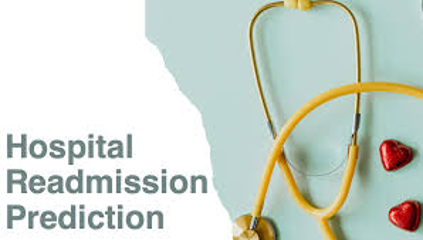

# Environment setup

In [ ]:
# Import the required libraries -
# numpy, pandas for data manipulation,
# matplotlib, seaborn for visualization,
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Remove the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Set the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# Set the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library for scaling
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import learning_curve

from sklearn.utils import resample
from scipy.stats import ttest_rel
from scipy.stats import chi2_contingency

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Load Data and perform Basic checks

In [ ]:
# Load the diabetes dataset from GitHub and treat '?' values
# as missing while preserving other default string values.

DiabData_df = pd.read_csv(
    "https://raw.githubusercontent.com/ajit-shenvi/WalshCollege-AIML-Capstone/capstone-data/data/diabetic_data.csv",
    header=0,
    sep=",",
    na_values=["?"],   # only treat '?' as missing
    keep_default_na=False
)

In [ ]:
# Create a copy of original data set as back-up
DiabData_backupcopy = DiabData_df.copy()

In [ ]:
# Use the shape function to get the number of rows and columns in the data set
DiabData_df.shape

(101766, 50)

In [ ]:
# Find the datatypes of various columns in this data set using the 'info()' function
DiabData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
# View the first 5 rows from the data set
DiabData_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# View the last 5 rows from the data set
DiabData_df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,None,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,None,None,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,13,3,3,0,0,0,530,530,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [ ]:
# Find missing values in data - by using the isnull() function and summing the count of null values
DiabData_df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
# Find duplicate values in data - by using the duplicated () function and sum the count of null values
DiabData_df.duplicated().sum()

np.int64(0)

In [ ]:
# Find the statistical summary of numerical data using the describe() function
DiabData_df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.00000,165201645.62298,102640295.98346,12522.00000,84961194.00000,152388987.00000,230270887.50000,443867222.00000
patient_nbr,101766.00000,54330400.69495,38696359.34653,135.00000,23413221.00000,45505143.00000,87545949.75000,189502619.00000
admission_type_id,101766.00000,2.02401,1.44540,1.00000,1.00000,1.00000,3.00000,8.00000
discharge_disposition_id,101766.00000,3.71564,5.28017,1.00000,1.00000,1.00000,4.00000,28.00000
admission_source_id,101766.00000,5.75444,4.06408,1.00000,1.00000,7.00000,7.00000,25.00000
time_in_hospital,101766.00000,4.39599,2.98511,1.00000,2.00000,4.00000,6.00000,14.00000
num_lab_procedures,101766.00000,43.09564,19.67436,1.00000,31.00000,44.00000,57.00000,132.00000
num_procedures,101766.00000,1.33973,1.70581,0.00000,0.00000,1.00000,2.00000,6.00000
num_medications,101766.00000,16.02184,8.12757,1.00000,10.00000,15.00000,20.00000,81.00000
number_outpatient,101766.00000,0.36936,1.26727,0.00000,0.00000,0.00000,0.00000,42.00000


# Pre-process data - Feature Exclusion

In [ ]:
# Replace '?' with NaN

DiabData_df = DiabData_df.replace('?', np.nan)

In [ ]:
# Drop columns not relevant - identifier variables, High missing values
# diagnosis codes and secondary medication variables
# -------------------------------
# Columns to DROP
# -------------------------------

# Identifier columns (not useful for modeling)
id_cols = [
    'encounter_id',
    'patient_nbr',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
]

# High-missing / low-value columns
high_missing_cols = [
    'weight',
    'payer_code',
    'medical_specialty'
]

# Diagnosis codes (complex, high cardinality)
diag_cols = [
    'diag_1',
    'diag_2',
    'diag_3'
]

# Medication columns (22 columns that are second level medication)
# Insulin and DibatesMed are the first level features retained
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

# Combine all columns to drop
cols_to_drop = id_cols + high_missing_cols + diag_cols + medication_cols

# Drop columns safely (ignore if any column not present)
DiabData_df = DiabData_df.drop(columns=cols_to_drop, errors='ignore')

# ------------------------------------------
# Columns to KEEP explicitly (sanity check)
# ------------------------------------------

print("Remaining columns:")
print(DiabData_df.columns.tolist())

print("\nShape after dropping columns:")
print(DiabData_df.shape)

Remaining columns:
['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'readmitted']

Shape after dropping columns:
(101766, 17)


# Exploratory Data Analysis

In [ ]:
# ==============================================================================
# Function to create a labeled bar plot for a categorical feature,
# displaying either counts or percentages above each bar.
#
# Input:
# - data: DataFrame containing the feature to visualize.
#
# - feature: Name of the categorical column to plot.
#
# - perc: Boolean indicating whether to display percentages instead of raw counts.
#     Default = False.
#
# - n: Number of top categories to display. Default = None (display all categories).
#
# Returns: None. Displays the labeled bar plot directly.
# ==============================================================================

def labeled_barplot(data, feature, perc=False, n=None):

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=10)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# ==============================================================================
# Function to create and display a stacked bar chart to compare
# the distribution of a target variable across categories
# of a predictor variable.
#
# Input:
# - data: DataFrame containing predictor and target variables.
#
# - predictor: Name of the independent categorical variable.
#
# - target: Name of the target variable.
#
# Returns: None.  Prints summary tables and displays the stacked bar plot.
# ==============================================================================

def stacked_barplot(data, predictor, target):

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

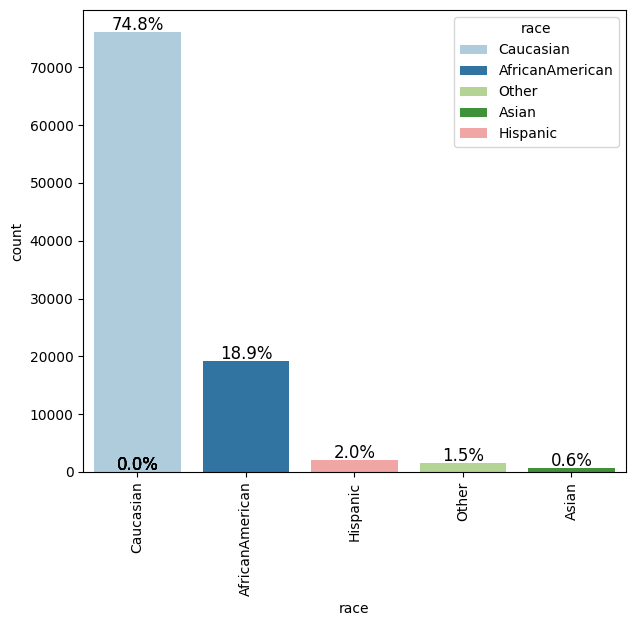

,count
race,
Caucasian,76099
AfricanAmerican,19210
Hispanic,2037
Other,1506
Asian,641


In [ ]:
# "Race" distribution
labeled_barplot(DiabData_df, "race", perc=True)
DiabData_df['race'].value_counts()

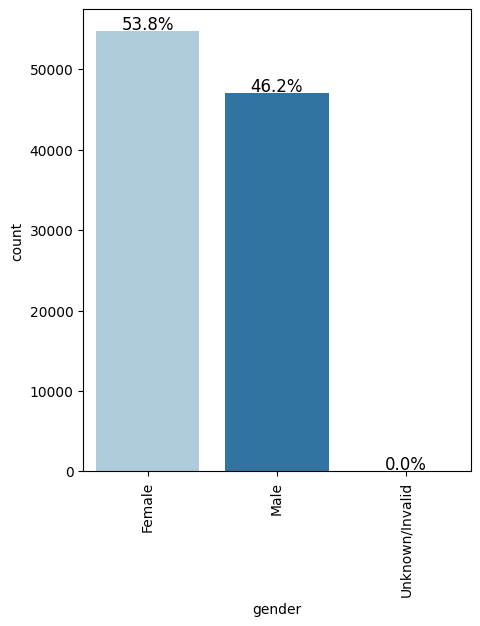

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [ ]:
# "Gender" distribution
labeled_barplot(DiabData_df, "gender", perc=True)
DiabData_df['gender'].value_counts()

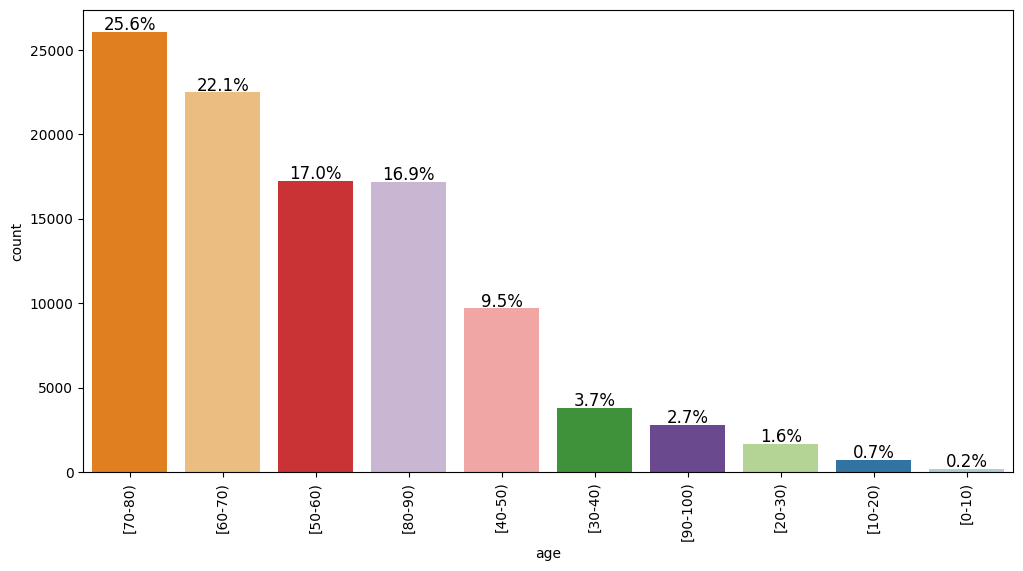

,count
age,
[70-80),26068
[60-70),22483
[50-60),17256
[80-90),17197
[40-50),9685
[30-40),3775
[90-100),2793
[20-30),1657
[10-20),691


In [ ]:
# "Age" distribution
labeled_barplot(DiabData_df, "age", perc=True)
DiabData_df['age'].value_counts()

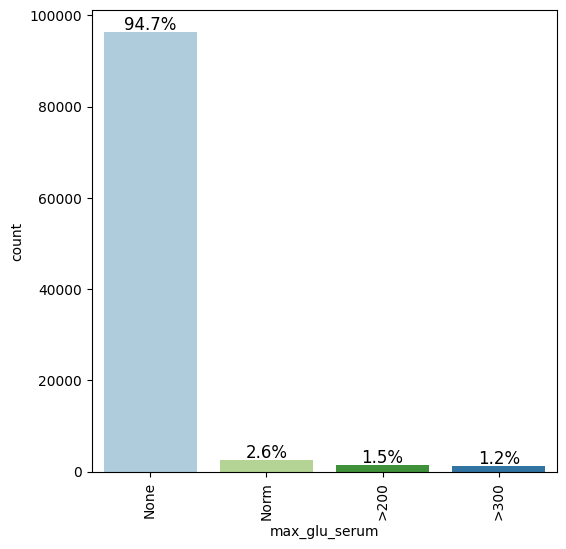

,count
max_glu_serum,
None,96420
Norm,2597
>200,1485
>300,1264


In [ ]:
# "Glucose serum test" distribution
labeled_barplot(DiabData_df, "max_glu_serum", perc=True)
DiabData_df['max_glu_serum'].value_counts()

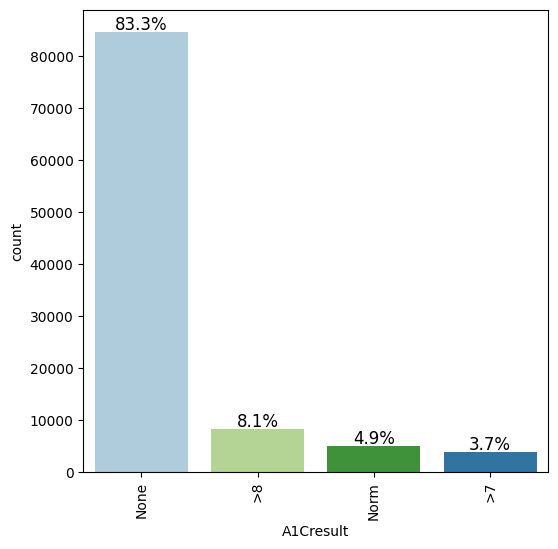

,count
A1Cresult,
None,84748
>8,8216
Norm,4990
>7,3812


In [ ]:
# "A1C result" distribution
labeled_barplot(DiabData_df, "A1Cresult", perc=True)
DiabData_df['A1Cresult'].value_counts()

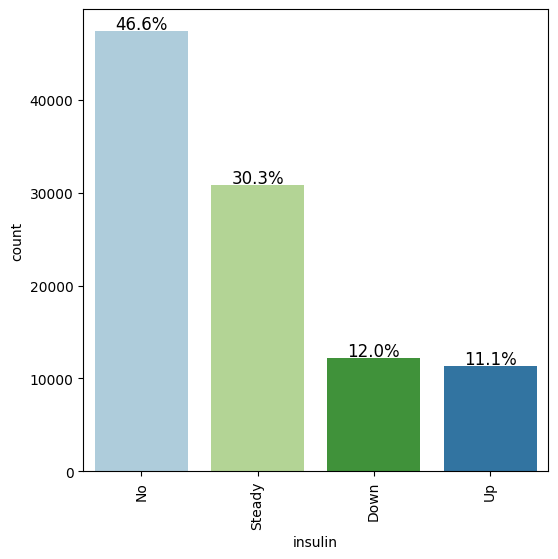

,count
insulin,
No,47383
Steady,30849
Down,12218
Up,11316


In [ ]:
# "Insulin" distribution
labeled_barplot(DiabData_df, "insulin", perc=True)
DiabData_df['insulin'].value_counts()

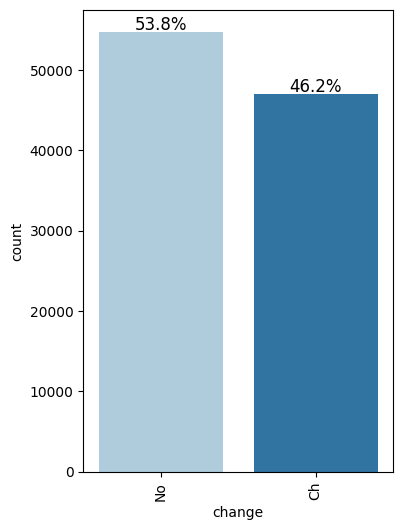

,count
change,
No,54755
Ch,47011


In [ ]:
# "Change of medication" distribution
labeled_barplot(DiabData_df, "change", perc=True)
DiabData_df['change'].value_counts()

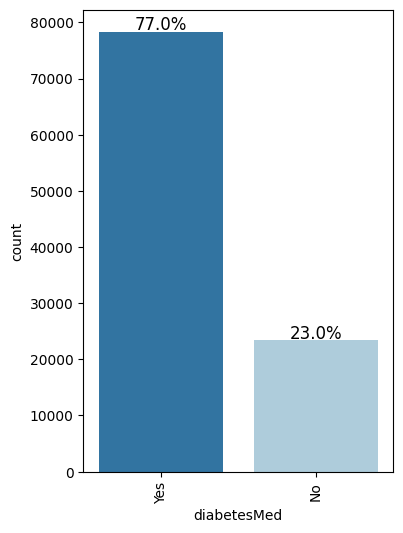

,count
diabetesMed,
Yes,78363
No,23403


In [ ]:
# "Diabetes medication" distribution
labeled_barplot(DiabData_df, "diabetesMed", perc=True)
DiabData_df['diabetesMed'].value_counts()

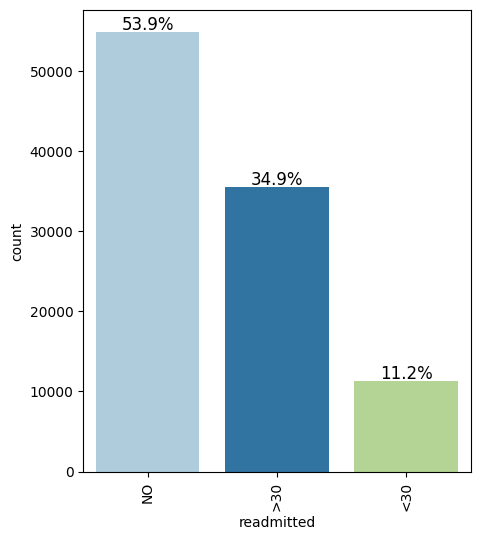

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
# "Readmitted" distribution
labeled_barplot(DiabData_df, "readmitted", perc=True)
DiabData_df['readmitted'].value_counts()

In [ ]:
# Using the shape function to get the number of rows and columns in the data set
DiabData_df.shape

(101766, 17)

In [ ]:
# Finding the datatypes of various columns in this data set using the 'info()' function
DiabData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   race                99493 non-null   object
 1   gender              101766 non-null  object
 2   age                 101766 non-null  object
 3   time_in_hospital    101766 non-null  int64 
 4   num_lab_procedures  101766 non-null  int64 
 5   num_procedures      101766 non-null  int64 
 6   num_medications     101766 non-null  int64 
 7   number_outpatient   101766 non-null  int64 
 8   number_emergency    101766 non-null  int64 
 9   number_inpatient    101766 non-null  int64 
 10  number_diagnoses    101766 non-null  int64 
 11  max_glu_serum       101766 non-null  object
 12  A1Cresult           101766 non-null  object
 13  insulin             101766 non-null  object
 14  change              101766 non-null  object
 15  diabetesMed         101766 non-null  object
 16  re

In [ ]:
# Find missing values in data - by using the isnull() function and summing the count of null values
DiabData_df.isnull().sum()

,0
race,2273
gender,0
age,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0
number_inpatient,0


In [ ]:
# Find the statistical summary of numerical data using the describe() function
DiabData_df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.00000,4.39599,2.98511,1.00000,2.00000,4.00000,6.00000,14.00000
num_lab_procedures,101766.00000,43.09564,19.67436,1.00000,31.00000,44.00000,57.00000,132.00000
num_procedures,101766.00000,1.33973,1.70581,0.00000,0.00000,1.00000,2.00000,6.00000
num_medications,101766.00000,16.02184,8.12757,1.00000,10.00000,15.00000,20.00000,81.00000
number_outpatient,101766.00000,0.36936,1.26727,0.00000,0.00000,0.00000,0.00000,42.00000
number_emergency,101766.00000,0.19784,0.93047,0.00000,0.00000,0.00000,0.00000,76.00000
number_inpatient,101766.00000,0.63557,1.26286,0.00000,0.00000,0.00000,1.00000,21.00000
number_diagnoses,101766.00000,7.42261,1.93360,1.00000,6.00000,8.00000,9.00000,16.00000


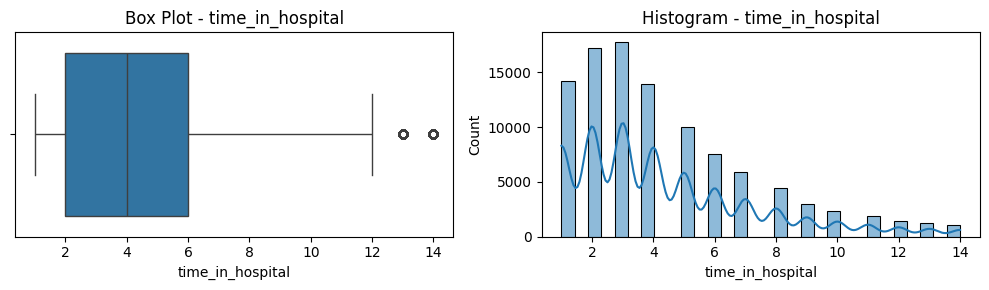

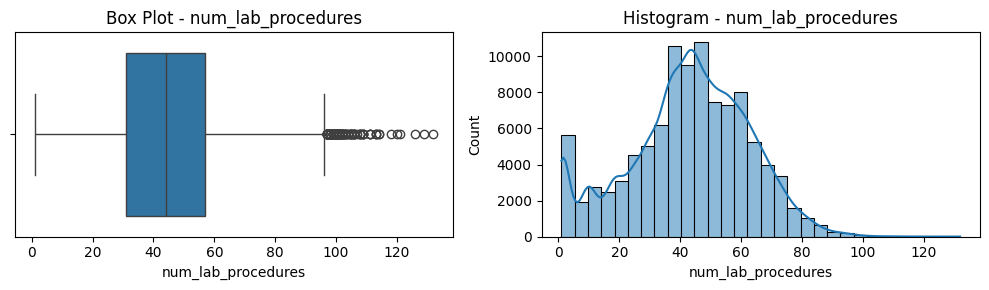

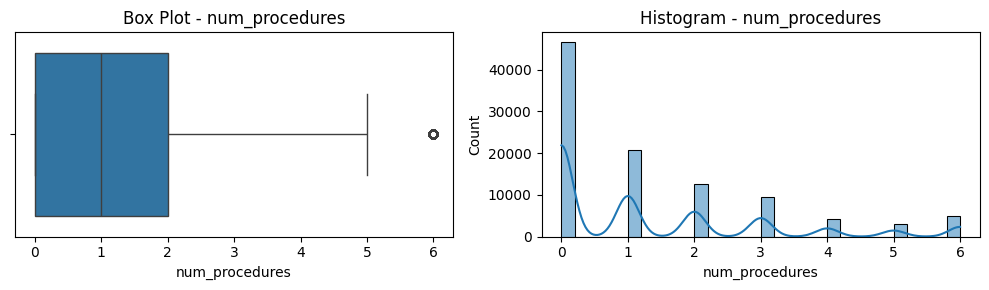

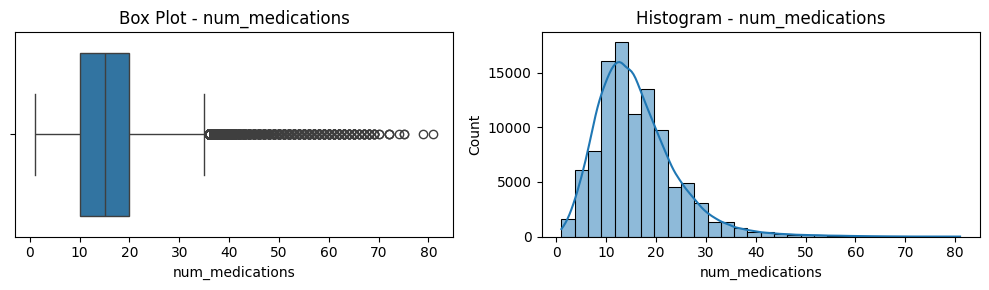

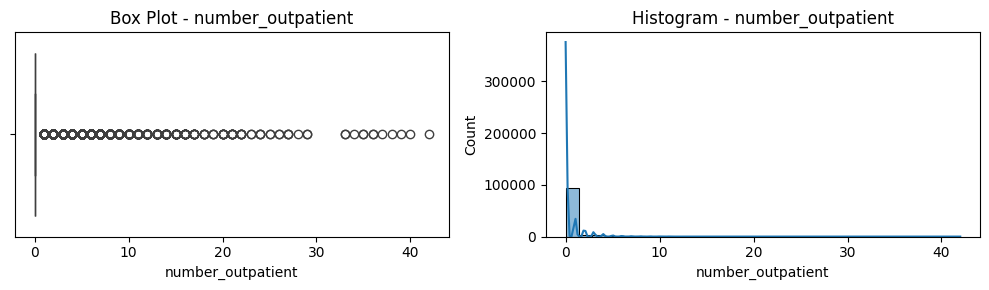

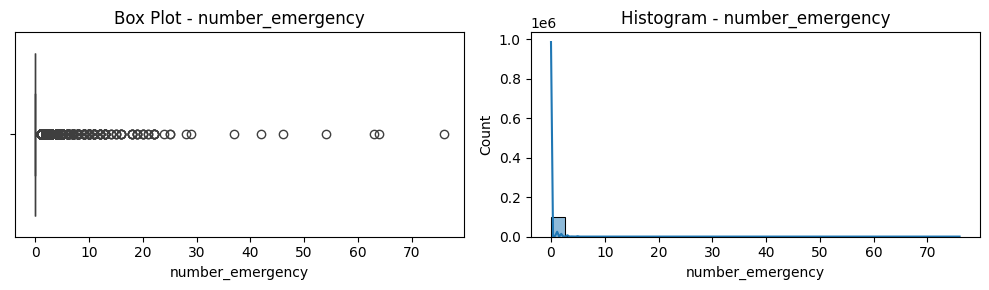

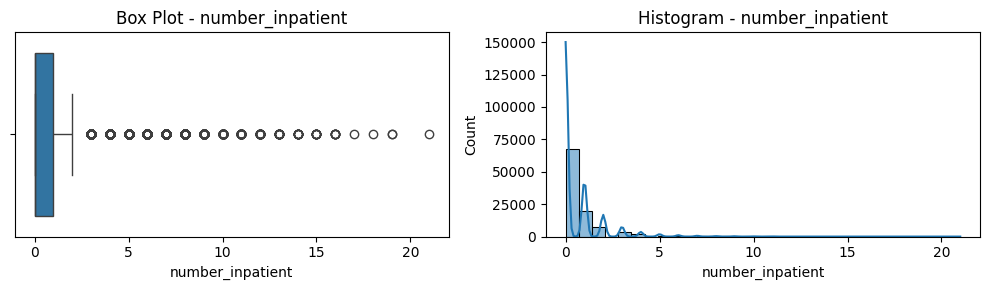

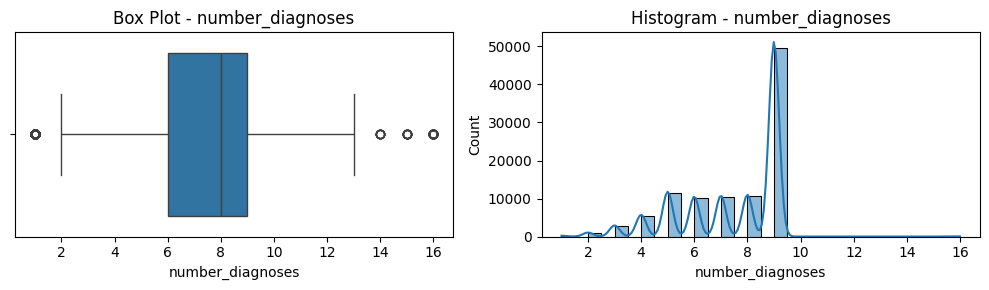

In [ ]:
# get the relevant numeric columns
numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Box plot
    sns.boxplot(x=DiabData_df[col], ax=axes[0])
    axes[0].set_title(f'Box Plot - {col}')

    # Histogram
    sns.histplot(DiabData_df[col], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram - {col}')

    plt.tight_layout()
    plt.show()

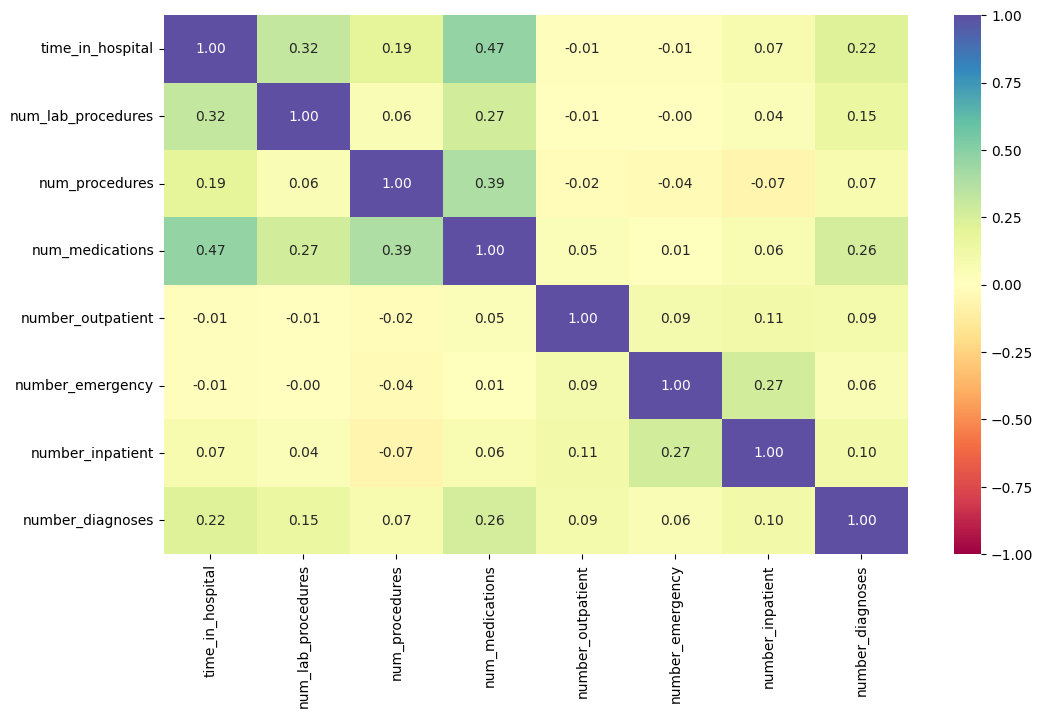

In [ ]:
# Generate a correlation heatmap for numeric features
# to visualize relationships between variables.
plt.figure(figsize=(12, 7))
sns.heatmap(DiabData_df[numeric_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

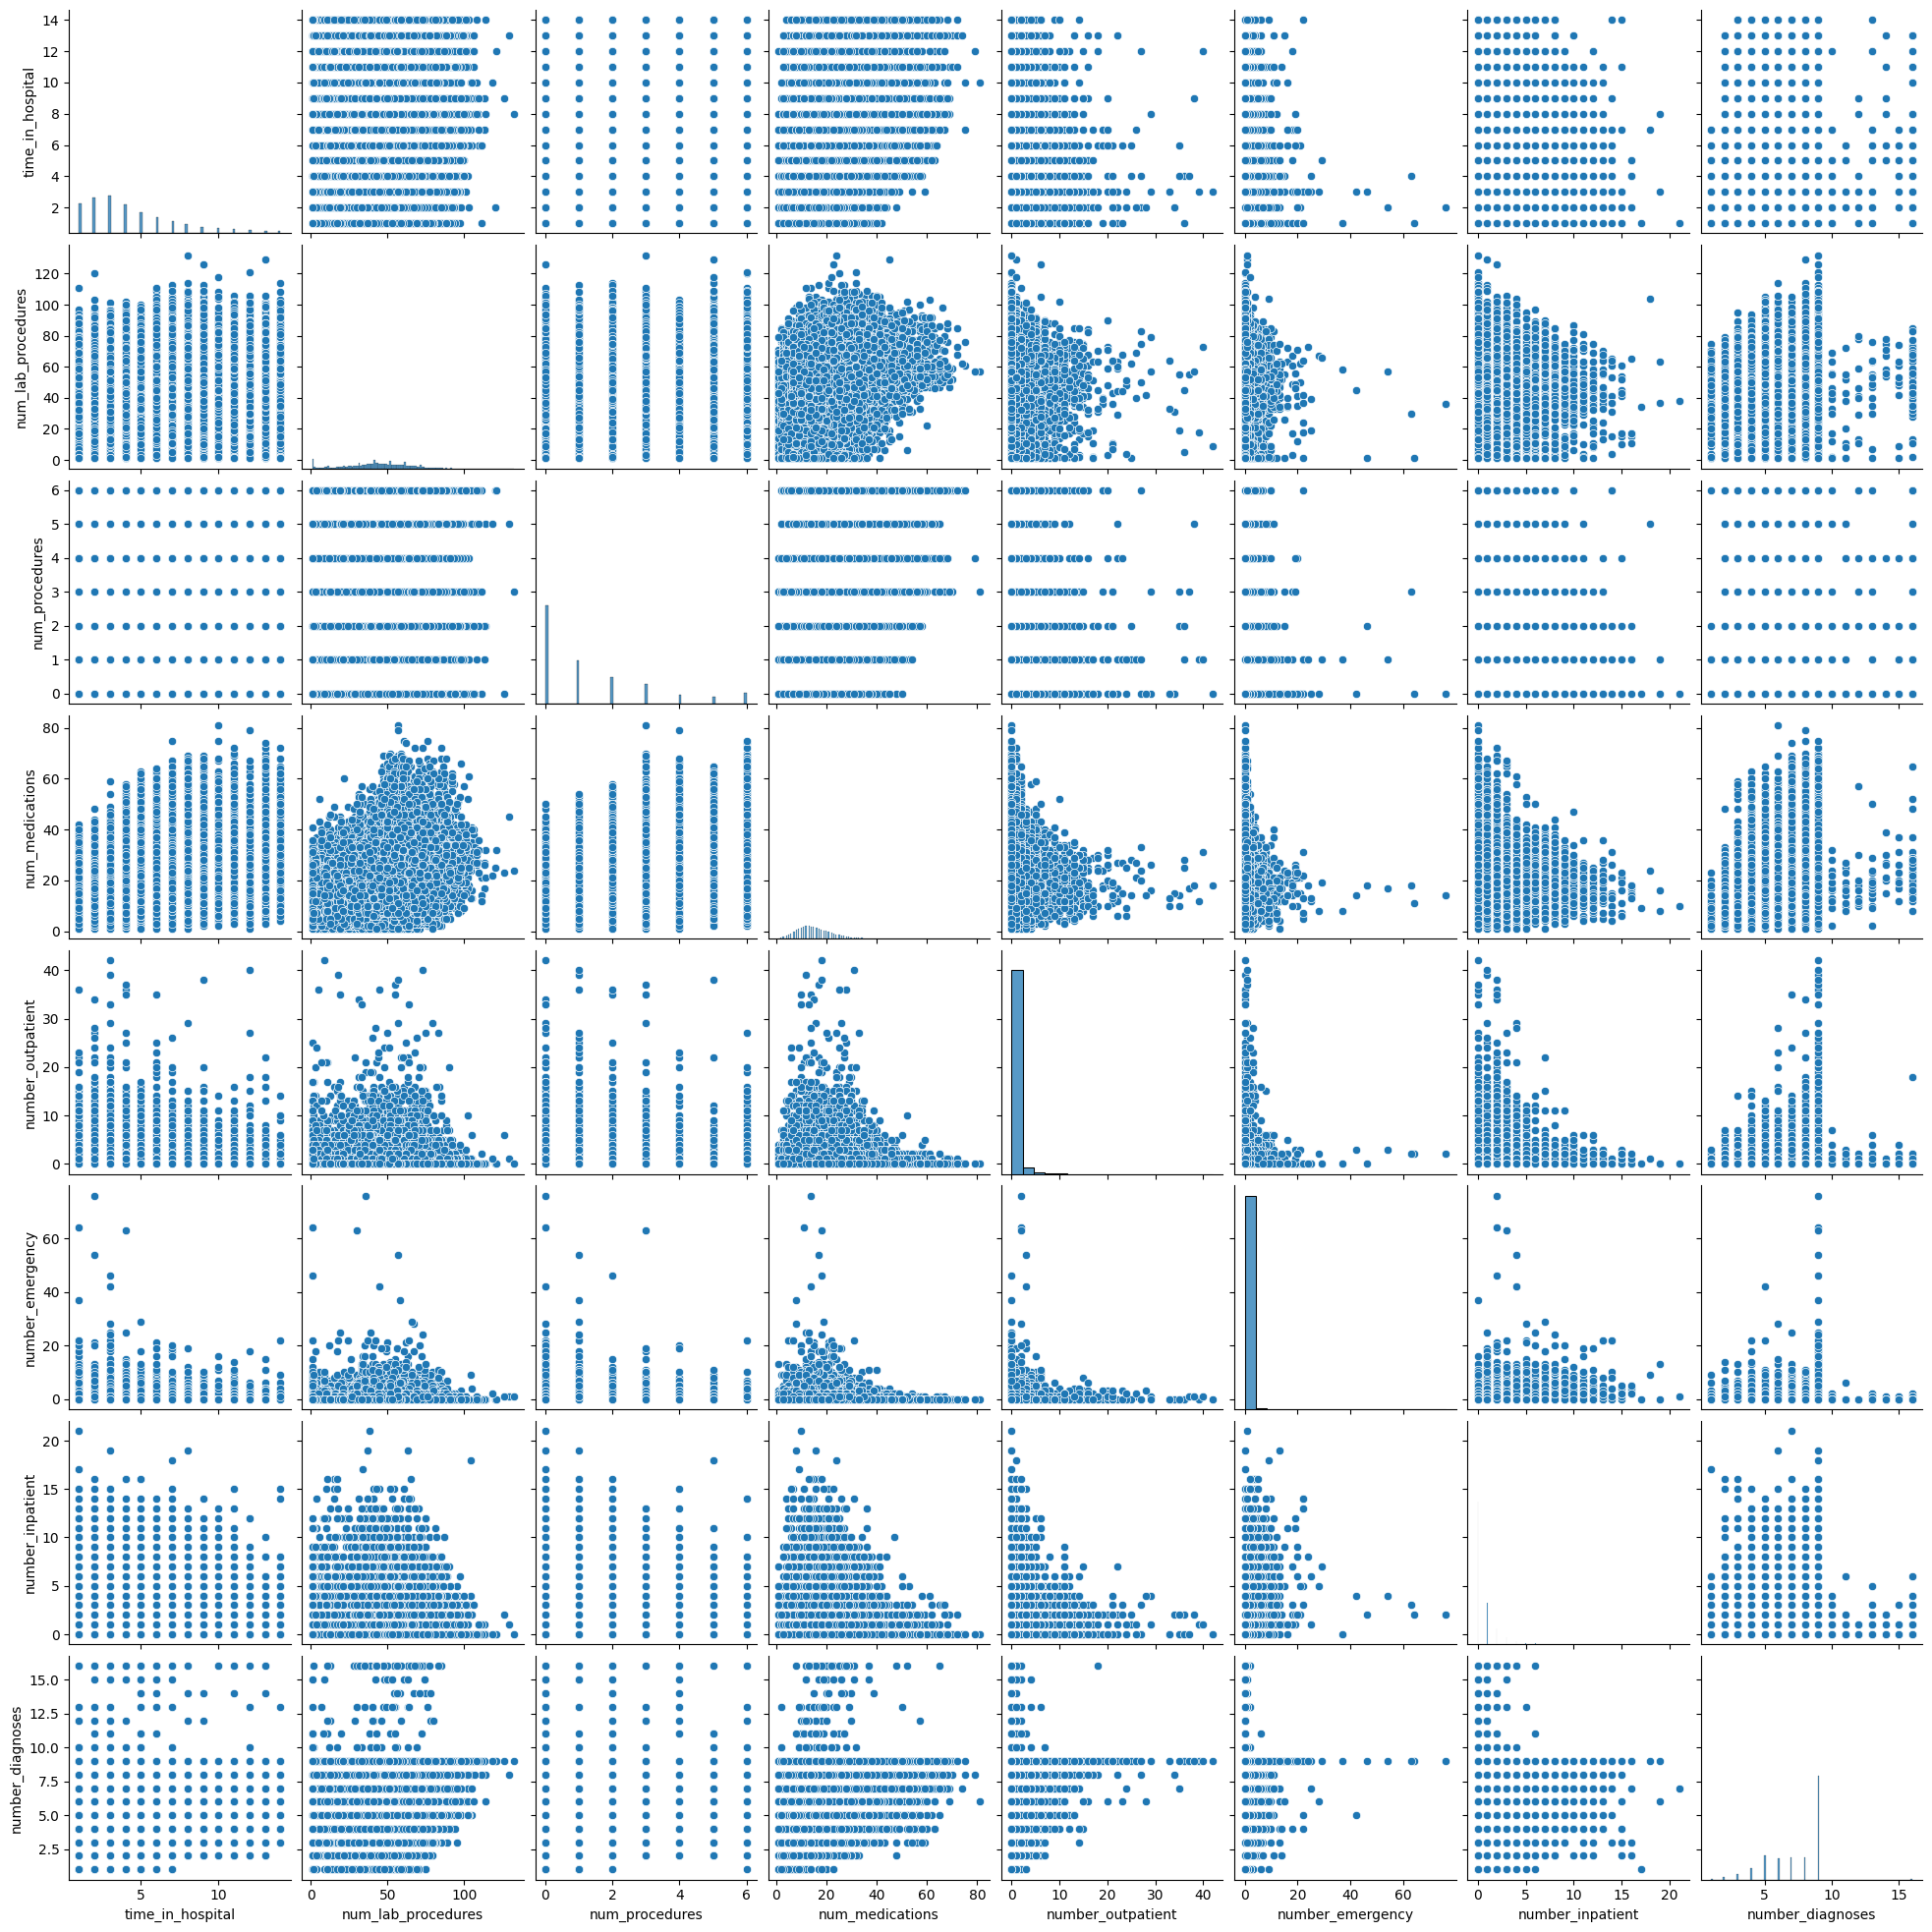

In [ ]:
# Generate pairwise scatter plots and distributions for key
# numeric features to explore relationships and data patterns.
sns.pairplot(data=DiabData_df, vars=[
      'time_in_hospital',
      'num_lab_procedures',
      'num_procedures',
      'num_medications',
      'number_outpatient',
      'number_emergency',
      'number_inpatient',
      'number_diagnoses',
      ]);

readmitted         <30    >30     NO     All
gender                                      
All              11357  35545  54864  101766
Female            6152  19518  29038   54708
Male              5205  16027  25823   47055
Unknown/Invalid      0      0      3       3
------------------------------------------------------------------------------------------------------------------------


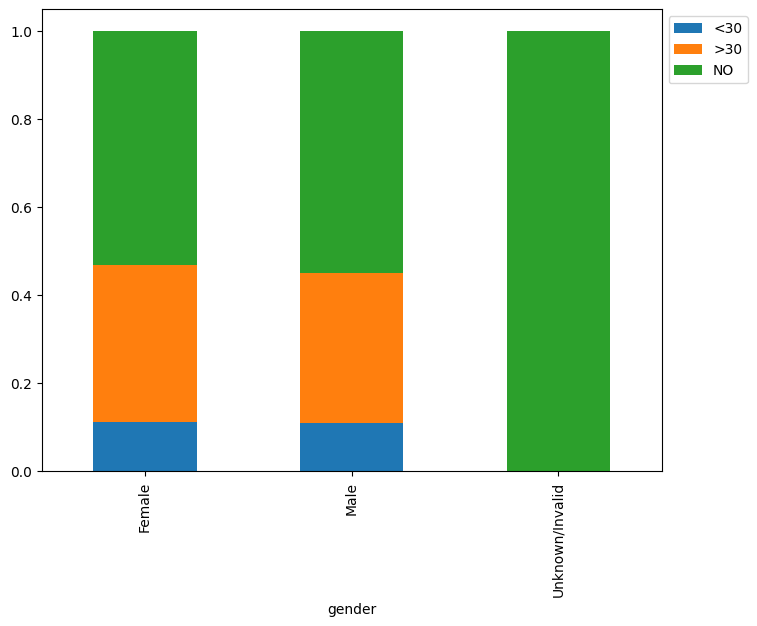

In [ ]:
# Check if Readmission is influenced by Gender
stacked_barplot(DiabData_df, "gender", "readmitted")

readmitted         <30    >30     NO    All
race                                       
All              11169  35007  53317  99493
Caucasian         8592  27124  40383  76099
AfricanAmerican   2155   6634  10421  19210
Hispanic           212    642   1183   2037
Other              145    446    915   1506
Asian               65    161    415    641
------------------------------------------------------------------------------------------------------------------------


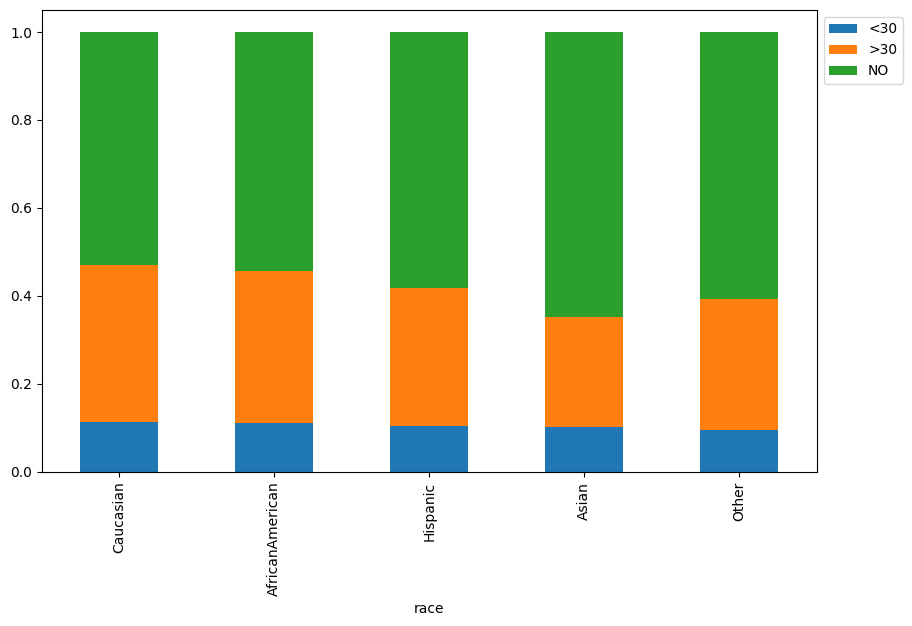

In [ ]:
# Check if Readmission is influenced by race
stacked_barplot(DiabData_df, "race", "readmitted")

readmitted    <30    >30     NO     All
age                                    
All         11357  35545  54864  101766
[70-80)      3069   9475  13524   26068
[60-70)      2502   7897  12084   22483
[80-90)      2078   6223   8896   17197
[50-60)      1668   5917   9671   17256
[40-50)      1027   3278   5380    9685
[30-40)       424   1187   2164    3775
[90-100)      310    808   1675    2793
[20-30)       236    510    911    1657
[10-20)        40    224    427     691
[0-10)          3     26    132     161
------------------------------------------------------------------------------------------------------------------------


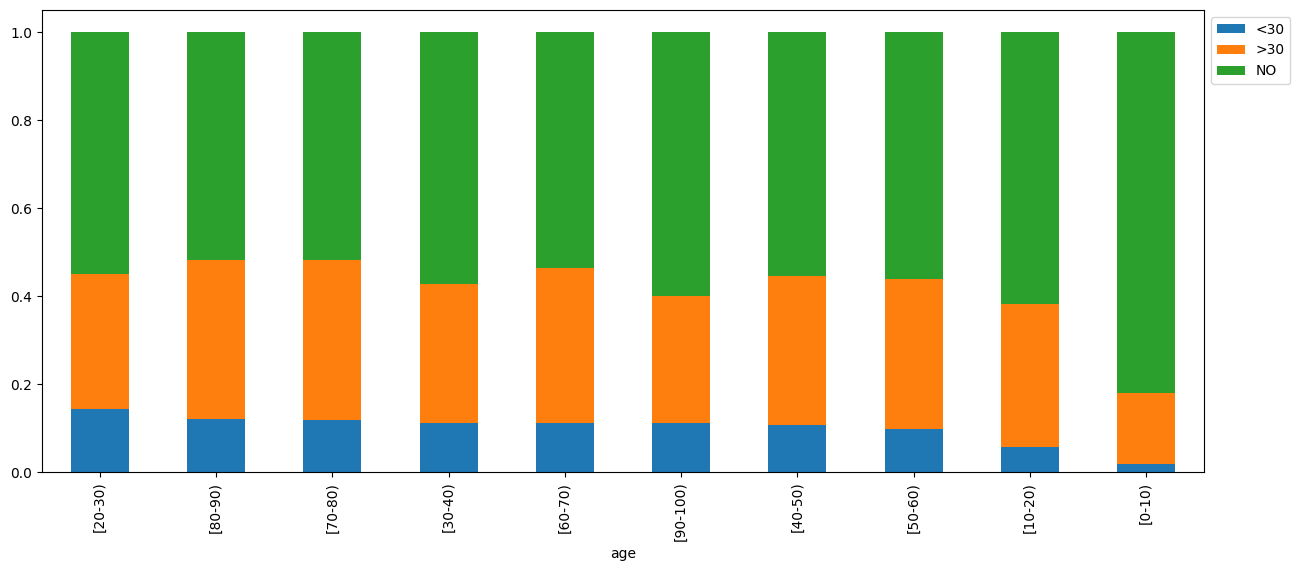

In [ ]:
# Check if Readmission is influenced by age
stacked_barplot(DiabData_df, "age", "readmitted")

# Process Data - Feature Engineering

In [ ]:
# Create age group mapping
def map_age_group(age):
    if age in ['[60-70)', '[70-80)']:
        return 'Senior'
    else:
        return 'Upto60'

DiabData_df['age_group'] = DiabData_df['age'].apply(map_age_group)

# Check distribution
print(DiabData_df['age_group'].value_counts())

age_group
Upto60    53215
Senior    48551
Name: count, dtype: int64


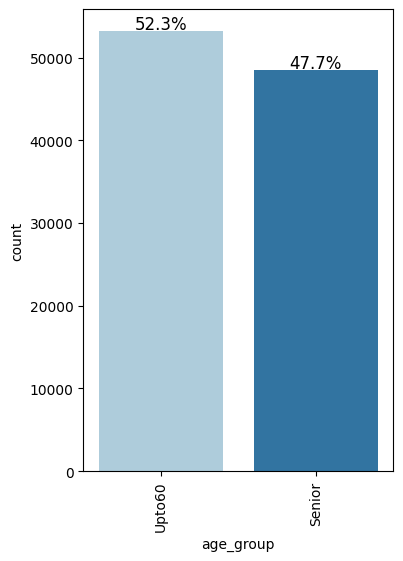

,count
age_group,
Upto60,53215
Senior,48551


In [ ]:
# "Age Group" distribution
labeled_barplot(DiabData_df, "age_group", perc=True)
DiabData_df['age_group'].value_counts()

In [ ]:
# Create race group mapping
def group_race(x):
    if x == 'Caucasian':
        return 'Caucasian'
    elif x == 'AfricanAmerican':
        return 'AfricanAmerican'
    else:
        return 'Other_Minority'

DiabData_df['race_group'] = DiabData_df['race'].apply(group_race)

print(DiabData_df['race_group'].value_counts())

race_group
Caucasian          76099
AfricanAmerican    19210
Other_Minority      6457
Name: count, dtype: int64


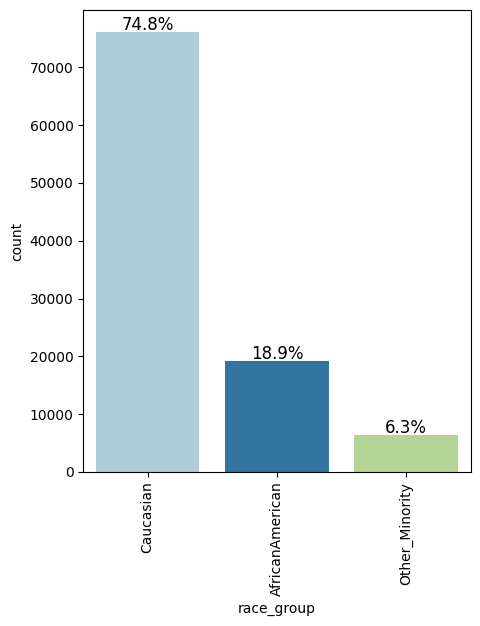

,count
race_group,
Caucasian,76099
AfricanAmerican,19210
Other_Minority,6457


In [ ]:
# "Race Group" distribution
labeled_barplot(DiabData_df, "race_group", perc=True)
DiabData_df['race_group'].value_counts()

In [ ]:
# encode Target variables

DiabData_df['readmitted_binary'] = DiabData_df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

# Check distribution
print(DiabData_df['readmitted_binary'].value_counts())

readmitted_binary
0    54864
1    46902
Name: count, dtype: int64


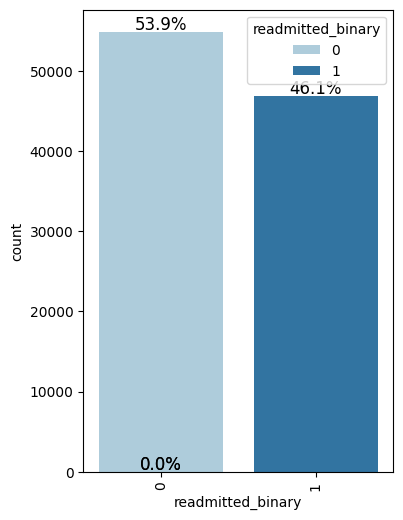

,count
readmitted_binary,
0,54864
1,46902


In [ ]:
# "Readmitted" distribution
labeled_barplot(DiabData_df, "readmitted_binary", perc=True)
DiabData_df['readmitted_binary'].value_counts()

In [ ]:
# drop original age column
DiabData_df = DiabData_df.drop(columns=['age'])
# Drop original race column
DiabData_df = DiabData_df.drop(columns=['race'])
# drop original target column
DiabData_df = DiabData_df.drop(columns=['readmitted'])

In [ ]:
# Create copies of demographic subgroup columns
# for race, age group, and gender analysis.
race_series = DiabData_df['race_group'].copy()
age_series = DiabData_df['age_group'].copy()
gender_series = DiabData_df['gender'].copy()

In [ ]:
DiabData_df

,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,age_group,race_group,readmitted_binary
0,Female,1,41,0,1,0,0,0,1,None,None,No,No,No,Upto60,Caucasian,0
1,Female,3,59,0,18,0,0,0,9,None,None,Up,Ch,Yes,Upto60,Caucasian,1
2,Female,2,11,5,13,2,0,1,6,None,None,No,No,Yes,Upto60,AfricanAmerican,0
3,Male,2,44,1,16,0,0,0,7,None,None,Up,Ch,Yes,Upto60,Caucasian,0
4,Male,1,51,0,8,0,0,0,5,None,None,Steady,Ch,Yes,Upto60,Caucasian,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,Male,3,51,0,16,0,0,0,9,None,>8,Down,Ch,Yes,Senior,AfricanAmerican,1
101762,Female,5,33,3,18,0,0,1,9,None,None,Steady,No,Yes,Upto60,AfricanAmerican,0
101763,Male,1,53,0,9,1,0,0,13,None,None,Down,Ch,Yes,Senior,Caucasian,0
101764,Female,10,45,2,21,0,0,1,9,None,None,Up,Ch,Yes,Upto60,Caucasian,0


readmitted_binary      0      1     All
gender                                 
All                54864  46902  101766
Female             29038  25670   54708
Male               25823  21232   47055
Unknown/Invalid        3      0       3
------------------------------------------------------------------------------------------------------------------------


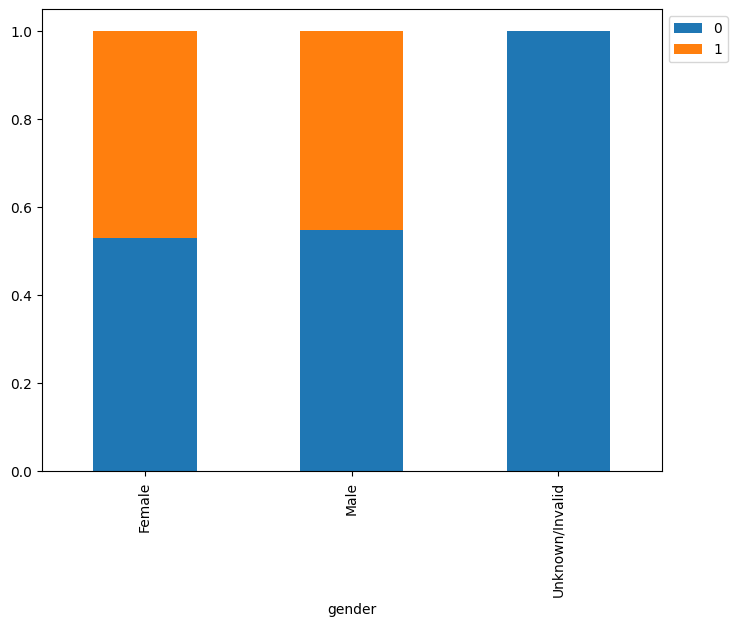

In [ ]:
# Check if Readmission is influenced by gender
stacked_barplot(DiabData_df, "gender", "readmitted_binary")

readmitted_binary      0      1     All
race_group                             
All                54864  46902  101766
Caucasian          40383  35716   76099
AfricanAmerican    10421   8789   19210
Other_Minority      4060   2397    6457
------------------------------------------------------------------------------------------------------------------------


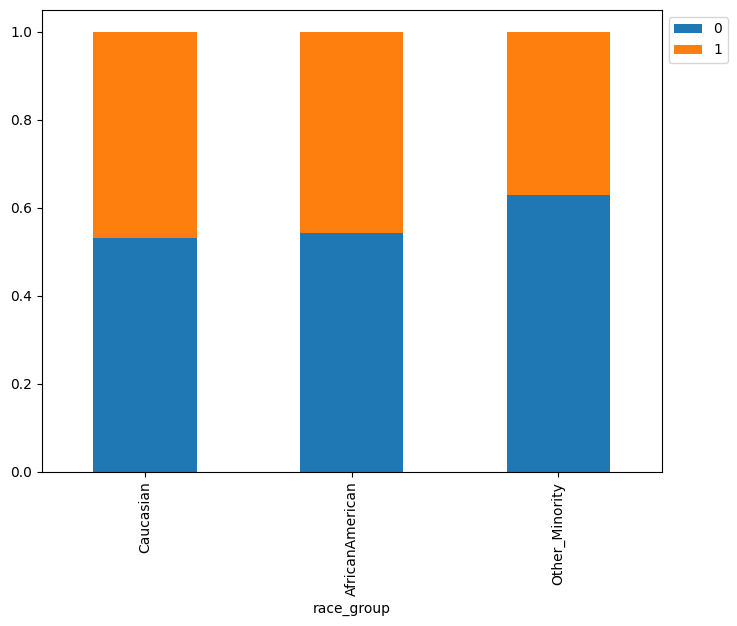

In [ ]:
# Check if Readmission is influenced by race group
stacked_barplot(DiabData_df, "race_group", "readmitted_binary")

readmitted_binary      0      1     All
age_group                              
All                54864  46902  101766
Upto60             29256  23959   53215
Senior             25608  22943   48551
------------------------------------------------------------------------------------------------------------------------


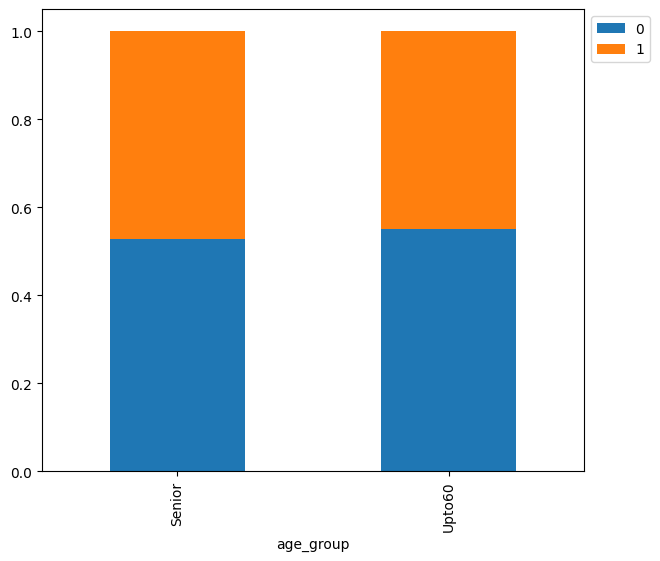

In [ ]:
# Check if Readmission is influenced by age group
stacked_barplot(DiabData_df, "age_group", "readmitted_binary")

# Outliers Treatment

In [ ]:
# Choose the highly skewed numeric variables
skewed_num_cols = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

In [ ]:
# Strategy-1 : Use Log Normal transformation to treat the outliers
DiabData_log = DiabData_df.copy()

for col in skewed_num_cols:
    DiabData_log[col] = np.log1p(DiabData_log[col])

print(DiabData_log[skewed_num_cols].describe())

       number_outpatient  number_emergency  number_inpatient
count       101766.00000      101766.00000      101766.00000
mean             0.17213           0.10191           0.32631
std              0.42935           0.31496           0.51110
min              0.00000           0.00000           0.00000
25%              0.00000           0.00000           0.00000
50%              0.00000           0.00000           0.00000
75%              0.00000           0.00000           0.69315
max              3.76120           4.34381           3.09104


In [ ]:
# Strategy-2 : Use 99% capping to treat the outliers
DiabData_cap = DiabData_df.copy()

cap_values = {}

for col in skewed_num_cols:
    cap_value = DiabData_cap[col].quantile(0.99)
    cap_values[col] = cap_value
    DiabData_cap[col] = DiabData_cap[col].clip(upper=cap_value)

print("99th percentile cap values:")
print(cap_values)

print(DiabData_cap[skewed_num_cols].describe())

99th percentile cap values:
{'number_outpatient': np.float64(5.0), 'number_emergency': np.float64(3.0), 'number_inpatient': np.float64(6.0)}
       number_outpatient  number_emergency  number_inpatient
count       101766.00000      101766.00000      101766.00000
mean             0.32960           0.16462           0.61571
std              0.90991           0.52513           1.13675
min              0.00000           0.00000           0.00000
25%              0.00000           0.00000           0.00000
50%              0.00000           0.00000           0.00000
75%              0.00000           0.00000           1.00000
max              5.00000           3.00000           6.00000


# Prepare X and y datasets for modelling

In [ ]:
# Defines the target variable and prepares feature datasets for modeling.
#
# Sets 'readmitted_binary' as the prediction target,
# Removes the target column from the feature datasets,
# Converts categorical variables into numerical format using one-hot encoding,
# Creates separate X feature matrices for:
#     • original dataset
#     • log-transformed dataset
#     • capped dataset


target_col = 'readmitted_binary'

# One hot encoding of categorical variables
X_original = pd.get_dummies(DiabData_df.drop(columns=[target_col]), drop_first=True)
X_log = pd.get_dummies(DiabData_log.drop(columns=[target_col]), drop_first=True)
X_cap = pd.get_dummies(DiabData_cap.drop(columns=[target_col]), drop_first=True)

y = DiabData_df[target_col].astype(int)

In [ ]:
# Store feature datasets and corresponding source dataframes
# for each preprocessing approach in a single dictionary.

datasets = {
    'Original': (X_original, DiabData_df),
    'Log Transform': (X_log, DiabData_log),
    '99% Capping': (X_cap, DiabData_cap),
}

In [ ]:
# Print shapes of all feature datasets (X) and target labels (y)

print("X_original shape:", X_original.shape)
print("X_log shape:", X_log.shape)
print("X_cap shape:", X_cap.shape)

print("y shape:", y.shape)

X_original shape: (101766, 24)
X_log shape: (101766, 24)
X_cap shape: (101766, 24)
y shape: (101766,)


In [ ]:
# Check the final list of features

X_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   time_in_hospital           101766 non-null  int64
 1   num_lab_procedures         101766 non-null  int64
 2   num_procedures             101766 non-null  int64
 3   num_medications            101766 non-null  int64
 4   number_outpatient          101766 non-null  int64
 5   number_emergency           101766 non-null  int64
 6   number_inpatient           101766 non-null  int64
 7   number_diagnoses           101766 non-null  int64
 8   gender_Male                101766 non-null  bool 
 9   gender_Unknown/Invalid     101766 non-null  bool 
 10  max_glu_serum_>300         101766 non-null  bool 
 11  max_glu_serum_None         101766 non-null  bool 
 12  max_glu_serum_Norm         101766 non-null  bool 
 13  A1Cresult_>8               101766 non-null  bool 
 14  A1Cr

In [ ]:
# Confirm the data by displaying forst few rows

X_original.head(8)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,gender_Male,gender_Unknown/Invalid,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,age_group_Upto60,race_group_Caucasian,race_group_Other_Minority
0,1,41,0,1,0,0,0,1,False,False,False,True,False,False,True,False,True,False,False,True,False,True,True,False
1,3,59,0,18,0,0,0,9,False,False,False,True,False,False,True,False,False,False,True,False,True,True,True,False
2,2,11,5,13,2,0,1,6,False,False,False,True,False,False,True,False,True,False,False,True,True,True,False,False
3,2,44,1,16,0,0,0,7,True,False,False,True,False,False,True,False,False,False,True,False,True,True,True,False
4,1,51,0,8,0,0,0,5,True,False,False,True,False,False,True,False,False,True,False,False,True,True,True,False
5,3,31,6,16,0,0,0,9,True,False,False,True,False,False,True,False,False,True,False,True,True,True,True,False
6,4,70,1,21,0,0,0,7,True,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False
7,5,73,0,12,0,0,0,8,True,False,False,True,False,False,True,False,True,False,False,True,True,False,True,False


In [ ]:
# This function splits the dataset into training and testing sets and applies
# feature scaling to numeric columns.
#
# Input:
# - X_data: Feature dataset.
# - y_data: Target labels.
#
# - source_df: Original dataframe associated with the dataset.
#
# - numeric_cols: List of numeric feature columns to standardize.
#
# - random_state: Seed value for reproducible train-test splitting.
#
# Returns:
# - X_train, X_test: Scaled training and testing feature datasets.
#
# - y_train, y_test: Training and testing target labels.

def prepare_train_test_datasets(X_data, y_data, source_df, numeric_cols, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.2,
        stratify=y_data,
        random_state=random_state
    )

    # Scale only the original numeric columns
    scale_cols = [c for c in numeric_cols if c in X_train.columns]

    scaler = StandardScaler()
    # Scale Train and Test columns separately to avoid leakage
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
    X_test[scale_cols] = scaler.transform(X_test[scale_cols])

    return X_train, X_test, y_train, y_test

In [ ]:
# Create the X dataset from original numeric columns (not treated outliers)

X_train, X_test, y_train, y_test = prepare_train_test_datasets(
        X_original,
        y,
        DiabData_df,
        numeric_cols,
        random_state=42
    )

# Common Functions across RQ1 and RQ2

In [ ]:
# ==============================================================================
# This is common function across RQ1 and RQ2
# It trains multiple machine learning models, generates predictions,
# and returns prediction results with demographic subgroup information.
#
# Input:
# - X_train, X_test: Training and testing feature datasets.
# - y_train, y_test: Training and testing target labels.
# - source_df: Original dataframe containing demographic subgroup columns
#     (gender, age_group, race_group).
#
# Returns:
# - results_by_model:
#     Dictionary where:
#     • key   = model name
#     • value = dataframe containing:
#         - demographic subgroup columns
#         - actual labels
#         - predicted labels
#         - correctness indicator ('correct')
# ==============================================================================

def train_and_predict_models(X_train, X_test, y_train, y_test, source_df):

    # Reattach subgroup columns from original dataframe
    demographics = pd.DataFrame({
        'gender': source_df.loc[X_test.index, 'gender'].values,
        'age_group': source_df.loc[X_test.index, 'age_group'].values,
        'race_group': source_df.loc[X_test.index, 'race_group'].values
    }, index=X_test.index)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }

    results_by_model = {}
    accuracy_summary = []

    for model_name, model in models.items():

        print(f"\n{'='*60}")
        print(f"Training model: {model_name}")
        print(f"{'='*60}")

        start_time = time.time()

        model.fit(X_train, y_train)

        end_time = time.time()

        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)

        print(f"Completed: {model_name}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Test Accuracy : {test_acc:.4f}")
        print(f"Execution Time: {end_time - start_time:.2f} sec")

        accuracy_summary.append({
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
        })

        y_pred = model.predict(X_test)

        results = demographics.copy()
        results['actual'] = y_test.values
        results['predicted'] = y_pred
        results['correct'] = (results['actual'] == results['predicted']).astype(int)

        results_by_model[model_name] = results

    return results_by_model, accuracy_summary

# Research question #1 : Accuracy across groups

In [ ]:
# ==============================================================================
# Function to run demography-wise accuracy comparison by:
# 1. Calculating accuracy statistics for each group,
# 2. Creating a contingency table of correct vs incorrect predictions,
# 3. Performing a Chi-square test to check if accuracy differences
#    across demographic groups are statistically significant.

# Input:
# - results_df: DataFrame containing model prediction results, including:
#     • demographic columns (e.g., gender, age_group, race_group)
#     • 'correct' column indicating correct/incorrect predictions
#
# - group_col: Name of the demographic column to analyze.
#
# Returns:
# - summary: DataFrame containing:
#     • total correct predictions
#     • total samples
#     • accuracy per demographic group
#
# - contingency: Contingency table of demographic groups vs correct/incorrect predictions.
#
# - p_value: P-value from the Chi-square test indicating whether
#     accuracy differences across groups are statistically significant.
# ==============================================================================

def run_rq1_test(results_df, group_col):

    # Accuracy summary
    summary = results_df.groupby(group_col)['correct'].agg(['sum', 'count'])
    summary['accuracy'] = summary['sum'] / summary['count']

    # Contingency table: group vs correct/incorrect
    contingency = pd.crosstab(results_df[group_col], results_df['correct'])

    # Chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency)

    return summary, contingency, p_value

In [ ]:
# ==============================================================================
# Function to exceute RQ1 demographic fairness analysis across all models by:
# 1. Running accuracy comparison tests for gender, age group, and race group,
# 2. Storing summary statistics, contingency tables, and Chi-square p-values,
# 3. Compiling the statistical results into a consolidated summary dataframe.

# Input:
# - results_by_model: Dictionary where:
#     key   = model name
#     value = dataframe containing prediction results and demographic columns

# Returns:
# - rq1_outputs:
#     Nested dictionary containing detailed results for each
#     model and demographic group.
#
# - summary_df:
#     DataFrame summarizing p-values for all models and
#     demographic groups.
# ==============================================================================

def run_rq1_all_models(results_by_model):

    demographic_groups = ['gender', 'age_group', 'race_group']
    rq1_outputs = {}
    summary_rows = []

    for model_name, results_df in results_by_model.items():
        rq1_outputs[model_name] = {}

        for group_col in demographic_groups:
            summary, contingency, p_value = run_rq1_test(results_df, group_col)

            rq1_outputs[model_name][group_col] = {
                'summary': summary,
                'contingency': contingency,
                'p_value': p_value
            }

            summary_rows.append({
                'Model': model_name,
                'Demographic Group': group_col,
                'p-value': p_value
            })

    summary_df = pd.DataFrame(summary_rows)

    return rq1_outputs, summary_df

In [ ]:
# Train all 3 models once and get predictions
results_by_model, accuracy_summary = train_and_predict_models(
    X_train, X_test, y_train, y_test, DiabData_df
)

# Run RQ1 across all models and demographic groups
rq1_outputs, rq1_pvalue_summary = run_rq1_all_models(results_by_model)

# View p-value summary
print(f"\n{'='*60}")
print(f"RQ1 Results Summary")
print(f"{'='*60}")
print(rq1_pvalue_summary)


Training model: Logistic Regression
Completed: Logistic Regression
Train Accuracy: 0.6168
Test Accuracy : 0.6205
Execution Time: 0.57 sec

Training model: Random Forest
Completed: Random Forest
Train Accuracy: 0.9991
Test Accuracy : 0.6040
Execution Time: 17.75 sec

Training model: Gradient Boosting
Completed: Gradient Boosting
Train Accuracy: 0.6276
Test Accuracy : 0.6241
Execution Time: 9.05 sec

RQ1 Results Summary
                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.21522
1  Logistic Regression         age_group  0.00000
2  Logistic Regression        race_group  0.03570
3        Random Forest            gender  0.15862
4        Random Forest         age_group  0.00000
5        Random Forest        race_group  0.00005
6    Gradient Boosting            gender  0.81544
7    Gradient Boosting         age_group  0.00000
8    Gradient Boosting        race_group  0.00123


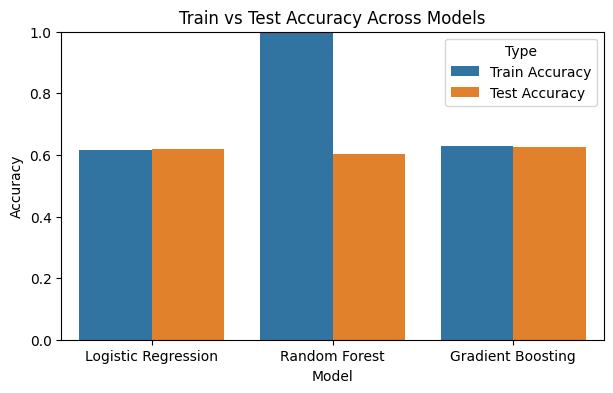

In [ ]:
# Create a comparison bar chart of train and test accuracy
# across models to evaluate model performance and generalization.

acc_df = pd.DataFrame(accuracy_summary)

# reshape the accuracy dataFrame from a wide format to a long format
acc_plot = acc_df.melt(
    id_vars='Model',
    value_vars=['Train Accuracy', 'Test Accuracy'],
    var_name='Type',
    value_name='Accuracy'
)

plt.figure(figsize=(7,4))

# Plot the bar chart
sns.barplot(
    data=acc_plot,
    x='Model',
    y='Accuracy',
    hue='Type'
)

plt.title('Train vs Test Accuracy Across Models')

plt.ylim(0,1)

plt.show()

In [ ]:
# ==============================================================================
# This function displays detailed RQ1 demographic fairness analysis results
# for a selected model and demographic group.
#
# Input:
# - rq1_outputs:
#     Nested dictionary containing RQ1 analysis outputs
#     for all models and demographic groups.
#
# - model_name:
#     Name of the model whose results should be displayed.
#
# - group_col:
#     Demographic group to analyze
#     (e.g., gender, age_group, race_group).
#
# Output:
# - Prints:
#     • Accuracy summary table
#     • Contingency table
#     • Chi-square p-value
#
# Returns: None
# ==============================================================================

def print_rq1_results(rq1_outputs, model_name, group_col):
    obj = rq1_outputs[model_name][group_col]

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Demographic Group: {group_col}")
    print("=" * 60)

    print("\nSummary (Accuracy Table):")
    print(obj['summary'].to_string())

    print("\nContingency Table (Correct vs Incorrect):")
    print(obj['contingency'].to_string())

    print(f"\nChi-square p-value: {obj['p_value']:.6f}")
    print("=" * 60)

In [ ]:
# Print the RQ1 results with Logistic Regression Model

print_rq1_results(rq1_outputs, 'Logistic Regression', 'gender')
print_rq1_results(rq1_outputs, 'Logistic Regression', 'race_group')
print_rq1_results(rq1_outputs, 'Logistic Regression', 'age_group')

Model: Logistic Regression
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6734  10922   0.61655
Male    5896   9432   0.62511

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4188  6734
Male     3536  5896

Chi-square p-value: 0.215219
Model: Logistic Regression
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2345   3791   0.61857
Caucasian        9427  15251   0.61812
Other_Minority    858   1312   0.65396

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1446  2345
Caucasian        5824  9427
Other_Minority    454   858

Chi-square p-value: 0.035705
Model: Logistic Regression
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior

In [ ]:
# Print the RQ1 results with Random Forest Model
print_rq1_results(rq1_outputs, 'Random Forest', 'gender')
print_rq1_results(rq1_outputs, 'Random Forest', 'race_group')
print_rq1_results(rq1_outputs, 'Random Forest', 'age_group')

Model: Random Forest
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6646  10922   0.60850
Male    5647   9432   0.59871

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4276  6646
Male     3785  5647

Chi-square p-value: 0.158619
Model: Random Forest
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2329   3791   0.61435
Caucasian        9103  15251   0.59688
Other_Minority    861   1312   0.65625

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1462  2329
Caucasian        6148  9103
Other_Minority    451   861

Chi-square p-value: 0.000048
Model: Random Forest
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior     5665   9743  

In [ ]:
# Print the RQ1 results with Gradient Boosting Model

print_rq1_results(rq1_outputs, 'Gradient Boosting', 'gender')
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'race_group')
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'age_group')

Model: Gradient Boosting
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6825  10922   0.62489
Male    5878   9432   0.62320

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4097  6825
Male     3554  5878

Chi-square p-value: 0.815440
Model: Gradient Boosting
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2403   3791   0.63387
Caucasian        9427  15251   0.61812
Other_Minority    873   1312   0.66540

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1388  2403
Caucasian        5824  9427
Other_Minority    439   873

Chi-square p-value: 0.001230
Model: Gradient Boosting
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior     5

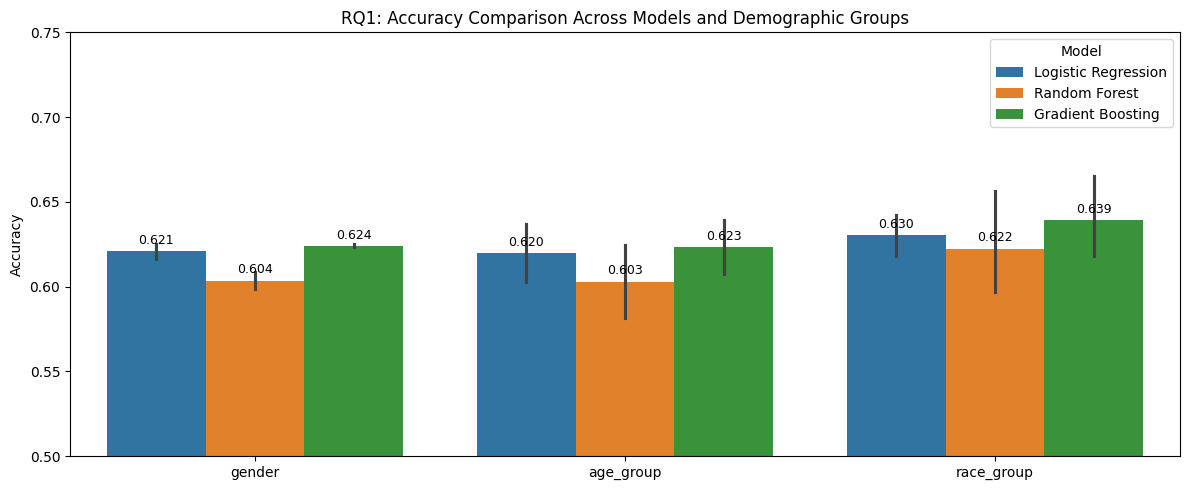

In [ ]:
# ==============================================================================
# Function to Build a consolidated accuracy summary table from RQ1 outputs
# and visualizes model performance across demographic groups
# using a comparative bar chart.
#
# The function extracts:
# - model names
# - demographic variables
# - subgroup categories
# - accuracy values
# - Chi-square p-values
#
# Returns:
# - DataFrame containing demographic-wise accuracy results
#   for all models.
# ==============================================================================

def build_rq1_accuracy_table(rq1_outputs):
    rows = []

    for model_name, group_dict in rq1_outputs.items():
        for group_col, obj in group_dict.items():
            summary = obj['summary'].reset_index()

            for _, row in summary.iterrows():
                rows.append({
                    'Model': model_name,
                    'Demographic Variable': group_col,
                    'Category': row[group_col],
                    'Accuracy': row['accuracy'],
                    'p-value': obj['p_value']
                })

    return pd.DataFrame(rows)

rq1_accuracy_df = build_rq1_accuracy_table(rq1_outputs)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=rq1_accuracy_df,
    x='Demographic Variable',
    y='Accuracy',
    hue='Model'
)
plt.title('RQ1: Accuracy Comparison Across Models and Demographic Groups')
plt.ylabel('Accuracy')
plt.xlabel('')
plt.ylim(0.5, 0.75)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

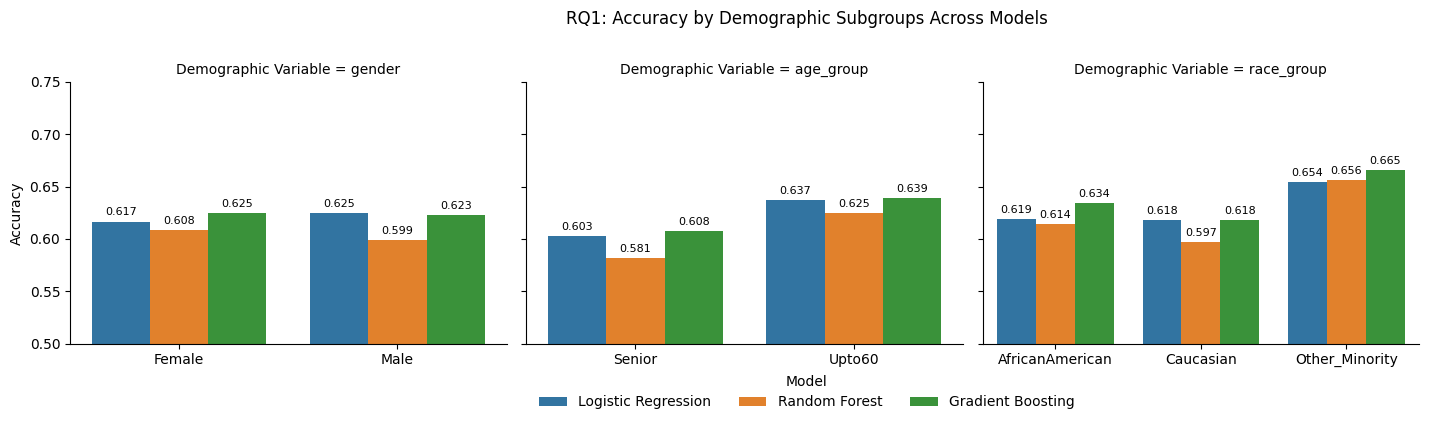

In [ ]:
# Create grouped bar charts to compare model accuracy across demographic
# subgroup categories, with separate panels for each demographic variable
# and labeled bars for easier interpretation.

g = sns.catplot(
    data=rq1_accuracy_df,
    x='Category',
    y='Accuracy',
    hue='Model',
    col='Demographic Variable',
    kind='bar',
    height=4,
    aspect=1.2,
    sharex=False
)

g.fig.subplots_adjust(top=0.80)
g.fig.suptitle('RQ1: Accuracy by Demographic Subgroups Across Models')

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

for ax in g.axes.flat:
    ax.set_ylim(0.5, 0.75)
    ax.set_xlabel('')
    ax.set_ylabel('Accuracy')

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=3,
            fontsize=8
        )

plt.show()

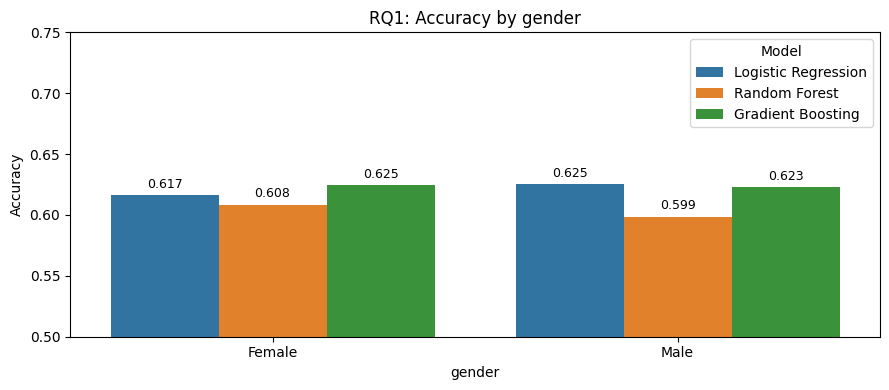

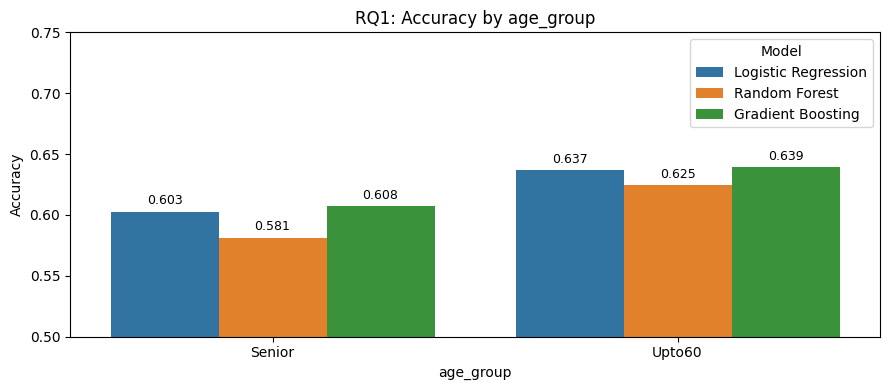

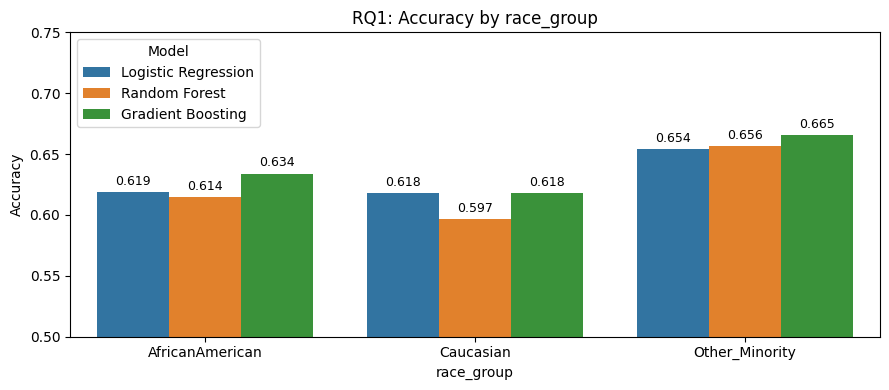

In [ ]:
# Generate separate bar charts to compare model accuracy
# across categories within each demographic variable
# (gender, age_group, and race_group).

for group_col in ['gender', 'age_group', 'race_group']:
    subset = rq1_accuracy_df[rq1_accuracy_df['Demographic Variable'] == group_col]

    plt.figure(figsize=(9, 4))

    ax = sns.barplot(
        data=subset,
        x='Category',
        y='Accuracy',
        hue='Model'
    )
    plt.title(f'RQ1: Accuracy by {group_col}')
    plt.ylabel('Accuracy')
    plt.xlabel(group_col)
    plt.ylim(0.5, 0.75)

    for container in ax.containers:
        ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=9
    )
    plt.tight_layout()
    plt.show()

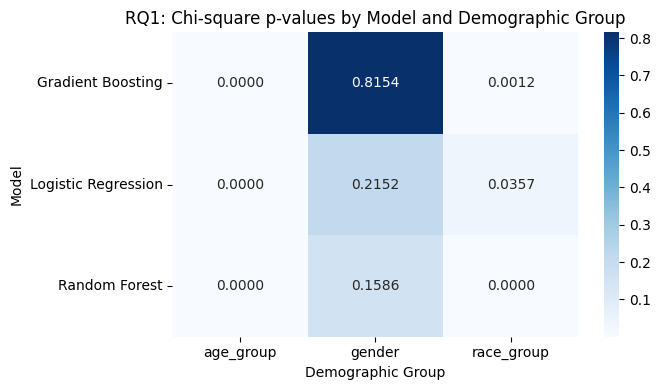

In [ ]:
# Create a heatmap visualization of Chi-square p-values
# to compare statistical significance of demographic
# performance differences across models and groups.

rq1_pivot = rq1_pvalue_summary.pivot(
    index='Model',
    columns='Demographic Group',
    values='p-value'
)

plt.figure(figsize=(7, 4))
sns.heatmap(
    rq1_pivot,
    annot=True,
    fmt=".4f",
    cmap="Blues"
)
plt.title('RQ1: Chi-square p-values by Model and Demographic Group')
plt.tight_layout()
plt.show()

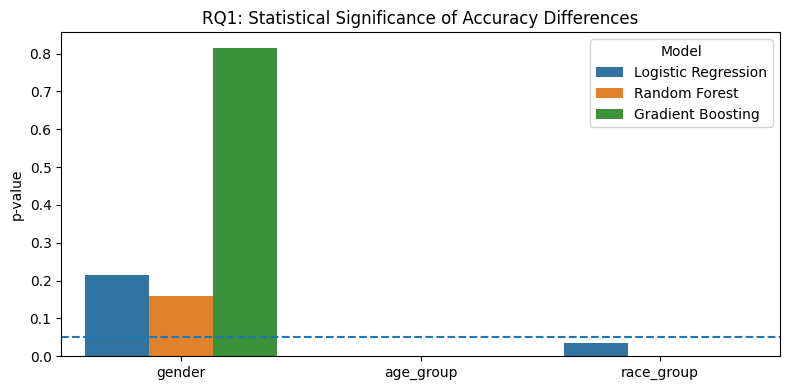

In [ ]:
# Identify statistically significant demographic differences
# and visualize model-wise Chi-square p-values against the
# significance threshold (p = 0.05).

rq1_sig = rq1_pvalue_summary.copy()
rq1_sig['Significant'] = rq1_sig['p-value'] < 0.05

plt.figure(figsize=(8, 4))
sns.barplot(
    data=rq1_sig,
    x='Demographic Group',
    y='p-value',
    hue='Model'
)
plt.axhline(0.05, linestyle='--')
plt.title('RQ1: Statistical Significance of Accuracy Differences')
plt.ylabel('p-value')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Tuning the Random Forest model to reduce overfitting**

In [ ]:
# Initialize a tuned Random Forest model with optimized
# hyperparameters for controlled model complexity
# and improved generalization performance.

RF_tuned_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Train the tuned Random Forest model, evaluate accuracy
# on both training and testing datasets, and print the
# performance results for comparison.

RF_tuned_model.fit(X_train, y_train)

RF_tuned_train_acc = RF_tuned_model.score(X_train, y_train)
RF_tuned_test_acc = RF_tuned_model.score(X_test, y_test)
print(f"Train Accuracy: {RF_tuned_train_acc:.4f}")
print(f"Test Accuracy : {RF_tuned_test_acc:.4f}")


Train Accuracy: 0.6411
Test Accuracy : 0.6245


**Robustness checks after treating outliers**

In [ ]:
# Execute the complete RQ1 evaluation pipeline for each preprocessing approach by:
# - preparing train-test datasets - original, outliers treated (Log Norm, 99% cap)
# - training all models,
# - generating predictions,
# - performing demographic fairness analysis,
# - and printing Chi-square p-value summaries.

datasets = {
    'Original': (X_original, DiabData_df),
    'Log Transform': (X_log, DiabData_log),
    '99% Capping': (X_cap, DiabData_cap),
}

for name, (X_data, source_df) in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    X_train, X_test, y_train, y_test = prepare_train_test_datasets(
        X_data,
        y,
        source_df,
        numeric_cols,
        random_state=42
    )

    results_by_model, accuracy_summary = train_and_predict_models(
        X_train,
        X_test,
        y_train,
        y_test,
        source_df
    )

    rq1_outputs, rq1_pvalues = run_rq1_all_models(results_by_model)

    print("\nRQ1 p-values:")
    print(rq1_pvalues)




Original

Training model: Logistic Regression
Completed: Logistic Regression
Train Accuracy: 0.6168
Test Accuracy : 0.6205
Execution Time: 1.02 sec

Training model: Random Forest
Completed: Random Forest
Train Accuracy: 0.9991
Test Accuracy : 0.6040
Execution Time: 19.10 sec

Training model: Gradient Boosting
Completed: Gradient Boosting
Train Accuracy: 0.6276
Test Accuracy : 0.6241
Execution Time: 9.09 sec

RQ1 p-values:
                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.21522
1  Logistic Regression         age_group  0.00000
2  Logistic Regression        race_group  0.03570
3        Random Forest            gender  0.15862
4        Random Forest         age_group  0.00000
5        Random Forest        race_group  0.00005
6    Gradient Boosting            gender  0.81544
7    Gradient Boosting         age_group  0.00000
8    Gradient Boosting        race_group  0.00123

Log Transform

Training model: Logistic Regression
Completed: Logistic R

# Research question #2 : False Negative Rate Disparities

In [ ]:
# ==============================================================================
# Function to perform RQ2 fairness analysis by comparing False Negative Rates (FNR)
# across demographic groups using a Chi-square test.
#
# Input:
# - results_df: DataFrame containing:
#     • actual labels
#     • predicted labels
#     • demographic subgroup columns
#
# - group_col: Name of the demographic column to analyze
#     (e.g., gender, age_group, race_group).
#
# Processing:
# - Filters only actual positive cases,
# - Computes False Negative (FN) and True Positive (TP) counts,
# - Calculates FNR for each demographic group,
# - Builds a contingency table of FN vs TP outcomes,
# - Performs a Chi-square test to evaluate statistical significance.
#
# Returns:
# - summary:DataFrame containing FN counts, total positives,
#     and FNR values for each demographic group.
#
# - contingency: Contingency table of False Negatives vs True Positives
#     across demographic groups.
#
# - p_value: Chi-square test p-value indicating whether FNR
#     differences across groups are statistically significant.
# ==============================================================================

def run_rq2_test(results_df, group_col):

    # Keep only actual positives
    pos_df = results_df[results_df['actual'] == 1].copy()

    # Define FN and TP indicators
    pos_df['FN'] = (pos_df['predicted'] == 0).astype(int)
    pos_df['TP'] = (pos_df['predicted'] == 1).astype(int)

    # Summary table
    summary = pos_df.groupby(group_col)['FN'].agg(['sum', 'count'])
    summary['FNR'] = summary['sum'] / summary['count']

    # Contingency table: group vs predicted class among actual positives
    contingency = pd.crosstab(pos_df[group_col], pos_df['predicted'])

    # Ensure both columns exist for clean interpretation
    contingency = contingency.reindex(columns=[0, 1], fill_value=0)
    contingency.columns = ['False_Negative', 'True_Positive']

    # Chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency)

    return summary, contingency, p_value

In [ ]:
# ==============================================================================
# This function executes RQ2 fairness analysis across all models and demographic groups.
#
# Input: results_by_model - Dictionary where:
#     • key   = model name
#     • value = dataframe containing prediction results and
#                demographic subgroup columns
#
# Processing:
# - Runs False Negative Rate (FNR) comparison for: gender, age_group, race_group
# - Computes: FNR summary statistics, contingency tables, Chi-square test p-values
#
# Returns:
# - rq2_outputs: Nested dictionary containing detailed RQ2 analysis
#     results for each model and demographic group.
#
# - summary_df: DataFrame summarizing Chi-square p-values for all
#     models and demographic groups.
# ==============================================================================

def run_rq2_all_models(results_by_model):

    demographic_groups = ['gender', 'age_group', 'race_group']
    rq2_outputs = {}
    summary_rows = []

    for model_name, results_df in results_by_model.items():
        rq2_outputs[model_name] = {}

        for group_col in demographic_groups:
            summary, contingency, p_value = run_rq2_test(results_df, group_col)

            rq2_outputs[model_name][group_col] = {
                'summary': summary,
                'contingency': contingency,
                'p_value': p_value
            }

            summary_rows.append({
                'Model': model_name,
                'Demographic Group': group_col,
                'p-value': p_value
            })

    summary_df = pd.DataFrame(summary_rows)

    return rq2_outputs, summary_df

In [ ]:
# Train all 3 models once and get predictions
results_by_model, accuracy_summary = train_and_predict_models(
    X_train, X_test, y_train, y_test, DiabData_df
)

# Run RQ2 across all models and demographic groups
rq2_outputs, rq2_pvalue_summary = run_rq2_all_models(results_by_model)

# View p-value summary
print(f"\n{'='*60}")
print(f"RQ2 Results Summary")
print(f"{'='*60}")
print(rq2_pvalue_summary)


Training model: Logistic Regression
Completed: Logistic Regression
Train Accuracy: 0.6176
Test Accuracy : 0.6222
Execution Time: 0.37 sec

Training model: Random Forest
Completed: Random Forest
Train Accuracy: 0.9990
Test Accuracy : 0.6018
Execution Time: 18.36 sec

Training model: Gradient Boosting
Completed: Gradient Boosting
Train Accuracy: 0.6273
Test Accuracy : 0.6254
Execution Time: 8.85 sec

RQ2 Results Summary
                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.00000
1  Logistic Regression         age_group  0.00256
2  Logistic Regression        race_group  0.00000
3        Random Forest            gender  0.00001
4        Random Forest         age_group  0.31268
5        Random Forest        race_group  0.00000
6    Gradient Boosting            gender  0.00000
7    Gradient Boosting         age_group  0.46290
8    Gradient Boosting        race_group  0.00000


In [ ]:
# ==============================================================================
# This function display detailed RQ2 fairness analysis results for a
# selected model and demographic group.
#
# Input:
# - rq2_outputs: Nested dictionary containing RQ2 analysis outputs
#     for all models and demographic groups.
#
# - model_name: Name of the model whose results should be displayed.
#
# - group_col: Demographic group to analyze (gender, age_group, race_group).
#
# Output: Prints:
#     • False Negative Rate (FNR) summary table
#     • Contingency table of False Negatives vs True Positives
#     • Chi-square test p-value
#
# Returns: None
# ==============================================================================

def print_rq2_results(rq2_outputs, model_name, group_col):
    obj = rq2_outputs[model_name][group_col]

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Demographic Group: {group_col}")
    print("=" * 60)

    print("\nSummary (False Negative Rate Table):")
    print(obj['summary'].to_string())

    print("\nContingency Table (False Negatives vs True Positives):")
    print(obj['contingency'].to_string())

    print(f"\nChi-square p-value: {obj['p_value']:.6f}")
    print("=" * 60)

In [ ]:
# Print the RQ2 results with Logistic Regression Model

print_rq2_results(rq2_outputs, 'Logistic Regression', 'gender')
print_rq2_results(rq2_outputs, 'Logistic Regression', 'age_group')
print_rq2_results(rq2_outputs, 'Logistic Regression', 'race_group')

Model: Logistic Regression
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2957   5219 0.56658
Male    2575   4162 0.61869

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2957           2262
Male              2575           1587

Chi-square p-value: 0.000000
Model: Logistic Regression
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2645   4608 0.57400
Upto60     2887   4773 0.60486

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2645           1963
Upto60               2887           1886

Chi-square p-value: 0.002556
Model: Logistic Regression
Demographic Group: race_group

Summary (False Negative Rate Tabl

In [ ]:
# Print the RQ2 results with Random Forest Model

print_rq2_results(rq2_outputs, 'Random Forest', 'gender')
print_rq2_results(rq2_outputs, 'Random Forest', 'age_group')
print_rq2_results(rq2_outputs, 'Random Forest', 'race_group')

Model: Random Forest
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2425   5219 0.46465
Male    2131   4162 0.51201

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2425           2794
Male              2131           2031

Chi-square p-value: 0.000006
Model: Random Forest
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2213   4608 0.48025
Upto60     2343   4773 0.49089

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2213           2395
Upto60               2343           2430

Chi-square p-value: 0.312680
Model: Random Forest
Demographic Group: race_group

Summary (False Negative Rate Table):
              

In [ ]:
# Print the RQ2 results with Gradient Boosting Model

print_rq2_results(rq2_outputs, 'Gradient Boosting', 'gender')
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'age_group')
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'race_group')


Model: Gradient Boosting
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2655   5219 0.50872
Male    2321   4162 0.55766

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2655           2564
Male              2321           1841

Chi-square p-value: 0.000003
Model: Gradient Boosting
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2426   4608 0.52648
Upto60     2550   4773 0.53426

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2426           2182
Upto60               2550           2223

Chi-square p-value: 0.462901
Model: Gradient Boosting
Demographic Group: race_group

Summary (False Negative Rate Table):
  

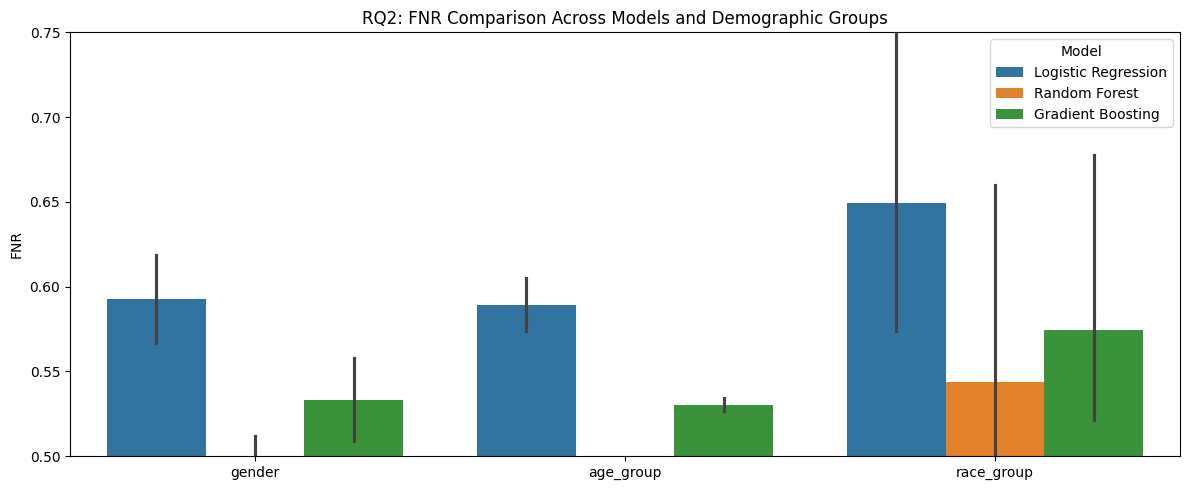

In [ ]:
# ==============================================================================
# This function builds a consolidated FNR summary table from RQ2 outputs
# and visualizes model performance across demographic groups
# using a comparative bar chart.
#
# The function extracts:
# - model names
# - demographic variables
# - subgroup categories
# - FNR values
# - Chi-square p-values
#
# Returns:
# - DataFrame containing demographic-wise FNR results
#   for all models.
# ==============================================================================

def build_rq2_fnr_table(rq2_outputs):
    rows = []

    for model_name, group_dict in rq2_outputs.items():
        for group_col, obj in group_dict.items():
            summary = obj['summary'].reset_index()

            for _, row in summary.iterrows():
                rows.append({
                    'Model': model_name,
                    'Demographic Variable': group_col,
                    'Category': row[group_col],
                    'FNR': row['FNR'],
                    'p-value': obj['p_value']
                })

    return pd.DataFrame(rows)

rq2_fnr_df = build_rq2_fnr_table(rq2_outputs)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=rq2_fnr_df,
    x='Demographic Variable',
    y='FNR',
    hue='Model'
)
plt.title('RQ2: FNR Comparison Across Models and Demographic Groups')
plt.ylabel('FNR')
plt.xlabel('')
plt.ylim(0.5, 0.75)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

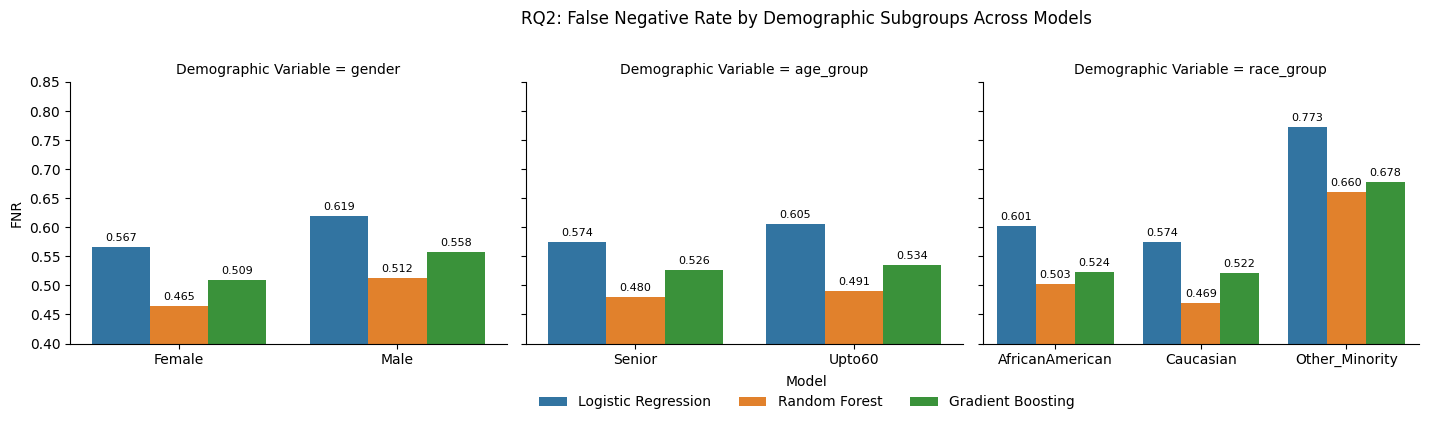

In [ ]:
# Create grouped bar charts to compare model accuracy across demographic
# subgroup categories, with separate panels for each demographic variable
# and labeled bars for easier interpretation.

g = sns.catplot(
    data=rq2_fnr_df,
    x='Category',
    y='FNR',
    hue='Model',
    col='Demographic Variable',
    kind='bar',
    height=4,
    aspect=1.2,
    sharex=False
)

g.fig.subplots_adjust(top=0.80)

g.fig.suptitle(
    'RQ2: False Negative Rate by Demographic Subgroups Across Models'
)

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

for ax in g.axes.flat:

    ax.set_ylim(0.4, 0.85)

    ax.set_xlabel('')
    ax.set_ylabel('FNR')

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=3,
            fontsize=8
        )

plt.show()

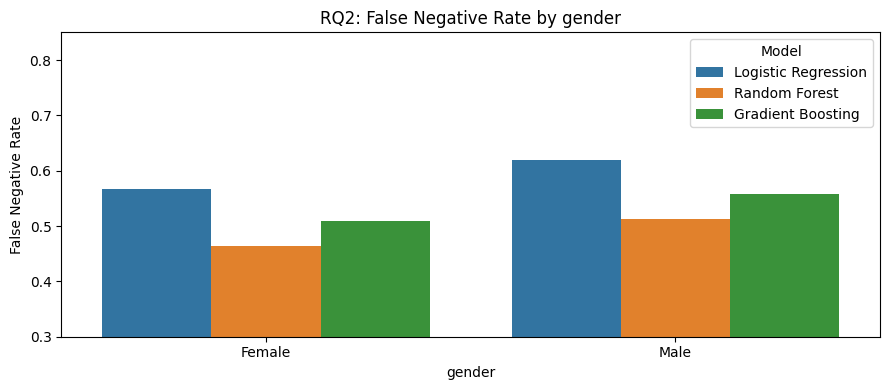

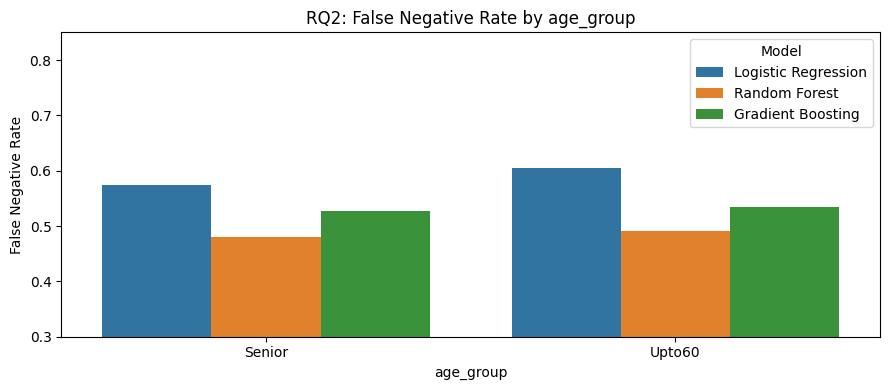

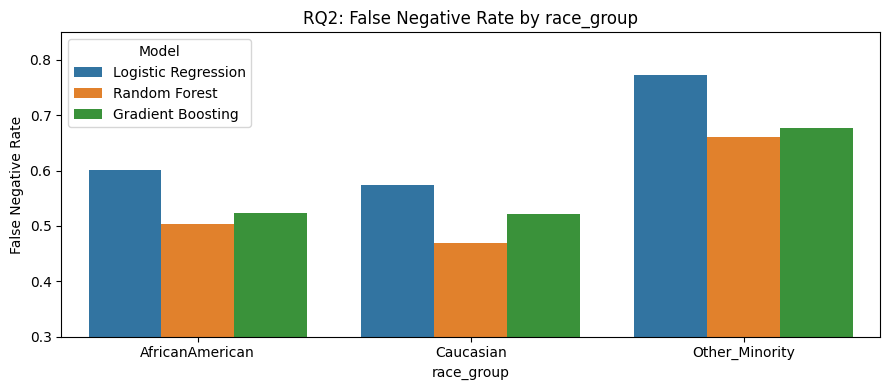

In [ ]:
# Generate separate bar charts to compare model FNR
# across categories within each demographic variable
# (gender, age_group, and race_group).

for group_col in ['gender', 'age_group', 'race_group']:
    subset = rq2_fnr_df[rq2_fnr_df['Demographic Variable'] == group_col]

    plt.figure(figsize=(9, 4))
    sns.barplot(
        data=subset,
        x='Category',
        y='FNR',
        hue='Model'
    )
    plt.title(f'RQ2: False Negative Rate by {group_col}')
    plt.ylabel('False Negative Rate')
    plt.xlabel(group_col)
    plt.ylim(0.3, 0.85)

    for container in ax.containers:
        ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

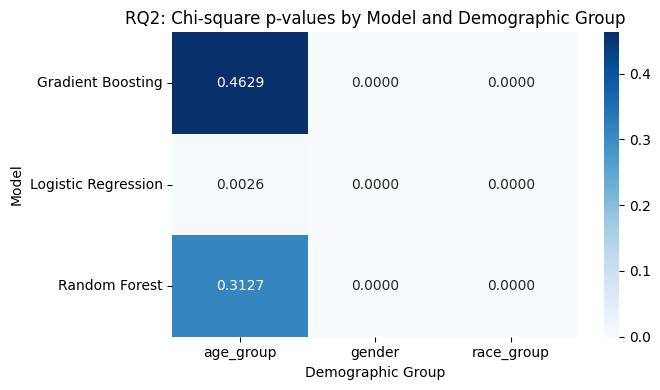

In [ ]:
# Create a heatmap visualization of Chi-square p-values
# to compare statistical significance of demographic
# performance differences across models and groups.

rq2_pivot = rq2_pvalue_summary.pivot(
    index='Model',
    columns='Demographic Group',
    values='p-value'
)

plt.figure(figsize=(7, 4))
sns.heatmap(
    rq2_pivot,
    annot=True,
    fmt=".4f",
    cmap="Blues"
)
plt.title('RQ2: Chi-square p-values by Model and Demographic Group')
plt.tight_layout()
plt.show()

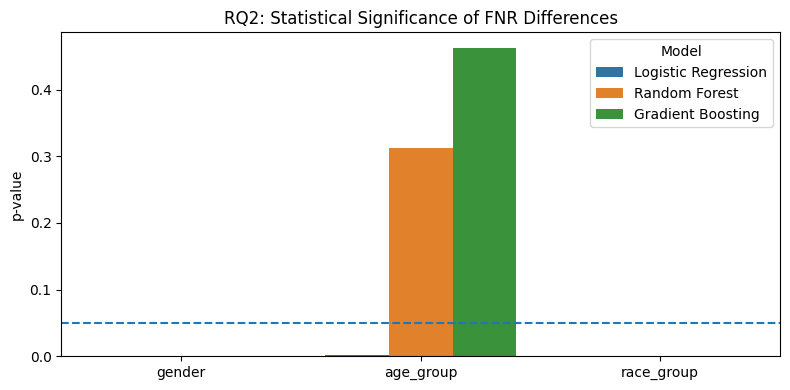

In [ ]:
# Identify statistically significant demographic differences
# and visualize model-wise Chi-square p-values against the
# significance threshold (p = 0.05).

rq2_sig = rq2_pvalue_summary.copy()
rq2_sig['Significant'] = rq2_sig['p-value'] < 0.05

plt.figure(figsize=(8, 4))
sns.barplot(
    data=rq2_sig,
    x='Demographic Group',
    y='p-value',
    hue='Model'
)
plt.axhline(0.05, linestyle='--')
plt.title('RQ2: Statistical Significance of FNR Differences')
plt.ylabel('p-value')
plt.xlabel('')
plt.tight_layout()
plt.show()

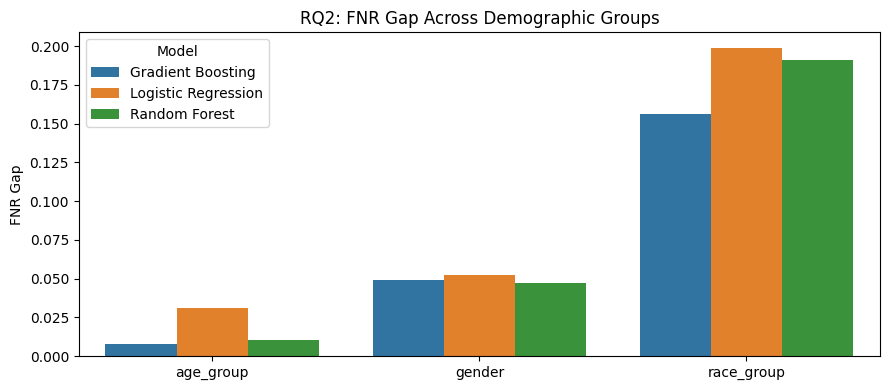

In [ ]:
# ==============================================================================
# This function computes the False Negative Rate (FNR) gap for each model and
# demographic variable, then visualizes the disparities using bar chart.
#
# Input:
# - rq2_fnr_df: DataFrame containing:
#     • model names
#     • demographic variables
#     • subgroup categories
#     • FNR values
#
#
# Returns: DataFrame containing:
#     • Model
#     • Demographic Variable
#     • Computed FNR Gap
# ==============================================================================

def build_rq2_gap_table(rq2_fnr_df):
    gap_rows = []

    for (model, demo), group_df in rq2_fnr_df.groupby(['Model', 'Demographic Variable']):
        gap_rows.append({
            'Model': model,
            'Demographic Variable': demo,
            'FNR Gap': group_df['FNR'].max() - group_df['FNR'].min()
        })

    return pd.DataFrame(gap_rows)

rq2_gap_df = build_rq2_gap_table(rq2_fnr_df)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=rq2_gap_df,
    x='Demographic Variable',
    y='FNR Gap',
    hue='Model'
)
plt.title('RQ2: FNR Gap Across Demographic Groups')
plt.ylabel('FNR Gap')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Robustness checks after treating outliers**

In [ ]:
# Execute the complete RQ2 evaluation pipeline for each preprocessing approach by:
# - preparing train-test datasets - original, outliers treated (Log Norm, 99% cap)
# - training all models,
# - generating predictions,
# - performing demographic fairness analysis,
# - and printing Chi-square p-value summaries.

datasets = {
    'Original': (X_original, DiabData_df),
    'Log Transform': (X_log, DiabData_log),
    '99% Capping': (X_cap, DiabData_cap),
}

for name, (X_data, source_df) in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    X_train, X_test, y_train, y_test = prepare_train_test_datasets(
        X_data,
        y,
        source_df,
        numeric_cols,
        random_state=42
    )

    results_by_model, accuracy_summary = train_and_predict_models(
        X_train,
        X_test,
        y_train,
        y_test,
        source_df
    )

    rq2_outputs, rq2_pvalues = run_rq2_all_models(results_by_model)

    print("\nRQ2 p-values:")
    print(rq2_pvalues)




Original

Training model: Logistic Regression
Completed: Logistic Regression
Train Accuracy: 0.6168
Test Accuracy : 0.6205
Execution Time: 0.50 sec

Training model: Random Forest
Completed: Random Forest
Train Accuracy: 0.9991
Test Accuracy : 0.6040
Execution Time: 17.15 sec

Training model: Gradient Boosting
Completed: Gradient Boosting
Train Accuracy: 0.6276
Test Accuracy : 0.6241
Execution Time: 8.18 sec

RQ2 p-values:
                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.00000
1  Logistic Regression         age_group  0.00022
2  Logistic Regression        race_group  0.00000
3        Random Forest            gender  0.00000
4        Random Forest         age_group  0.52874
5        Random Forest        race_group  0.00000
6    Gradient Boosting            gender  0.00000
7    Gradient Boosting         age_group  0.41847
8    Gradient Boosting        race_group  0.00000

Log Transform

Training model: Logistic Regression
Completed: Logistic R

# Common functions across RQ3, RQ4 and RQ5

In [ ]:
# ------------------------------------------------------
# Core helper functions common across RQ3, RQ4 and RQ5
# -------------------------------------------------------

# compute_fnr_gap:
# Computes the difference between the highest and lowest False Negative Rate
# across categories of a demographic group.

def compute_fnr_gap(df, group_col, pred_col='predicted'):
    pos = df[df['actual'] == 1].copy()

    if pos.empty:
        return np.nan

    fnr = pos.groupby(group_col)[pred_col].apply(lambda x: (x == 0).mean())
    fnr = fnr.dropna()

    if len(fnr) < 2:
        return np.nan

    return fnr.max() - fnr.min()

#------------------------------------------------------------------------------
# prepare_split:
# Splits data into stratified train/test sets, scales numeric features,
# and reattaches demographic columns for the test set.

def prepare_split(X_original, y, source_df, numeric_cols, random_state, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X_original,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    demographics = pd.DataFrame({
        'gender': source_df.loc[X_test.index, 'gender'].values,
        'age_group': source_df.loc[X_test.index, 'age_group'].values,
        'race_group': source_df.loc[X_test.index, 'race_group'].values
    }, index=X_test.index)

    return X_train, X_test, y_train, y_test, demographics
#------------------------------------------------------------------------------

# build_results_df:
# Creates a results dataframe containing demographics, actual labels,
# and model predictions.

def build_results_df(y_test, y_pred, demographics, pred_col_name):
    results = demographics.copy()
    results['actual'] = y_test.values
    results[pred_col_name] = y_pred
    return results

#------------------------------------------------------------------------------
# compute_all_fnr_gaps:
# Computes FNR gaps for gender, age group, and race group.

def compute_all_fnr_gaps(results_df, pred_col):
    return {
        'gender': compute_fnr_gap(results_df, 'gender', pred_col),
        'age': compute_fnr_gap(results_df, 'age_group', pred_col),
        'race': compute_fnr_gap(results_df, 'race_group', pred_col)
    }

#------------------------------------------------------------------------------
# rebalance_training_data:
# Balances the training data by upsampling the minority class
# to match the majority class size.

def rebalance_training_data(X_train, y_train, random_state):
    train_df = X_train.copy()
    train_df['target'] = y_train.values

    majority = train_df[train_df['target'] == 0]
    minority = train_df[train_df['target'] == 1]

    minority_upsampled = resample(
        minority,
        replace=True,
        n_samples=len(majority),
        random_state=random_state
    )

    balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=random_state)

    Xb = balanced.drop(columns=['target'])
    yb = balanced['target']

    return Xb, yb
#------------------------------------------------------------------------------

# make_model:
# Creates and returns the selected machine learning model,
# optionally applying class-weight mitigation.

def make_model(model_name, mitigation='none', random_state=42):
    """
    mitigation options:
        'none'
        'class_weight'
    oversampling is handled at the data level, not here
    """

    if model_name == 'logistic':
        if mitigation == 'class_weight':
            return LogisticRegression(
                max_iter=2000,
                solver='lbfgs',
                class_weight='balanced',
                random_state=random_state
            )
        return LogisticRegression(
            max_iter=2000,
            solver='lbfgs',
            random_state=random_state
        )

    elif model_name == 'random_forest':
        if mitigation == 'class_weight':
            return RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=random_state,
                n_jobs=-1
            )
        return RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )

    elif model_name == 'gradient_boosting':
        # Standard GradientBoostingClassifier does not support class_weight directly
        if mitigation == 'class_weight':
            raise ValueError("Gradient Boosting does not directly support class_weight in this setup.")
        return GradientBoostingClassifier(random_state=random_state)

    else:
        raise ValueError("model_name must be: 'logistic', 'random_forest', or 'gradient_boosting'")
#------------------------------------------------------------------------------

# run_paired_test:
# Runs a paired t-test comparing before vs after metric values
# and returns test statistics and summary values.

def run_paired_test(before, after, label):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)

    mask = ~np.isnan(before) & ~np.isnan(after)
    before = before[mask]
    after = after[mask]

    p = ttest_rel(before, after).pvalue

    print(f"{label} p-value: {p}")
    print(f"{label} mean BEFORE: {np.mean(before)}")
    print(f"{label} mean AFTER : {np.mean(after)}")
    print(f"{label} valid runs : {len(before)}")
    print("-" * 40)

    return {
        'label': label,
        'p_value': p,
        'mean_before': np.mean(before),
        'mean_after': np.mean(after),
        'valid_runs': len(before)
    }

#------------------------------------------------------------------------------

# make_group_plot_df:
# Converts before/after FNR gap dictionaries into a long-format
# dataframe suitable for plotting.

def make_group_plot_df(before_dict, after_dict):
    dfs = []

    mapping = {
        'gender': 'Gender',
        'age': 'Age',
        'race': 'Race'
    }

    for key in ['gender', 'age', 'race']:
        df = pd.DataFrame({
            'Before': before_dict[key],
            'After': after_dict[key]
        }).melt(var_name='Condition', value_name='FNR Gap')
        df['Group'] = mapping[key]
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

#------------------------------------------------------------------------------
# plot_fnr_boxplots:
# Creates boxplots comparing before vs after FNR gaps
# for gender, age, and race groups.

def plot_fnr_boxplots(before_dict, after_dict, title):
    df_all = make_group_plot_df(before_dict, after_dict)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, grp in zip(axes, ['Gender', 'Age', 'Race']):
        subset = df_all[df_all['Group'] == grp]
        sns.boxplot(data=subset, x='Condition', y='FNR Gap', ax=ax)
        ax.set_title(grp)
        ax.set_xlabel('')
        if grp != 'Gender':
            ax.set_ylabel('')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

#------------------------------------------------------------------------------
# plot_fnr_means:
# Plots mean before vs after FNR gaps for each demographic group.

def plot_fnr_means(before_dict, after_dict, title):
    labels = [
        'Gender Before', 'Gender After',
        'Age Before', 'Age After',
        'Race Before', 'Race After'
    ]

    means = [
        np.nanmean(before_dict['gender']), np.nanmean(after_dict['gender']),
        np.nanmean(before_dict['age']), np.nanmean(after_dict['age']),
        np.nanmean(before_dict['race']), np.nanmean(after_dict['race'])
    ]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, means)
    plt.xticks(rotation=45)
    plt.ylabel('Mean FNR Gap')
    plt.title(title)
    plt.tight_layout()
    plt.show()

#------------------------------------------------------------------------------
# plot_auc_boxplot:
# Creates a boxplot comparing model AUC before and after mitigation.

def plot_auc_boxplot(auc_before, auc_after, title):
    df_auc = pd.DataFrame({
        'Before': auc_before,
        'After': auc_after
    }).melt(var_name='Condition', value_name='AUC')

    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Condition', y='AUC', data=df_auc)
    plt.title(title)
    plt.ylabel('AUC')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()


#------------------------------------------------------------------------------
# run_experiment:
# Runs repeated baseline vs mitigation experiments, measuring
# demographic FNR gaps and AUC across multiple random train/test splits

def run_experiment(
    X_original,
    y,
    source_df,
    numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
):
    """
    compare_mode:
        'rq3' -> baseline vs mitigation_strategy (usually oversample)
        'rq4' -> baseline vs mitigation_strategy

    mitigation_strategy:
        'oversample'
        'class_weight'
    """

    gaps_before = {'gender': [], 'age': [], 'race': []}
    gaps_after = {'gender': [], 'age': [], 'race': []}

    auc_before = []
    auc_after = []

    for i in range(n_runs):
        X_train, X_test, y_train, y_test, demographics = prepare_split(
            X_original, y, source_df, numeric_cols, random_state=i
        )

        # -----------------------------
        # Baseline model
        # -----------------------------
        base_model = make_model(model_name, mitigation='none', random_state=i)
        base_model.fit(X_train, y_train)

        y_pred_base = base_model.predict(X_test)
        y_prob_base = base_model.predict_proba(X_test)[:, 1]

        results_base = build_results_df(y_test, y_pred_base, demographics, pred_col_name='predicted_base')
        base_gaps = compute_all_fnr_gaps(results_base, 'predicted_base')

        gaps_before['gender'].append(base_gaps['gender'])
        gaps_before['age'].append(base_gaps['age'])
        gaps_before['race'].append(base_gaps['race'])

        auc_before.append(roc_auc_score(y_test, y_prob_base))

        # -----------------------------
        # Comparison model
        # -----------------------------
        if mitigation_strategy == 'oversample':
            X_comp, y_comp = rebalance_training_data(X_train, y_train, random_state=i)
            comp_model = make_model(model_name, mitigation='none', random_state=i)

        elif mitigation_strategy == 'class_weight':
            if model_name == 'gradient_boosting':
                raise ValueError("Gradient Boosting does not support class_weight in this setup.")
            X_comp, y_comp = X_train, y_train
            comp_model = make_model(model_name, mitigation='class_weight', random_state=i)

        else:
            raise ValueError("mitigation_strategy must be 'oversample' or 'class_weight'")

        comp_model.fit(X_comp, y_comp)

        y_pred_comp = comp_model.predict(X_test)
        y_prob_comp = comp_model.predict_proba(X_test)[:, 1]

        results_comp = build_results_df(y_test, y_pred_comp, demographics, pred_col_name='predicted_comp')
        comp_gaps = compute_all_fnr_gaps(results_comp, 'predicted_comp')

        gaps_after['gender'].append(comp_gaps['gender'])
        gaps_after['age'].append(comp_gaps['age'])
        gaps_after['race'].append(comp_gaps['race'])

        auc_after.append(roc_auc_score(y_test, y_prob_comp))

    return {
        'model_name': model_name,
        'compare_mode': compare_mode,
        'mitigation_strategy': mitigation_strategy,
        'gaps_before': gaps_before,
        'gaps_after': gaps_after,
        'auc_before': auc_before,
        'auc_after': auc_after
    }

In [ ]:
# ==============================================================================
# This function creates a statistical summary table for a mitigation experiment
# by comparing fairness and performance metrics before and after
# applying a mitigation strategy.
#
# Input:
# - result_obj: Dictionary returned by run_experiment() containing:
#     • model information
#     • mitigation strategy
#     • FNR gap results before and after mitigation
#     • AUC results before and after mitigation
#
# - label_prefix:
#     Optional custom label for the experiment summary.
#     If not provided, a label is generated automatically.
#
#
# Returns: DataFrame containing:
#     • experiment details
#     • fairness/performance metrics
#     • mean before/after values
#     • mitigation impact (delta)
#     • statistical significance (p-values)
#     • valid run counts
# ==============================================================================

def summarize_experiment(result_obj, label_prefix=None):

    rows = []

    model_name = result_obj['model_name']
    mitigation = result_obj['mitigation_strategy']

    if label_prefix is None:
        label_prefix = f"{model_name}_{mitigation}"

    # demographic groups
    for group in ['gender', 'age', 'race']:
        before = np.array(result_obj['gaps_before'][group], dtype=float)
        after = np.array(result_obj['gaps_after'][group], dtype=float)

        mask = ~np.isnan(before) & ~np.isnan(after)
        before_clean = before[mask]
        after_clean = after[mask]

        p_val = ttest_rel(before_clean, after_clean).pvalue if len(before_clean) > 1 else np.nan

        rows.append({
            'Experiment': label_prefix,
            'Model': model_name,
            'Mitigation': mitigation,
            'Metric': 'FNR Gap',
            'Group': group.capitalize(),
            'Mean Before': np.mean(before_clean) if len(before_clean) > 0 else np.nan,
            'Mean After': np.mean(after_clean) if len(after_clean) > 0 else np.nan,
            'Delta (After-Before)': (
                np.mean(after_clean) - np.mean(before_clean)
                if len(before_clean) > 0 else np.nan
            ),
            'p-value': p_val,
            'Valid Runs': len(before_clean)
        })

    # AUC summary
    auc_before = np.array(result_obj['auc_before'], dtype=float)
    auc_after = np.array(result_obj['auc_after'], dtype=float)

    mask_auc = ~np.isnan(auc_before) & ~np.isnan(auc_after)
    auc_before = auc_before[mask_auc]
    auc_after = auc_after[mask_auc]

    p_auc = ttest_rel(auc_before, auc_after).pvalue if len(auc_before) > 1 else np.nan

    rows.append({
        'Experiment': label_prefix,
        'Model': model_name,
        'Mitigation': mitigation,
        'Metric': 'AUC',
        'Group': 'Overall',
        'Mean Before': np.mean(auc_before) if len(auc_before) > 0 else np.nan,
        'Mean After': np.mean(auc_after) if len(auc_after) > 0 else np.nan,
        'Delta (After-Before)': (
            np.mean(auc_after) - np.mean(auc_before)
            if len(auc_before) > 0 else np.nan
        ),
        'p-value': p_auc,
        'Valid Runs': len(auc_before)
    })

    return pd.DataFrame(rows)

# Research question #3 : Impact of Dataset Imbalance

In [ ]:
# Run the RQ3 fairness experiment for Logistic Regression
# by comparing baseline performance against oversampling-based
# mitigation across multiple train-test runs.

rq3_logistic = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether oversampling
# mitigation significantly changes FNR gaps for gender,
# age, and race demographic groups in the Logistic Regression model.

run_paired_test(rq3_logistic['gaps_before']['gender'], rq3_logistic['gaps_after']['gender'], "Gender RQ3 Logistic")
run_paired_test(rq3_logistic['gaps_before']['age'], rq3_logistic['gaps_after']['age'], "Age RQ3 Logistic")
run_paired_test(rq3_logistic['gaps_before']['race'], rq3_logistic['gaps_after']['race'], "Race RQ3 Logistic")

Gender RQ3 Logistic p-value: 2.3582074148864204e-08
Gender RQ3 Logistic mean BEFORE: 0.050827823067450394
Gender RQ3 Logistic mean AFTER : 0.06333947431780583
Gender RQ3 Logistic valid runs : 35
----------------------------------------
Age RQ3 Logistic p-value: 1.2451875994793787e-18
Age RQ3 Logistic mean BEFORE: 0.035830296865070846
Age RQ3 Logistic mean AFTER : 0.06519977389711336
Age RQ3 Logistic valid runs : 35
----------------------------------------
Race RQ3 Logistic p-value: 6.883129155573233e-25
Race RQ3 Logistic mean BEFORE: 0.19111308884870765
Race RQ3 Logistic mean AFTER : 0.2535579346830661
Race RQ3 Logistic valid runs : 35
----------------------------------------


{'label': 'Race RQ3 Logistic',
 'p_value': np.float64(6.883129155573233e-25),
 'mean_before': np.float64(0.19111308884870765),
 'mean_after': np.float64(0.2535579346830661),
 'valid_runs': 35}

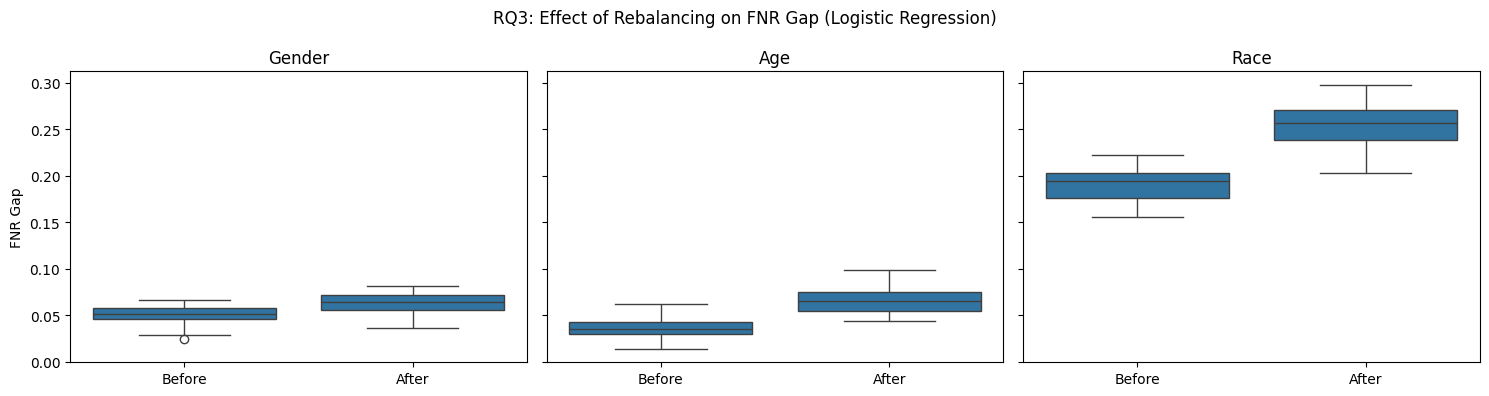

In [ ]:
# Visualize the distribution of FNR gaps before and after
# oversampling mitigation across gender, age, and race
# demographic groups for the Logistic Regression model.

plot_fnr_boxplots(
    rq3_logistic['gaps_before'],
    rq3_logistic['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Logistic Regression)'
)

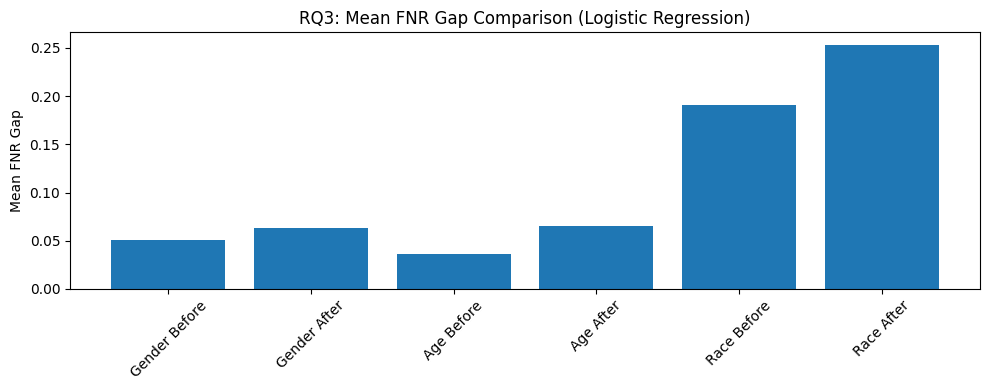

In [ ]:
# Compare mean FNR gaps before and after oversampling
# mitigation across demographic groups for the
# Logistic Regression model.

plot_fnr_means(
    rq3_logistic['gaps_before'],
    rq3_logistic['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Logistic Regression)'
)

In [ ]:
# Run the RQ3 fairness experiment for Random Forest
# by comparing baseline performance against oversampling-based
# mitigation across multiple train-test runs.

rq3_rf = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether oversampling
# mitigation significantly changes FNR gaps for gender,
# age, and race demographic groups in the Random Forest model.

run_paired_test(rq3_rf['gaps_before']['gender'], rq3_rf['gaps_after']['gender'], "Gender RQ3 RF")
run_paired_test(rq3_rf['gaps_before']['age'], rq3_rf['gaps_after']['age'], "Age RQ3 RF")
run_paired_test(rq3_rf['gaps_before']['race'], rq3_rf['gaps_after']['race'], "Race RQ3 RF")

Gender RQ3 RF p-value: 0.03978175758989073
Gender RQ3 RF mean BEFORE: 0.04363382754648752
Gender RQ3 RF mean AFTER : 0.04087701007280603
Gender RQ3 RF valid runs : 35
----------------------------------------
Age RQ3 RF p-value: 0.2613353259767722
Age RQ3 RF mean BEFORE: 0.010341693881220484
Age RQ3 RF mean AFTER : 0.00834755042257449
Age RQ3 RF valid runs : 35
----------------------------------------
Race RQ3 RF p-value: 1.0758878477082317e-08
Race RQ3 RF mean BEFORE: 0.1620851606759036
Race RQ3 RF mean AFTER : 0.1412314601833161
Race RQ3 RF valid runs : 35
----------------------------------------


{'label': 'Race RQ3 RF',
 'p_value': np.float64(1.0758878477082317e-08),
 'mean_before': np.float64(0.1620851606759036),
 'mean_after': np.float64(0.1412314601833161),
 'valid_runs': 35}

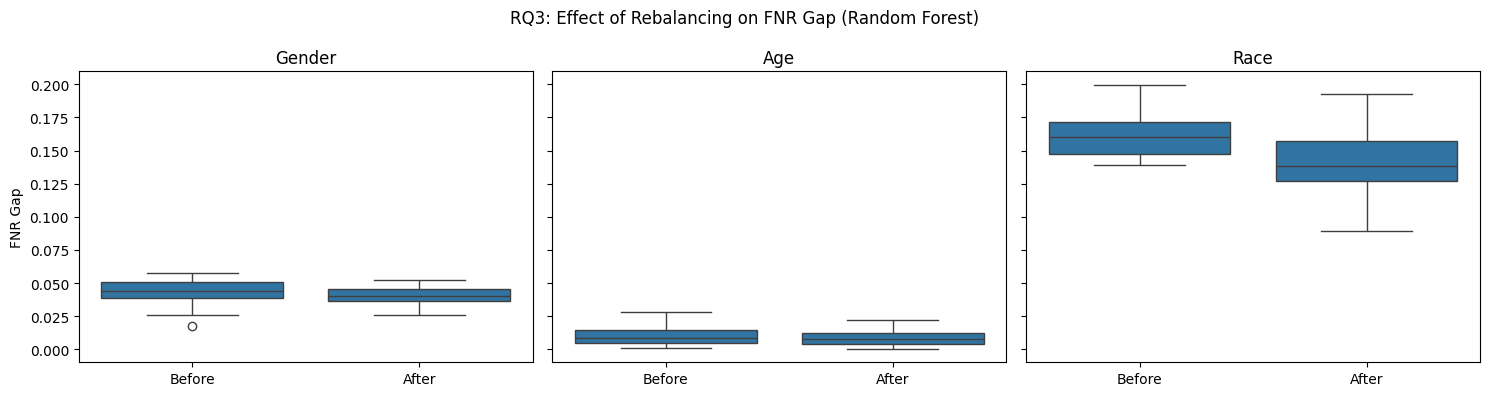

In [ ]:
# Visualize the distribution of FNR gaps before and after
# oversampling mitigation across gender, age, and race
# demographic groups for the Random Forest model.

plot_fnr_boxplots(
    rq3_rf['gaps_before'],
    rq3_rf['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Random Forest)'
)

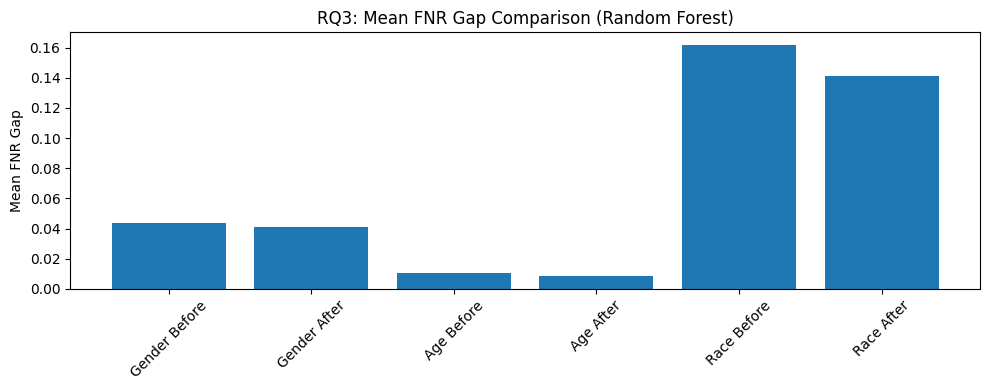

In [ ]:
# Compare mean FNR gaps before and after oversampling
# mitigation across demographic groups for the
# Random Forest model.

plot_fnr_means(
    rq3_rf['gaps_before'],
    rq3_rf['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Random Forest)'
)

In [ ]:
# Run the RQ3 fairness experiment for Gradient Boosting
# by comparing baseline performance against oversampling-based
# mitigation across multiple train-test runs.

rq3_gb = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='gradient_boosting',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether oversampling
# mitigation significantly changes FNR gaps for gender,
# age, and race demographic groups in the Gradient Boost model.

run_paired_test(rq3_gb['gaps_before']['gender'], rq3_gb['gaps_after']['gender'], "Gender RQ3 GB")
run_paired_test(rq3_gb['gaps_before']['age'], rq3_gb['gaps_after']['age'], "Age RQ3 GB")
run_paired_test(rq3_gb['gaps_before']['race'], rq3_gb['gaps_after']['race'], "Race RQ3 GB")

Gender RQ3 GB p-value: 0.0003541036813540629
Gender RQ3 GB mean BEFORE: 0.03514244132629089
Gender RQ3 GB mean AFTER : 0.04090731741948208
Gender RQ3 GB valid runs : 35
----------------------------------------
Age RQ3 GB p-value: 3.8243625189091434e-09
Age RQ3 GB mean BEFORE: 0.007429924235075516
Age RQ3 GB mean AFTER : 0.02416004188339782
Age RQ3 GB valid runs : 35
----------------------------------------
Race RQ3 GB p-value: 2.688522550263838e-06
Race RQ3 GB mean BEFORE: 0.16151145113435816
Race RQ3 GB mean AFTER : 0.1767354449369953
Race RQ3 GB valid runs : 35
----------------------------------------


{'label': 'Race RQ3 GB',
 'p_value': np.float64(2.688522550263838e-06),
 'mean_before': np.float64(0.16151145113435816),
 'mean_after': np.float64(0.1767354449369953),
 'valid_runs': 35}

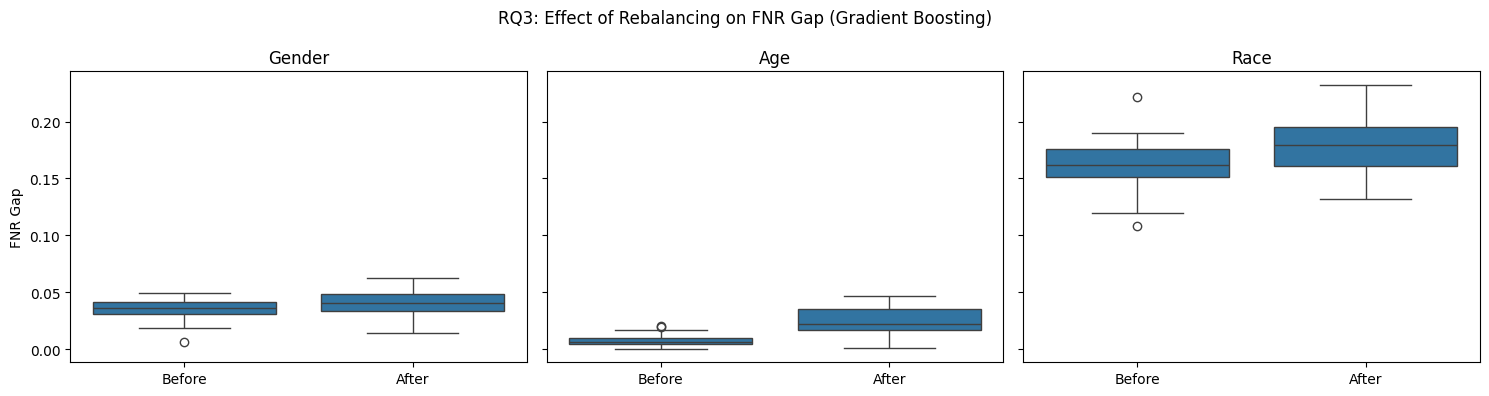

In [ ]:
# Visualize the distribution of FNR gaps before and after
# oversampling mitigation across gender, age, and race
# demographic groups for the Gradient Boost model.

plot_fnr_boxplots(
    rq3_gb['gaps_before'],
    rq3_gb['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Gradient Boosting)'
)

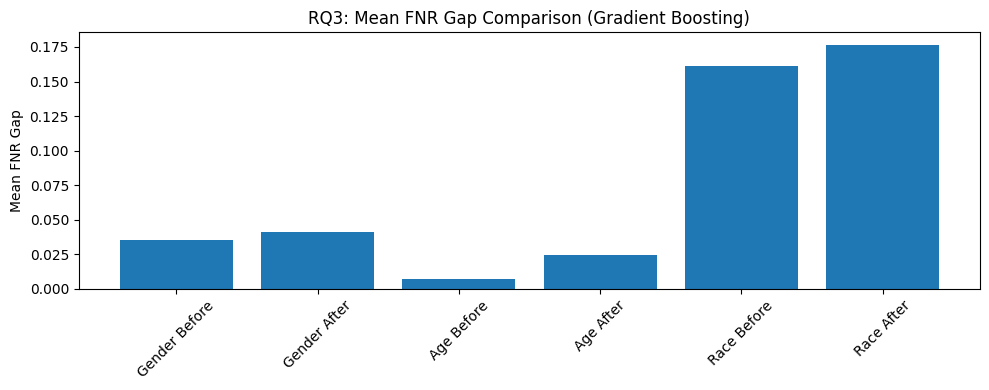

In [ ]:
# Compare mean FNR gaps before and after oversampling
# mitigation across demographic groups for the
# Gradient Boost model.

plot_fnr_means(
    rq3_gb['gaps_before'],
    rq3_gb['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Gradient Boosting)'
)

In [ ]:
# Combine experiment summaries for all RQ3 models into a
# single dataframe to compare fairness and performance
# metrics across mitigation experiments.

summary_rq3 = pd.concat([
    summarize_experiment(rq3_logistic, "Logistic_RQ3"),
    summarize_experiment(rq3_rf, "RandomForest_RQ3"),
    summarize_experiment(rq3_gb, "GradientBoosting_RQ3")
], ignore_index=True)

summary_rq3

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Logistic_RQ3,logistic,oversample,FNR Gap,Gender,0.05083,0.06334,0.01251,0.00000,35
1,Logistic_RQ3,logistic,oversample,FNR Gap,Age,0.03583,0.06520,0.02937,0.00000,35
2,Logistic_RQ3,logistic,oversample,FNR Gap,Race,0.19111,0.25356,0.06244,0.00000,35
3,Logistic_RQ3,logistic,oversample,AUC,Overall,0.65502,0.65488,-0.00014,0.00439,35
4,RandomForest_RQ3,random_forest,oversample,FNR Gap,Gender,0.04363,0.04088,-0.00276,0.03978,35
5,RandomForest_RQ3,random_forest,oversample,FNR Gap,Age,0.01034,0.00835,-0.00199,0.26134,35
6,RandomForest_RQ3,random_forest,oversample,FNR Gap,Race,0.16209,0.14123,-0.02085,0.00000,35
7,RandomForest_RQ3,random_forest,oversample,AUC,Overall,0.63427,0.63107,-0.00319,0.00000,35
8,GradientBoosting_RQ3,gradient_boosting,oversample,FNR Gap,Gender,0.03514,0.04091,0.00576,0.00035,35
9,GradientBoosting_RQ3,gradient_boosting,oversample,FNR Gap,Age,0.00743,0.02416,0.01673,0.00000,35


In [ ]:
# Prepare RQ3 fairness results for visualization by:
# - filtering FNR Gap metrics,
# - reshaping before/after values into long format,
# - and simplifying condition labels for plotting.

# Keep only FNR Gap rows
rq3_plot_df = summary_rq3[
    summary_rq3['Metric'] == 'FNR Gap'
].copy()

# reshape the dataFrame from a wide format to a long format
rq3_plot_df = rq3_plot_df.melt(
    id_vars=['Model', 'Group'],
    value_vars=['Mean Before', 'Mean After'],
    var_name='Condition',
    value_name='FNR Gap'
)

# Clean labels
rq3_plot_df['Condition'] = rq3_plot_df['Condition'].replace({
    'Mean Before': 'Before',
    'Mean After': 'After'
})

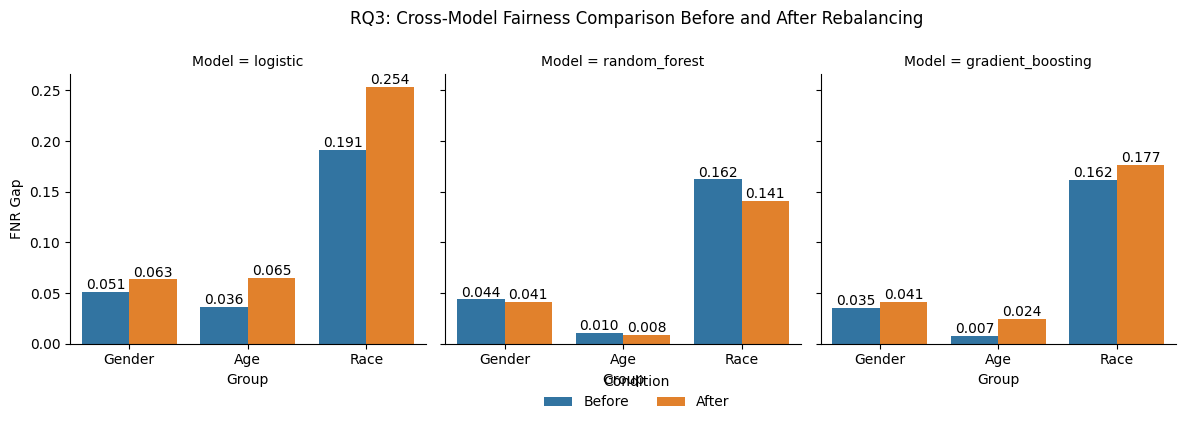

In [ ]:
# Create grouped bar charts to compare demographic FNR gaps
# before and after rebalancing across models, with separate
# panels for each model and labeled bars for easier interpretation.

# Visulaize the plot
g = sns.catplot(
    data=rq3_plot_df,
    x='Group',
    y='FNR Gap',
    hue='Condition',
    col='Model',
    kind='bar',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.82)

g.fig.suptitle(
    'RQ3: Cross-Model Fairness Comparison Before and After Rebalancing'
)

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f')

plt.show()

**Robustness checks after treating outliers**

In [ ]:
# Run RQ3 fairness experiments for Logistic Regression
# across different preprocessing approaches:
# - original dataset
# - log-transformed dataset
# - 99% capped dataset
#
# Each experiment evaluates the impact of oversampling
# mitigation on demographic fairness over multiple runs.


# 1. Run RQ3 Logistic on Original data
rq3_logistic_original = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

# 2. Run RQ3 Logistic on Log-transformed data
rq3_logistic_log = run_experiment(
    X_original=X_log,
    y=y,
    source_df=DiabData_log,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

# 3. Run RQ3 Logistic on 99% capped data
rq3_logistic_cap = run_experiment(
    X_original=X_cap,
    y=y,
    source_df=DiabData_cap,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Combine and summarize RQ3 Logistic Regression experiments
# across different preprocessing approaches, filter fairness
# metrics (FNR Gap), and round statistical results for readability.

# Generate Summary Tables
summary_rq3_logistic_outlier = pd.concat([
    summarize_experiment(rq3_logistic_original, "Original"),
    summarize_experiment(rq3_logistic_log, "Log Transform"),
    summarize_experiment(rq3_logistic_cap, "99% Capping")
], ignore_index=True)

# Keep only FNR Gap rows
summary_rq3_logistic_outlier = summary_rq3_logistic_outlier[
    summary_rq3_logistic_outlier['Metric'] == 'FNR Gap'
].copy()

# Round for readability
for col in ['Mean Before', 'Mean After', 'Delta (After-Before)', 'p-value']:
    summary_rq3_logistic_outlier[col] = summary_rq3_logistic_outlier[col].round(6)

summary_rq3_logistic_outlier

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Original,logistic,oversample,FNR Gap,Gender,0.05083,0.06334,0.01251,0.00000,35
1,Original,logistic,oversample,FNR Gap,Age,0.03583,0.06520,0.02937,0.00000,35
2,Original,logistic,oversample,FNR Gap,Race,0.19111,0.25356,0.06245,0.00000,35
4,Log Transform,logistic,oversample,FNR Gap,Gender,0.04034,0.04990,0.00956,0.00000,35
5,Log Transform,logistic,oversample,FNR Gap,Age,0.01638,0.03119,0.01481,0.00000,35
6,Log Transform,logistic,oversample,FNR Gap,Race,0.18455,0.20788,0.02333,0.00000,35
8,99% Capping,logistic,oversample,FNR Gap,Gender,0.04842,0.06007,0.01165,0.00000,35
9,99% Capping,logistic,oversample,FNR Gap,Age,0.02904,0.05709,0.02805,0.00000,35
10,99% Capping,logistic,oversample,FNR Gap,Race,0.18563,0.23968,0.05405,0.00000,35


In [ ]:
# Define and execute paired t-tests to evaluate whether oversampling mitigation
# significantly changes demographic FNR gaps for Logistic Regression
# across different preprocessing approaches.

def print_rq3_logistic_outlier_tests(result_obj, label):
    print("\n" + "=" * 70)
    print(f"RQ3 Logistic Regression - {label}")
    print("=" * 70)

    run_paired_test(
        result_obj['gaps_before']['gender'],
        result_obj['gaps_after']['gender'],
        f"Gender RQ3 Logistic - {label}"
    )

    run_paired_test(
        result_obj['gaps_before']['age'],
        result_obj['gaps_after']['age'],
        f"Age RQ3 Logistic - {label}"
    )

    run_paired_test(
        result_obj['gaps_before']['race'],
        result_obj['gaps_after']['race'],
        f"Race RQ3 Logistic - {label}"
    )


print_rq3_logistic_outlier_tests(rq3_logistic_original, "Original")
print_rq3_logistic_outlier_tests(rq3_logistic_log, "Log Transform")
print_rq3_logistic_outlier_tests(rq3_logistic_cap, "99% Capping")


RQ3 Logistic Regression - Original
Gender RQ3 Logistic - Original p-value: 2.3582074148864204e-08
Gender RQ3 Logistic - Original mean BEFORE: 0.050827823067450394
Gender RQ3 Logistic - Original mean AFTER : 0.06333947431780583
Gender RQ3 Logistic - Original valid runs : 35
----------------------------------------
Age RQ3 Logistic - Original p-value: 1.2451875994793787e-18
Age RQ3 Logistic - Original mean BEFORE: 0.035830296865070846
Age RQ3 Logistic - Original mean AFTER : 0.06519977389711336
Age RQ3 Logistic - Original valid runs : 35
----------------------------------------
Race RQ3 Logistic - Original p-value: 6.883129155573233e-25
Race RQ3 Logistic - Original mean BEFORE: 0.19111308884870765
Race RQ3 Logistic - Original mean AFTER : 0.2535579346830661
Race RQ3 Logistic - Original valid runs : 35
----------------------------------------

RQ3 Logistic Regression - Log Transform
Gender RQ3 Logistic - Log Transform p-value: 4.938376449667033e-10
Gender RQ3 Logistic - Log Transform mea

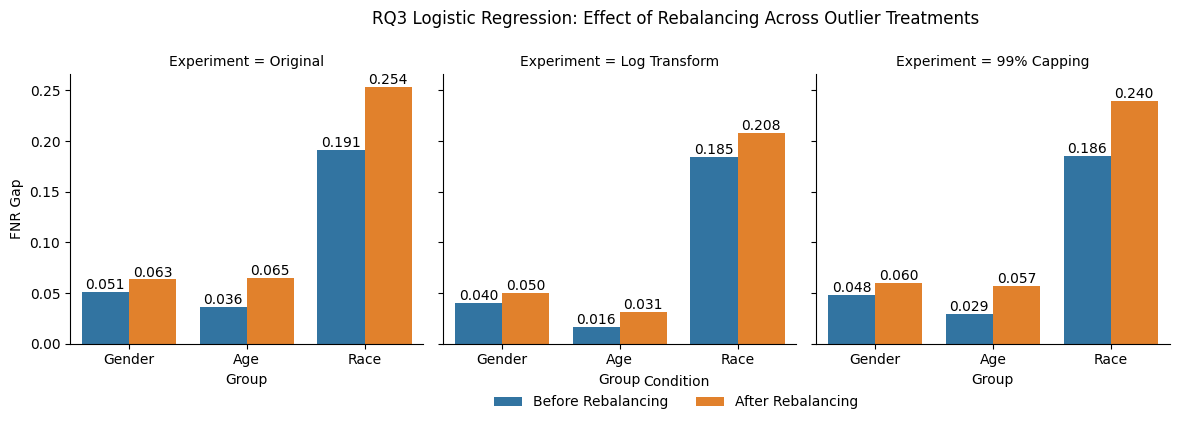

In [ ]:
# Prepare and visualize RQ3 Logistic Regression fairness results by comparing
# demographic FNR gaps before and after rebalancing across different
# outlier treatment approaches.

plot_df = summary_rq3_logistic_outlier.melt(
    id_vars=['Experiment', 'Group'],
    value_vars=['Mean Before', 'Mean After'],
    var_name='Condition',
    value_name='FNR Gap'
)

plot_df['Condition'] = plot_df['Condition'].replace({
    'Mean Before': 'Before Rebalancing',
    'Mean After': 'After Rebalancing'
})

g = sns.catplot(
    data=plot_df,
    x='Group',
    y='FNR Gap',
    hue='Condition',
    col='Experiment',
    kind='bar',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('RQ3 Logistic Regression: Effect of Rebalancing Across Outlier Treatments')

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

plt.show()

**Observation and Insights:**
**Treating outliers reduces the severity of bias, but does not change the overall conclusion that rebalancing worsens fairness in Logistic Regression.”**

# Research question #4 : Effectiveness of Bias Mitigation

In [ ]:
# Run the RQ4 fairness experiment for Logistic Regression
# by comparing baseline performance against class-weight
# mitigation across multiple train-test runs.

rq4_logistic_cw = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether class-weight
# mitigation significantly changes demographic FNR gaps
# and overall AUC performance for the Logistic Regression model.

run_paired_test(rq4_logistic_cw['gaps_before']['gender'], rq4_logistic_cw['gaps_after']['gender'], "Gender RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['gaps_before']['age'], rq4_logistic_cw['gaps_after']['age'], "Age RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['gaps_before']['race'], rq4_logistic_cw['gaps_after']['race'], "Race RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['auc_before'], rq4_logistic_cw['auc_after'], "AUC RQ4 Logistic ClassWeight")

Gender RQ4 Logistic ClassWeight p-value: 1.4189889251979555e-11
Gender RQ4 Logistic ClassWeight mean BEFORE: 0.050827823067450394
Gender RQ4 Logistic ClassWeight mean AFTER : 0.06263546786736343
Gender RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
Age RQ4 Logistic ClassWeight p-value: 3.2716581148953527e-25
Age RQ4 Logistic ClassWeight mean BEFORE: 0.035830296865070846
Age RQ4 Logistic ClassWeight mean AFTER : 0.06600661106311322
Age RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
Race RQ4 Logistic ClassWeight p-value: 2.8926944549365894e-30
Race RQ4 Logistic ClassWeight mean BEFORE: 0.19111308884870765
Race RQ4 Logistic ClassWeight mean AFTER : 0.2512353489237745
Race RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
AUC RQ4 Logistic ClassWeight p-value: 1.328561991401619e-10
AUC RQ4 Logistic ClassWeight mean BEFORE: 0.6550225322042216
AUC RQ4 Logistic ClassWeight mean AFTER : 0.65510

{'label': 'AUC RQ4 Logistic ClassWeight',
 'p_value': np.float64(1.328561991401619e-10),
 'mean_before': np.float64(0.6550225322042216),
 'mean_after': np.float64(0.6551055135920607),
 'valid_runs': 35}

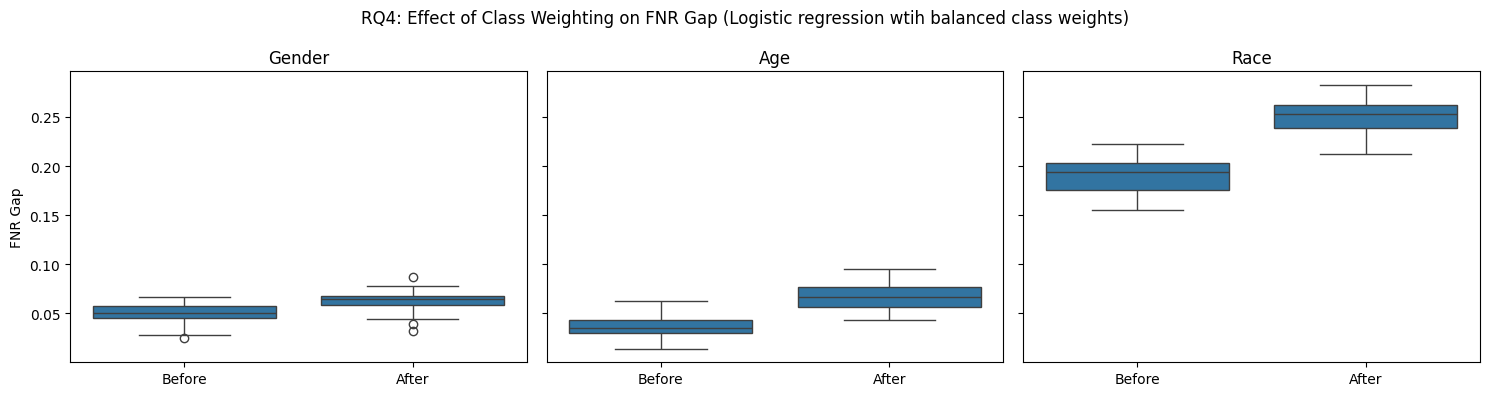

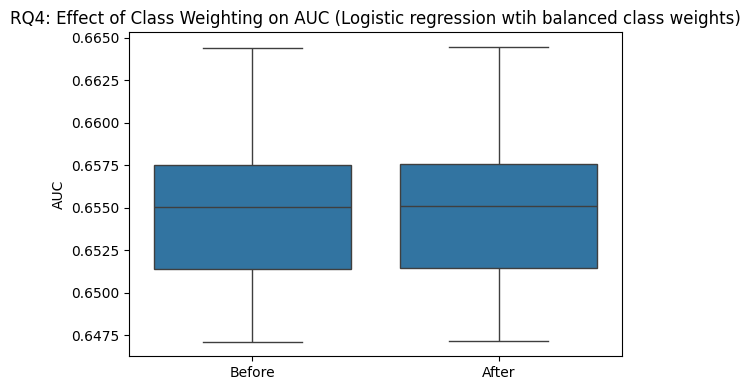

In [ ]:
# Visualize the impact of class-weight mitigation on:
# - demographic FNR gaps across gender, age, and race groups,
# - and overall AUC performance for the Logistic Regression model.

plot_fnr_boxplots(
    rq4_logistic_cw['gaps_before'],
    rq4_logistic_cw['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih balanced class weights)'
)

plot_auc_boxplot(
    rq4_logistic_cw['auc_before'],
    rq4_logistic_cw['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih balanced class weights)'
)

In [ ]:
# Run the RQ4 fairness experiment for Logistic Regression
# by comparing baseline performance against oversample
# mitigation across multiple train-test runs.

rq4_logistic_os = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether oversample
# mitigation significantly changes demographic FNR gaps
# and overall AUC performance for the Logistic Regression model.

run_paired_test(rq4_logistic_os['gaps_before']['gender'], rq4_logistic_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['gaps_before']['age'], rq4_logistic_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['gaps_before']['race'], rq4_logistic_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['auc_before'], rq4_logistic_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 2.3582074148864204e-08
Gender RQ4 Logistic Oversample mean BEFORE: 0.050827823067450394
Gender RQ4 Logistic Oversample mean AFTER : 0.06333947431780583
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 1.2451875994793787e-18
Age RQ4 Logistic Oversample mean BEFORE: 0.035830296865070846
Age RQ4 Logistic Oversample mean AFTER : 0.06519977389711336
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 6.883129155573233e-25
Race RQ4 Logistic Oversample mean BEFORE: 0.19111308884870765
Race RQ4 Logistic Oversample mean AFTER : 0.2535579346830661
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 0.004389946305937191
AUC RQ4 Logistic Oversample mean BEFORE: 0.6550225322042216
AUC RQ4 Logistic Oversample mean AFTER : 0.6548789008247847
AUC R

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(0.004389946305937191),
 'mean_before': np.float64(0.6550225322042216),
 'mean_after': np.float64(0.6548789008247847),
 'valid_runs': 35}

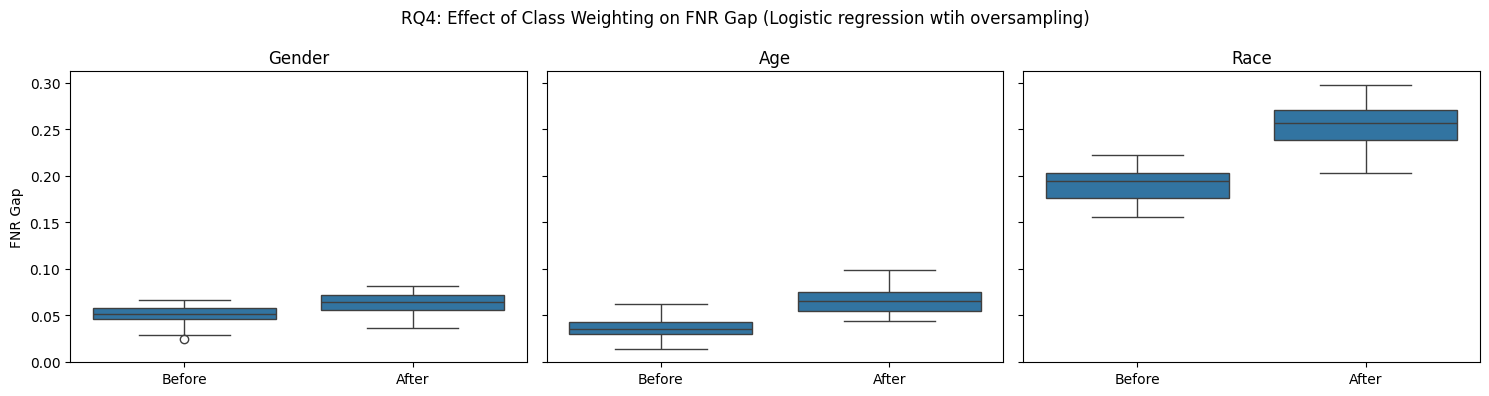

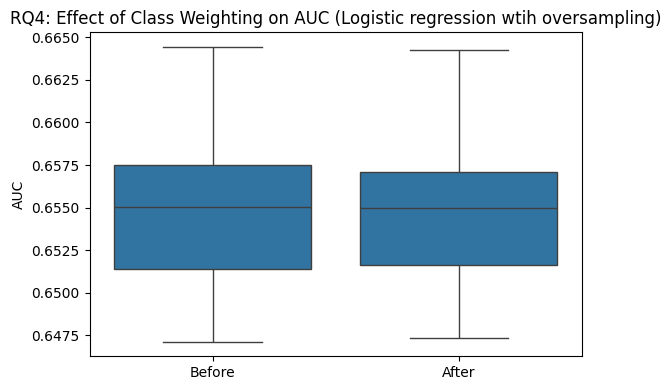

In [ ]:
# Visualize the impact of oversample mitigation on:
# - demographic FNR gaps across gender, age, and race groups,
# - and overall AUC performance for the Logistic Regression model.

plot_fnr_boxplots(
    rq4_logistic_os['gaps_before'],
    rq4_logistic_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_logistic_os['auc_before'],
    rq4_logistic_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [ ]:
# Run the RQ4 fairness experiment for Random Forest
# by comparing baseline performance against class-weight
# mitigation across multiple train-test runs.

rq4_rf_cw = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether class-weight
# mitigation significantly changes demographic FNR gaps
# and overall AUC performance for the Random Forest model.

run_paired_test(rq4_rf_cw['gaps_before']['gender'], rq4_rf_cw['gaps_after']['gender'], "Gender RQ4 Random Forest Class Weight")
run_paired_test(rq4_rf_cw['gaps_before']['age'], rq4_rf_cw['gaps_after']['age'], "Age RQ4 Random Forest Class Weight")
run_paired_test(rq4_rf_cw['gaps_before']['race'], rq4_rf_cw['gaps_after']['race'], "Race RQ4 Random Forest Class Weight")
run_paired_test(rq4_rf_cw['auc_before'], rq4_rf_cw['auc_after'], "AUC RQ4 Random Forest Class Weight")

Gender RQ4 Random Forest Class Weight p-value: 0.5517020577543543
Gender RQ4 Random Forest Class Weight mean BEFORE: 0.04363382754648752
Gender RQ4 Random Forest Class Weight mean AFTER : 0.044269303020514315
Gender RQ4 Random Forest Class Weight valid runs : 35
----------------------------------------
Age RQ4 Random Forest Class Weight p-value: 0.7551801176831483
Age RQ4 Random Forest Class Weight mean BEFORE: 0.010341693881220484
Age RQ4 Random Forest Class Weight mean AFTER : 0.010614120565002591
Age RQ4 Random Forest Class Weight valid runs : 35
----------------------------------------
Race RQ4 Random Forest Class Weight p-value: 0.654269691101198
Race RQ4 Random Forest Class Weight mean BEFORE: 0.1620851606759036
Race RQ4 Random Forest Class Weight mean AFTER : 0.16287629852553007
Race RQ4 Random Forest Class Weight valid runs : 35
----------------------------------------
AUC RQ4 Random Forest Class Weight p-value: 0.23610724334333638
AUC RQ4 Random Forest Class Weight mean BEFORE

{'label': 'AUC RQ4 Random Forest Class Weight',
 'p_value': np.float64(0.23610724334333638),
 'mean_before': np.float64(0.6342660731154968),
 'mean_after': np.float64(0.6344862385719742),
 'valid_runs': 35}

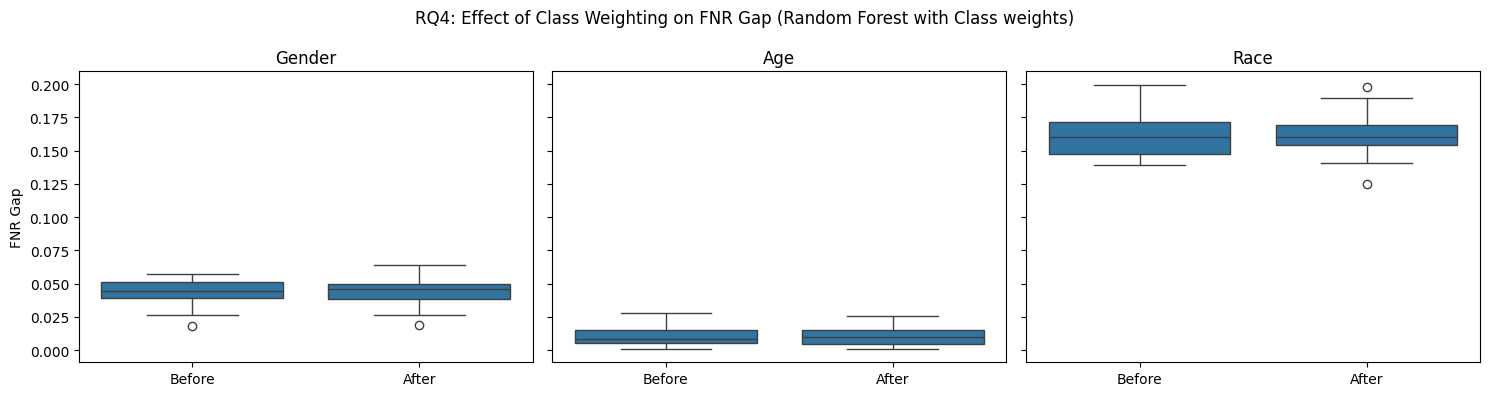

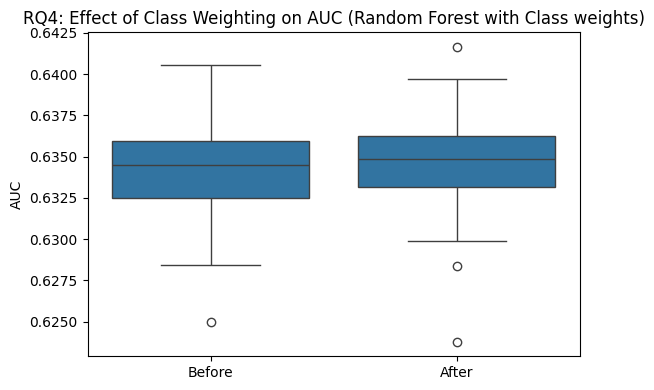

In [ ]:
# Visualize the impact of class-weight mitigation on:
# - demographic FNR gaps across gender, age, and race groups,
# - and overall AUC performance for the Random Forest model.

plot_fnr_boxplots(
    rq4_rf_cw['gaps_before'],
    rq4_rf_cw['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Random Forest with Class weights)'
)

plot_auc_boxplot(
    rq4_rf_cw['auc_before'],
    rq4_rf_cw['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Random Forest with Class weights)'
)

In [ ]:
# Run the RQ4 fairness experiment for Random Forest
# by comparing baseline performance against oversample
# mitigation across multiple train-test runs.

rq4_rf_os = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether oversample
# mitigation significantly changes demographic FNR gaps
# and overall AUC performance for the Random Forest model.

run_paired_test(rq4_rf_os['gaps_before']['gender'], rq4_rf_os['gaps_after']['gender'], "Gender RQ4 Random Forest Oversample")
run_paired_test(rq4_rf_os['gaps_before']['age'], rq4_rf_os['gaps_after']['age'], "Age RQ4 Random Forest Oversample")
run_paired_test(rq4_rf_os['gaps_before']['race'], rq4_rf_os['gaps_after']['race'], "Race RQ4 Random Forest Oversample")
run_paired_test(rq4_rf_os['auc_before'], rq4_rf_os['auc_after'], "AUC RQ4 Random Forest Oversample")

Gender RQ4 Random Forest Oversample p-value: 0.03978175758989073
Gender RQ4 Random Forest Oversample mean BEFORE: 0.04363382754648752
Gender RQ4 Random Forest Oversample mean AFTER : 0.04087701007280603
Gender RQ4 Random Forest Oversample valid runs : 35
----------------------------------------
Age RQ4 Random Forest Oversample p-value: 0.2613353259767722
Age RQ4 Random Forest Oversample mean BEFORE: 0.010341693881220484
Age RQ4 Random Forest Oversample mean AFTER : 0.00834755042257449
Age RQ4 Random Forest Oversample valid runs : 35
----------------------------------------
Race RQ4 Random Forest Oversample p-value: 1.0758878477082317e-08
Race RQ4 Random Forest Oversample mean BEFORE: 0.1620851606759036
Race RQ4 Random Forest Oversample mean AFTER : 0.1412314601833161
Race RQ4 Random Forest Oversample valid runs : 35
----------------------------------------
AUC RQ4 Random Forest Oversample p-value: 4.447410339267888e-14
AUC RQ4 Random Forest Oversample mean BEFORE: 0.6342660686745307
AU

{'label': 'AUC RQ4 Random Forest Oversample',
 'p_value': np.float64(4.447410339267888e-14),
 'mean_before': np.float64(0.6342660686745307),
 'mean_after': np.float64(0.631071179492232),
 'valid_runs': 35}

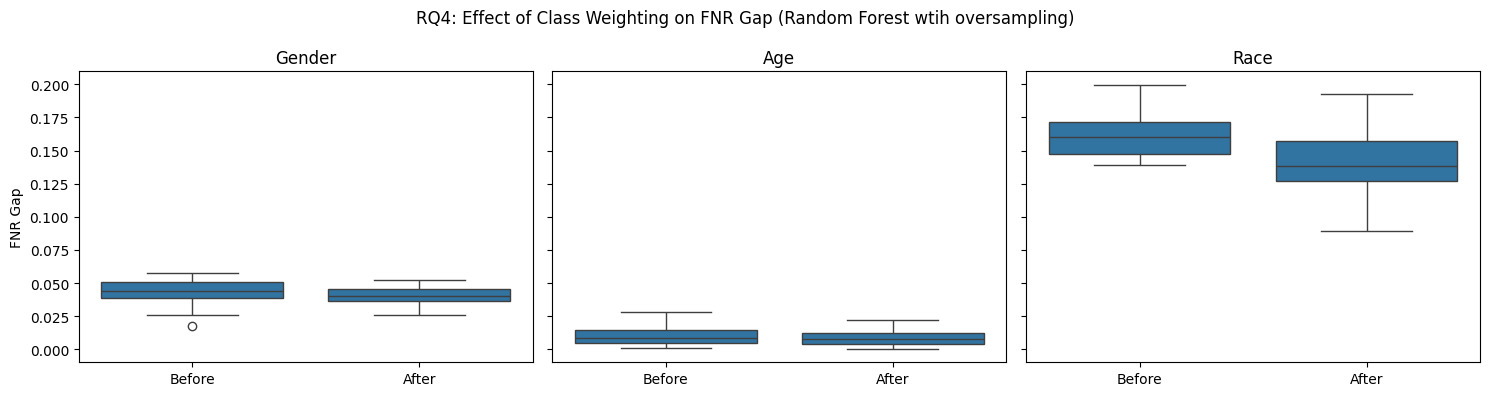

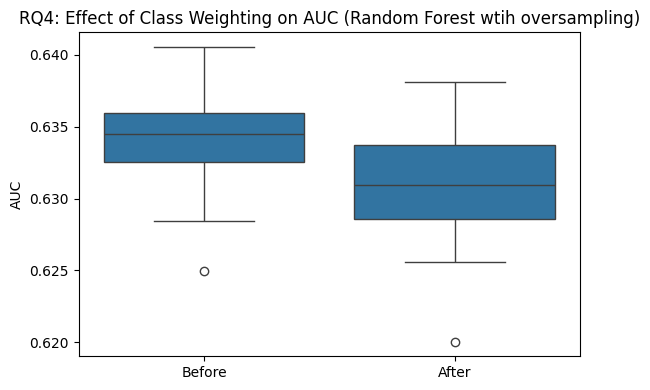

In [ ]:
# Visualize the impact of oversample mitigation on:
# - demographic FNR gaps across gender, age, and race groups,
# - and overall AUC performance for the Random Forest model.

plot_fnr_boxplots(
    rq4_rf_os['gaps_before'],
    rq4_rf_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Random Forest wtih oversampling)'
)

plot_auc_boxplot(
    rq4_rf_os['auc_before'],
    rq4_rf_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Random Forest wtih oversampling)'
)

In [ ]:
# Run the RQ4 fairness experiment for Gradient Boost
# by comparing baseline performance against oversample
# mitigation across multiple train-test runs.

rq4_gb_os = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='gradient_boosting',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
# Perform paired t-tests to evaluate whether oversample
# mitigation significantly changes demographic FNR gaps
# and overall AUC performance for the Gardient Boost model.

run_paired_test(rq4_gb_os['gaps_before']['gender'], rq4_gb_os['gaps_after']['gender'], "Gender RQ4 Gradient Boosting Oversample")
run_paired_test(rq4_gb_os['gaps_before']['age'], rq4_gb_os['gaps_after']['age'], "Age RQ4 Gradient Boosting Oversample")
run_paired_test(rq4_gb_os['gaps_before']['race'], rq4_gb_os['gaps_after']['race'], "Race RQ4 Gradient Boosting Oversample")
run_paired_test(rq4_gb_os['auc_before'], rq4_gb_os['auc_after'], "AUC RQ4 Gradient Boosting Oversample")

Gender RQ4 Gradient Boosting Oversample p-value: 0.0003541036813540629
Gender RQ4 Gradient Boosting Oversample mean BEFORE: 0.03514244132629089
Gender RQ4 Gradient Boosting Oversample mean AFTER : 0.04090731741948208
Gender RQ4 Gradient Boosting Oversample valid runs : 35
----------------------------------------
Age RQ4 Gradient Boosting Oversample p-value: 3.8243625189091434e-09
Age RQ4 Gradient Boosting Oversample mean BEFORE: 0.007429924235075516
Age RQ4 Gradient Boosting Oversample mean AFTER : 0.02416004188339782
Age RQ4 Gradient Boosting Oversample valid runs : 35
----------------------------------------
Race RQ4 Gradient Boosting Oversample p-value: 2.688522550263838e-06
Race RQ4 Gradient Boosting Oversample mean BEFORE: 0.16151145113435816
Race RQ4 Gradient Boosting Oversample mean AFTER : 0.1767354449369953
Race RQ4 Gradient Boosting Oversample valid runs : 35
----------------------------------------
AUC RQ4 Gradient Boosting Oversample p-value: 0.0007129295247649185
AUC RQ4 G

{'label': 'AUC RQ4 Gradient Boosting Oversample',
 'p_value': np.float64(0.0007129295247649185),
 'mean_before': np.float64(0.6648771947861603),
 'mean_after': np.float64(0.6644423828833823),
 'valid_runs': 35}

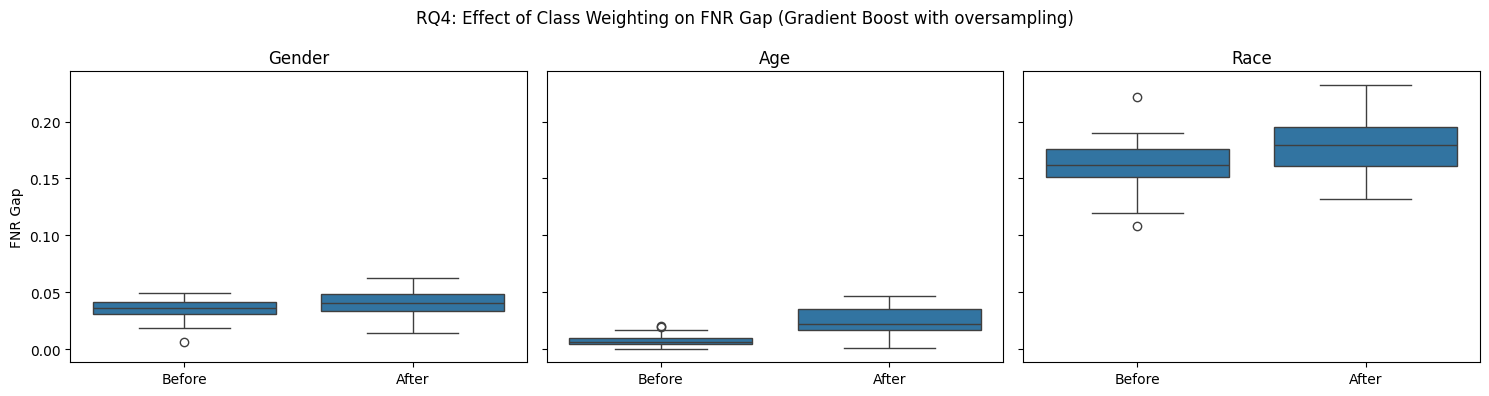

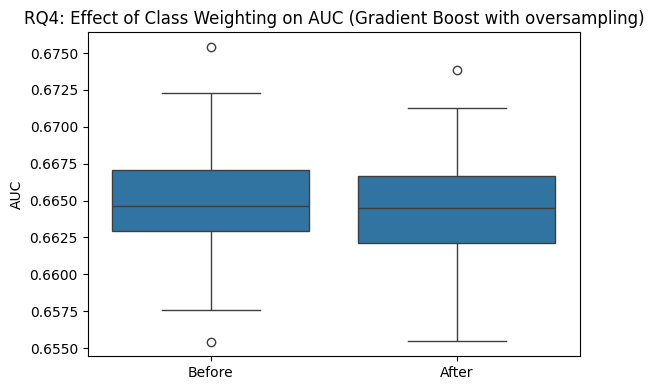

In [ ]:
# Visualize the impact of oversample mitigation on:
# - demographic FNR gaps across gender, age, and race groups,
# - and overall AUC performance for the Gradient Boost model.

plot_fnr_boxplots(
    rq4_gb_os['gaps_before'],
    rq4_gb_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Gradient Boost with oversampling)'
)

plot_auc_boxplot(
    rq4_gb_os['auc_before'],
    rq4_gb_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Gradient Boost with oversampling)'
)

In [ ]:
# Combine RQ4 experiment summaries for all models and
# mitigation strategies into a single dataframe to compare
# fairness and performance outcomes across experiments.

summary_rq4 = pd.concat([
    summarize_experiment(rq4_logistic_cw, "Logistic_RQ4 with class weights"),
    summarize_experiment(rq4_logistic_os, "Logistic_RQ4 with oversampling"),
    summarize_experiment(rq4_rf_cw, "RandomForest_RQ4 with class weights"),
    summarize_experiment(rq4_rf_os, "RandomForest_RQ4 with oversampling"),
    summarize_experiment(rq4_gb_os, "GradientBoost_RQ4 with oversampling")
], ignore_index=True)

summary_rq4

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Gender,0.05083,0.06264,0.01181,0.00000,35
1,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Age,0.03583,0.06601,0.03018,0.00000,35
2,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Race,0.19111,0.25124,0.06012,0.00000,35
3,Logistic_RQ4 with class weights,logistic,class_weight,AUC,Overall,0.65502,0.65511,0.00008,0.00000,35
4,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Gender,0.05083,0.06334,0.01251,0.00000,35
5,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Age,0.03583,0.06520,0.02937,0.00000,35
6,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Race,0.19111,0.25356,0.06244,0.00000,35
7,Logistic_RQ4 with oversampling,logistic,oversample,AUC,Overall,0.65502,0.65488,-0.00014,0.00439,35
8,RandomForest_RQ4 with class weights,random_forest,class_weight,FNR Gap,Gender,0.04363,0.04427,0.00064,0.55170,35
9,RandomForest_RQ4 with class weights,random_forest,class_weight,FNR Gap,Age,0.01034,0.01061,0.00027,0.75518,35


In [ ]:
# Prepare RQ4 fairness results for visualization by:
# - filtering FNR Gap metrics,
# - creating readable experiment labels,
# - reshaping before/after mitigation values into long format,
# - and simplifying condition labels for plotting.

# Keep only the FNR gaps
rq4_plot_df = summary_rq4[
    summary_rq4['Metric'] == 'FNR Gap'
].copy()

# Create cleaner experiment labels
rq4_plot_df['Experiment_Label'] = (
    rq4_plot_df['Model']
    + '\n('
    + rq4_plot_df['Mitigation']
    + ')'
)

# reshape before/after values into long format
rq4_plot_df = rq4_plot_df.melt(
    id_vars=['Experiment_Label', 'Group'],
    value_vars=['Mean Before', 'Mean After'],
    var_name='Condition',
    value_name='FNR Gap'
)

# Clean labels
rq4_plot_df['Condition'] = rq4_plot_df['Condition'].replace({
    'Mean Before': 'Before Mitigation',
    'Mean After': 'After Mitigation'
})

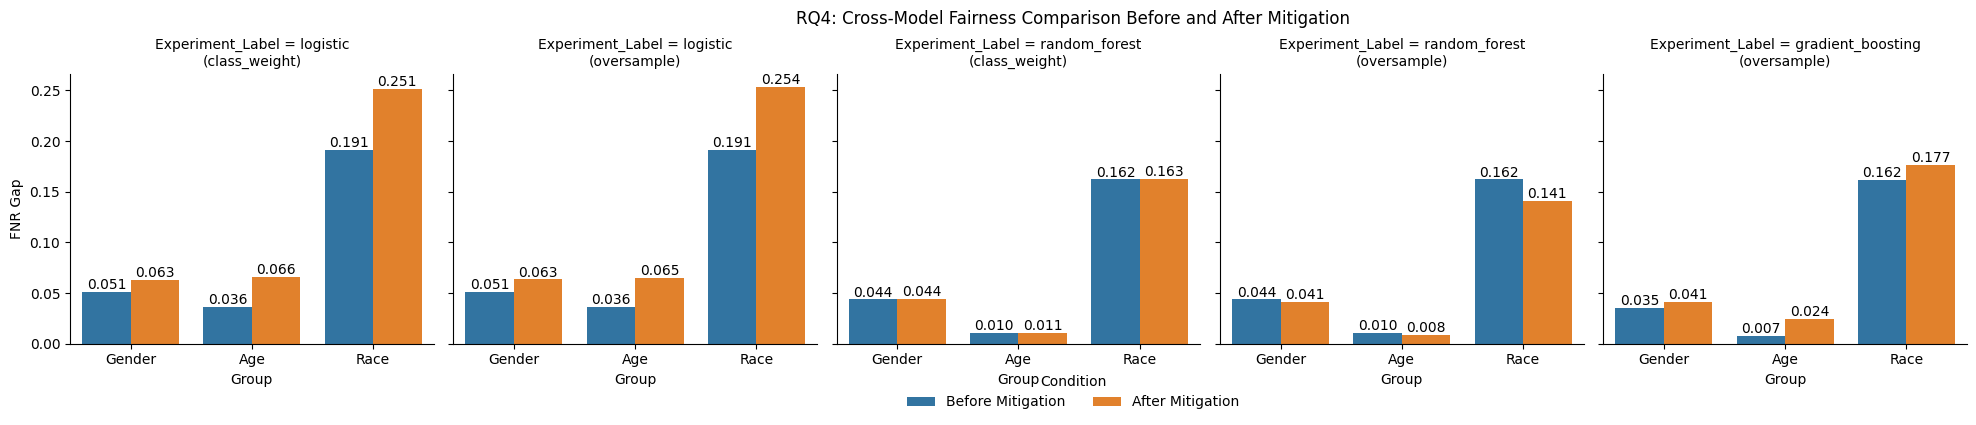

In [ ]:
# Create grouped bar charts to compare demographic FNR gaps
# before and after mitigation across models and mitigation
# strategies, with separate panels for each experiment and
# labeled bars for easier interpretation.

# Visualize the plot
g = sns.catplot(
    data=rq4_plot_df,
    x='Group',
    y='FNR Gap',
    hue='Condition',
    col='Experiment_Label',
    kind='bar',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.82)

g.fig.suptitle(
    'RQ4: Cross-Model Fairness Comparison Before and After Mitigation'
)

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

# Optional value labels
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

plt.show()

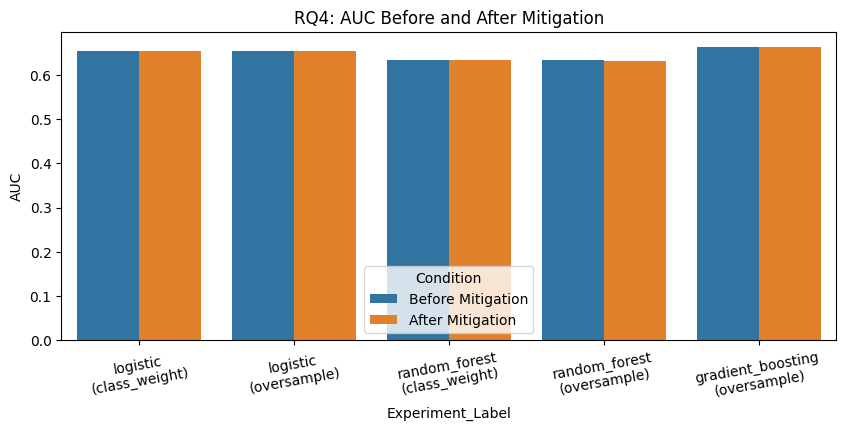

In [ ]:
# Prepare and visualize AUC performance comparisons before
# and after mitigation across models and mitigation strategies
# using grouped bar charts.

rq4_auc_df = summary_rq4[
    summary_rq4['Metric'] == 'AUC'
].copy()

rq4_auc_df['Experiment_Label'] = (
    rq4_auc_df['Model']
    + '\n('
    + rq4_auc_df['Mitigation']
    + ')'
)

rq4_auc_df = rq4_auc_df.melt(
    id_vars=['Experiment_Label'],
    value_vars=['Mean Before', 'Mean After'],
    var_name='Condition',
    value_name='AUC'
)

rq4_auc_df['Condition'] = rq4_auc_df['Condition'].replace({
    'Mean Before': 'Before Mitigation',
    'Mean After': 'After Mitigation'
})

plt.figure(figsize=(10,4))

sns.barplot(
    data=rq4_auc_df,
    x='Experiment_Label',
    y='AUC',
    hue='Condition'
)

plt.title('RQ4: AUC Before and After Mitigation')

plt.xticks(rotation=10)

plt.show()

**Robustness checks after treating outliers**

In [ ]:
# Run RQ4 fairness experiments for Logistic Regression
# across different preprocessing approaches:
# - original dataset
# - log-transformed dataset
# - 99% capped dataset
#
# Each experiment evaluates the impact of class-weight
# mitigation on demographic fairness over multiple runs.

# 1. Run RQ4 - ORIGINAL DATA
rq4_logistic_original = run_experiment(
    X_original=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)


# 2. Run RQ4 - LOG TRANSFORM
rq4_logistic_log = run_experiment(
    X_original=X_log,
    y=y,
    source_df=DiabData_log,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)


# 3. Run RQ4 - 99% CAPPING
rq4_logistic_cap = run_experiment(
    X_original=X_cap,
    y=y,
    source_df=DiabData_cap,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [ ]:
# Combine and summarize RQ4 Logistic Regression experiments
# across different preprocessing approaches, retain fairness
# and performance metrics (FNR Gap and AUC), and round
# statistical results for readability.

summary_rq4_logistic_outlier = pd.concat([

    summarize_experiment(
        rq4_logistic_original,
        "Original"
    ),

    summarize_experiment(
        rq4_logistic_log,
        "Log Transform"
    ),

    summarize_experiment(
        rq4_logistic_cap,
        "99% Capping"
    )

], ignore_index=True)

# Keep only FNR Gap + AUC
summary_rq4_logistic_outlier = summary_rq4_logistic_outlier[
    summary_rq4_logistic_outlier['Metric'].isin(['FNR Gap', 'AUC'])
].copy()

# Round values
for col in [
    'Mean Before',
    'Mean After',
    'Delta (After-Before)',
    'p-value'
]:
    summary_rq4_logistic_outlier[col] = (
        summary_rq4_logistic_outlier[col]
        .round(6)
    )

summary_rq4_logistic_outlier

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Original,logistic,class_weight,FNR Gap,Gender,0.05083,0.06263,0.01181,0.00000,35
1,Original,logistic,class_weight,FNR Gap,Age,0.03583,0.06601,0.03018,0.00000,35
2,Original,logistic,class_weight,FNR Gap,Race,0.19111,0.25123,0.06012,0.00000,35
3,Original,logistic,class_weight,AUC,Overall,0.65502,0.65511,0.00008,0.00000,35
4,Log Transform,logistic,class_weight,FNR Gap,Gender,0.04034,0.04938,0.00904,0.00000,35
5,Log Transform,logistic,class_weight,FNR Gap,Age,0.01638,0.03312,0.01675,0.00000,35
6,Log Transform,logistic,class_weight,FNR Gap,Race,0.18455,0.20469,0.02014,0.00000,35
7,Log Transform,logistic,class_weight,AUC,Overall,0.65720,0.65724,0.00004,0.00001,35
8,99% Capping,logistic,class_weight,FNR Gap,Gender,0.04842,0.05959,0.01117,0.00000,35
9,99% Capping,logistic,class_weight,FNR Gap,Age,0.02904,0.05795,0.02891,0.00000,35


In [ ]:
# Define and execute paired t-tests to evaluate whether
# class-weight mitigation significantly changes demographic
# FNR gaps and AUC performance for Logistic Regression
# across different preprocessing approaches.

def print_rq4_logistic_outlier_tests(result_obj, label):

    print("\n" + "=" * 70)
    print(f"RQ4 Logistic Regression - {label}")
    print("=" * 70)

    # Gender
    run_paired_test(
        result_obj['gaps_before']['gender'],
        result_obj['gaps_after']['gender'],
        f"Gender RQ4 Logistic - {label}"
    )

    # Age
    run_paired_test(
        result_obj['gaps_before']['age'],
        result_obj['gaps_after']['age'],
        f"Age RQ4 Logistic - {label}"
    )

    # Race
    run_paired_test(
        result_obj['gaps_before']['race'],
        result_obj['gaps_after']['race'],
        f"Race RQ4 Logistic - {label}"
    )

    # AUC
    run_paired_test(
        result_obj['auc_before'],
        result_obj['auc_after'],
        f"AUC RQ4 Logistic - {label}"
    )


print_rq4_logistic_outlier_tests(
    rq4_logistic_original,
    "Original"
)

print_rq4_logistic_outlier_tests(
    rq4_logistic_log,
    "Log Transform"
)

print_rq4_logistic_outlier_tests(
    rq4_logistic_cap,
    "99% Capping"
)


RQ4 Logistic Regression - Original
Gender RQ4 Logistic - Original p-value: 1.4189889251979555e-11
Gender RQ4 Logistic - Original mean BEFORE: 0.050827823067450394
Gender RQ4 Logistic - Original mean AFTER : 0.06263546786736343
Gender RQ4 Logistic - Original valid runs : 35
----------------------------------------
Age RQ4 Logistic - Original p-value: 3.2716581148953527e-25
Age RQ4 Logistic - Original mean BEFORE: 0.035830296865070846
Age RQ4 Logistic - Original mean AFTER : 0.06600661106311322
Age RQ4 Logistic - Original valid runs : 35
----------------------------------------
Race RQ4 Logistic - Original p-value: 2.8926944549365894e-30
Race RQ4 Logistic - Original mean BEFORE: 0.19111308884870765
Race RQ4 Logistic - Original mean AFTER : 0.2512353489237745
Race RQ4 Logistic - Original valid runs : 35
----------------------------------------
AUC RQ4 Logistic - Original p-value: 1.328561991401619e-10
AUC RQ4 Logistic - Original mean BEFORE: 0.6550225322042216
AUC RQ4 Logistic - Original

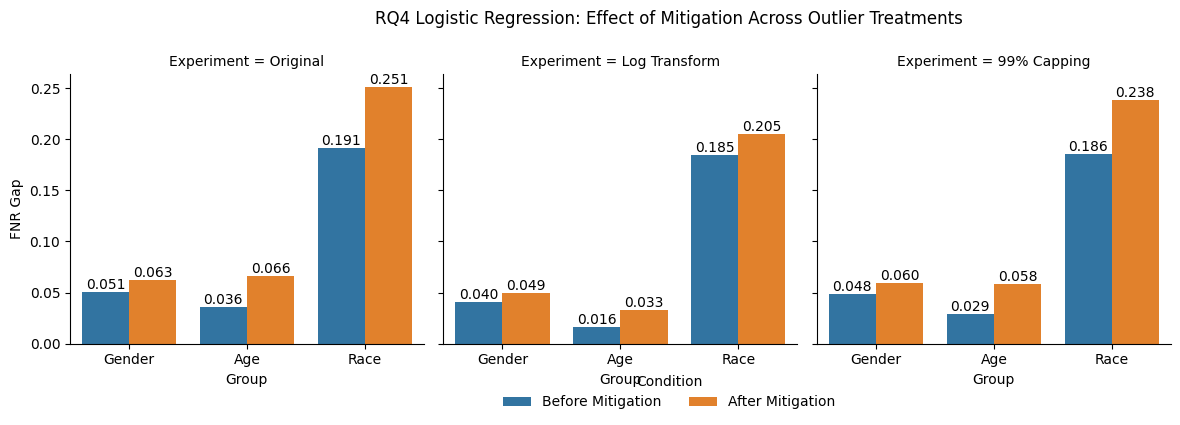

In [ ]:
# Prepare and visualize RQ4 Logistic Regression fairness
# results by comparing demographic FNR gaps before and after
# mitigation across different outlier treatment approaches.


# Keep only FNR Gap rows
rq4_plot_df = summary_rq4_logistic_outlier[
    summary_rq4_logistic_outlier['Metric'] == 'FNR Gap'
].copy()


# Reshape to long format
rq4_plot_df = rq4_plot_df.melt(
    id_vars=['Experiment', 'Group'],
    value_vars=['Mean Before', 'Mean After'],
    var_name='Condition',
    value_name='FNR Gap'
)


# Clean labels
rq4_plot_df['Condition'] = rq4_plot_df['Condition'].replace({
    'Mean Before': 'Before Mitigation',
    'Mean After': 'After Mitigation'
})


# Plot
g = sns.catplot(
    data=rq4_plot_df,
    x='Group',
    y='FNR Gap',
    hue='Condition',
    col='Experiment',
    kind='bar',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.82)

g.fig.suptitle(
    'RQ4 Logistic Regression: Effect of Mitigation Across Outlier Treatments'
)

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

# Value labels
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

plt.show()

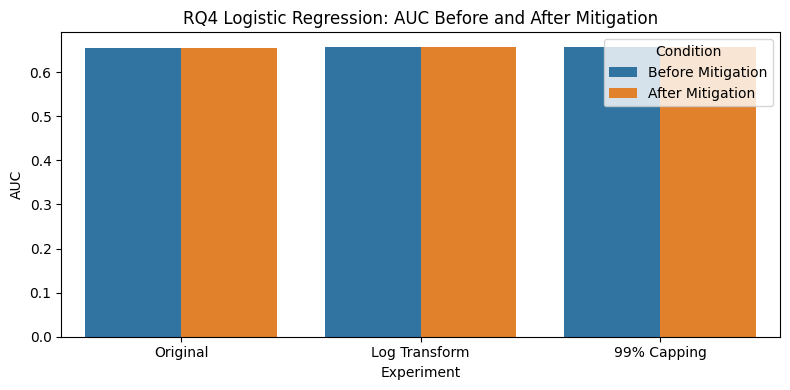

In [ ]:
# Prepare and visualize AUC performance comparisons before
# and after mitigation for Logistic Regression across
# different outlier treatment approaches using grouped bar charts.

rq4_auc_df = summary_rq4_logistic_outlier[
    summary_rq4_logistic_outlier['Metric'] == 'AUC'
].copy()

rq4_auc_df = rq4_auc_df.melt(
    id_vars=['Experiment'],
    value_vars=['Mean Before', 'Mean After'],
    var_name='Condition',
    value_name='AUC'
)

rq4_auc_df['Condition'] = rq4_auc_df['Condition'].replace({
    'Mean Before': 'Before Mitigation',
    'Mean After': 'After Mitigation'
})

plt.figure(figsize=(8,4))

sns.barplot(
    data=rq4_auc_df,
    x='Experiment',
    y='AUC',
    hue='Condition'
)

plt.title(
    'RQ4 Logistic Regression: AUC Before and After Mitigation'
)

plt.tight_layout()

plt.show()

**Observations and Insights:**
The robustness analysis demonstrates that the fairness impact of mitigation strategies in Logistic Regression persists across alternative outlier treatment approaches. Across original, log-transformed, and 99th percentile capped datasets, class-weight mitigation consistently increased false negative rate disparities across gender, age, and race groups while leaving overall predictive performance largely unchanged. Although log transformation reduced the magnitude of disparity increases compared to the original data, fairness deterioration remained statistically significant in all cases. These findings indicate that the observed fairness degradation is not driven solely by extreme values or skewed utilization distributions, but reflects broader interactions between mitigation strategies, feature relationships, and model behavior.Mitigation changed who the model fails on, not how well the model performs overall.

# Research question #5 : Threshold Sensitivity and Fairness Trade-off

In [ ]:
from scipy.stats import friedmanchisquare

# =============================================================================
# This function computes the False Negative Rate (FNR) gap across
# demographic subgroups based on model predictions.
#
# Input:
# - results_df: DataFrame containing:
#     • actual labels
#     • predicted labels
#     • demographic subgroup columns
#
# - group_col: Name of the demographic column to analyze
#     (e.g., gender, age_group, race_group).
#
# - pred_col: Name of the prediction column. Default = 'predicted'.
#
# Returns:
# - FNR gap value across demographic subgroups.
# - Returns NaN if fewer than two valid subgroup FNR values exist.
# =============================================================================

def compute_fnr_gap_from_predictions(results_df, group_col, pred_col='predicted'):
    pos = results_df[results_df['actual'] == 1].copy()

    fnr = pos.groupby(group_col)[pred_col].apply(lambda x: (x == 0).mean())
    fnr = fnr.dropna()

    if len(fnr) < 2:
        return np.nan

    return fnr.max() - fnr.min()

# =============================================================================
# This function computes fairness and performance metrics for a given
# prediction probability threshold.
#
# Input:
# - y_test:True target labels.
#
# - y_prob: Predicted probabilities from the model.
#
# - demographics: DataFrame containing demographic subgroup columns
#     (e.g., gender, age_group, race_group).
#
# - threshold: Decision threshold used to convert probabilities
#     into binary predictions.
#
#
# Returns:
# - Dictionary containing threshold-based fairness and performance metrics.
# =============================================================================

def compute_threshold_metrics(y_test, y_prob, demographics, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    results = demographics.copy()
    results['actual'] = y_test.values
    results['predicted'] = y_pred

    return {
        'Threshold': threshold,
        'Gender FNR Gap': compute_fnr_gap_from_predictions(results, 'gender'),
        'Age FNR Gap': compute_fnr_gap_from_predictions(results, 'age_group'),
        'Race FNR Gap': compute_fnr_gap_from_predictions(results, 'race_group'),
        'Overall Recall': recall_score(y_test, y_pred),
        'Overall Precision': precision_score(y_test, y_pred, zero_division=0),
        'Overall F1': f1_score(y_test, y_pred),
        'Overall FNR': 1 - recall_score(y_test, y_pred)
    }

In [ ]:
# =============================================================================
# This function runs RQ5 threshold sensitivity analysis for a single model
# across multiple decision thresholds and repeated train-test runs.
#
# Input:
# - X_original: Feature dataset used for model training and evaluation.
#
# - y: Target labels.
#
# - source_df: Original dataframe containing demographic subgroup columns.
#
# - numeric_cols: List of numeric feature columns to standardize.
#
# - model_name: Name of the model to evaluate.
#     Default = 'logistic'.
#
# - thresholds: List of decision thresholds to test.
#
# - n_runs: Number of repeated train-test experiments.
#
# Returns: DataFrame containing:
#     • run number
#     • model name
#     • threshold values
#     • fairness metrics
#     • performance metrics
#     • AUC scores
# =============================================================================

def run_rq5_threshold_analysis(
    X_original,
    y,
    source_df,
    numeric_cols,
    model_name='logistic',
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    n_runs=35
):
    rows = []

    for i in range(n_runs):

        X_train, X_test, y_train, y_test, demographics = prepare_split(
            X_original,
            y,
            source_df,
            numeric_cols,
            random_state=i
        )

        model = make_model(
            model_name=model_name,
            mitigation='none',
            random_state=i
        )

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        auc_value = roc_auc_score(y_test, y_prob)

        for threshold in thresholds:
            metrics = compute_threshold_metrics(
                y_test=y_test,
                y_prob=y_prob,
                demographics=demographics,
                threshold=threshold
            )

            metrics['Run'] = i
            metrics['Model'] = model_name
            metrics['AUC'] = auc_value

            rows.append(metrics)

    return pd.DataFrame(rows)

In [ ]:
# =============================================================================
# This function runs RQ5 threshold sensitivity analysis across multiple
# machine learning models and combines all experimental results.
#
# Input:
# - X_data: Feature dataset used for model training and evaluation.
#
# - y: Target labels.
#
# - source_df: Original dataframe containing demographic subgroup columns.
#
# - numeric_cols: List of numeric feature columns to standardize.
#
# - model_list: List of models to evaluate.
#     • logistic
#     • random_forest
#     • gradient_boosting
#
# - thresholds: List of decision thresholds to evaluate.
#
# - n_runs: Number of repeated train-test experiments.
#
# Returns:
# - DataFrame containing combined RQ5 experimental results
#   across all models, thresholds, and runs.
# =============================================================================

def run_rq5_all_models(
    X_data,
    y,
    source_df,
    numeric_cols,
    model_list=['logistic', 'random_forest', 'gradient_boosting'],
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    n_runs=35
):
    all_results = []

    for model_name in model_list:
        print(f"Running RQ5 for: {model_name}")

        model_results = run_rq5_threshold_analysis(
            X_original=X_data,
            y=y,
            source_df=source_df,
            numeric_cols=numeric_cols,
            model_name=model_name,
            thresholds=thresholds,
            n_runs=n_runs
        )

        all_results.append(model_results)

    return pd.concat(all_results, ignore_index=True)

In [ ]:
# Run the RQ5 threshold analysis across multiple models and
# decision thresholds to evaluate fairness and performance
# metrics over repeated train-test experiments.

rq5_results_all = run_rq5_all_models(
    X_data=X_original,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_list=['logistic', 'random_forest', 'gradient_boosting'],
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7],
    n_runs=35
)

rq5_results_all.head()

Running RQ5 for: logistic
Running RQ5 for: random_forest
Running RQ5 for: gradient_boosting


,Threshold,Gender FNR Gap,Age FNR Gap,Race FNR Gap,Overall Recall,Overall Precision,Overall F1,Overall FNR,Run,Model,AUC
0,0.30000,0.01012,0.02652,0.15502,0.97271,0.47410,0.63749,0.02729,0,logistic,0.65780
1,0.40000,0.04718,0.07392,0.36690,0.74182,0.53733,0.62323,0.25818,0,logistic,0.65780
2,0.50000,0.03984,0.03304,0.16674,0.40038,0.64381,0.49372,0.59962,0,logistic,0.65780
3,0.60000,0.02708,0.00075,0.07886,0.21011,0.71829,0.32511,0.78989,0,logistic,0.65780
4,0.70000,0.01471,0.01360,0.04057,0.11225,0.76582,0.19580,0.88775,0,logistic,0.65780


In [ ]:
# Compute average fairness and performance metrics across
# runs for each model and decision threshold to summarize
# RQ5 experimental results.

rq5_summary_all = rq5_results_all.groupby(['Model', 'Threshold']).agg({
    'Gender FNR Gap': 'mean',
    'Age FNR Gap': 'mean',
    'Race FNR Gap': 'mean',
    'Overall Recall': 'mean',
    'Overall Precision': 'mean',
    'Overall F1': 'mean',
    'Overall FNR': 'mean',
    'AUC': 'mean'
}).reset_index()

rq5_summary_all.round(5)

,Model,Threshold,Gender FNR Gap,Age FNR Gap,Race FNR Gap,Overall Recall,Overall Precision,Overall F1,Overall FNR,AUC
0,gradient_boosting,0.30000,0.01356,0.03280,0.14342,0.94363,0.48741,0.64279,0.05637,0.66488
1,gradient_boosting,0.40000,0.03680,0.05340,0.24623,0.74260,0.54556,0.62900,0.25740,0.66488
2,gradient_boosting,0.50000,0.03514,0.00743,0.16151,0.46688,0.62314,0.53380,0.53312,0.66488
3,gradient_boosting,0.60000,0.02191,0.01544,0.08909,0.26195,0.69620,0.38064,0.73805,0.66488
4,gradient_boosting,0.70000,0.01490,0.02295,0.03968,0.10682,0.78122,0.18792,0.89318,0.66488
5,logistic,0.30000,0.01289,0.02335,0.15546,0.97152,0.47472,0.63779,0.02848,0.65502
6,logistic,0.40000,0.06061,0.08024,0.35038,0.74042,0.53835,0.62341,0.25958,0.65502
7,logistic,0.50000,0.05083,0.03583,0.19111,0.39508,0.63611,0.48741,0.60492,0.65502
8,logistic,0.60000,0.02746,0.00629,0.10392,0.20663,0.70710,0.31978,0.79337,0.65502
9,logistic,0.70000,0.01639,0.01459,0.05892,0.10764,0.75982,0.18855,0.89236,0.65502


In [ ]:
# =============================================================================
# This function performs a Friedman test to evaluate whether metric
# values differ significantly across decision thresholds for each model.
#
# Input:
# - df: DataFrame containing experimental results across:
#     • models
#     • thresholds
#     • runs
#     • evaluation metrics
#
# - metric: Name of the metric to analyze
#     (e.g., FNR Gap, Recall, Overall FNR).
#
# Returns: DataFrame containing:
#     • model name
#     • metric name
#     • Friedman test statistic
#     • p-value indicating whether threshold changes
#       significantly affect the metric
# =============================================================================

def friedman_threshold_test_by_model(df, metric):
    rows = []

    for model_name, model_df in df.groupby('Model'):
        pivot = model_df.pivot(
            index='Run',
            columns='Threshold',
            values=metric
        )

        pivot = pivot.dropna()

        stat, p_value = friedmanchisquare(
            *[pivot[col].values for col in pivot.columns]
        )

        rows.append({
            'Model': model_name,
            'Metric': metric,
            'Friedman Statistic': stat,
            'p-value': p_value
        })

    return pd.DataFrame(rows)

In [ ]:
# Perform Friedman statistical tests to evaluate whether
# changing decision thresholds significantly affects fairness
# and performance metrics across models.

rq5_friedman_results = pd.concat([
    friedman_threshold_test_by_model(rq5_results_all, 'Gender FNR Gap'),
    friedman_threshold_test_by_model(rq5_results_all, 'Age FNR Gap'),
    friedman_threshold_test_by_model(rq5_results_all, 'Race FNR Gap'),
    friedman_threshold_test_by_model(rq5_results_all, 'Overall Recall'),
    friedman_threshold_test_by_model(rq5_results_all, 'Overall FNR')
], ignore_index=True)

rq5_friedman_results.round(6)

,Model,Metric,Friedman Statistic,p-value
0,gradient_boosting,Gender FNR Gap,98.10286,0.00000
1,logistic,Gender FNR Gap,128.75429,0.00000
2,random_forest,Gender FNR Gap,109.07429,0.00000
3,gradient_boosting,Age FNR Gap,123.97714,0.00000
4,logistic,Age FNR Gap,125.78286,0.00000
5,random_forest,Age FNR Gap,63.61143,0.00000
6,gradient_boosting,Race FNR Gap,134.10286,0.00000
7,logistic,Race FNR Gap,137.80571,0.00000
8,random_forest,Race FNR Gap,125.66857,0.00000
9,gradient_boosting,Overall Recall,140.00000,0.00000


In [ ]:
# ==============================================================================
# This function performs paired t-tests to compare metric values
# between a baseline decision threshold and alternative thresholds
# for each model.
#
# Input:
# - df: DataFrame containing experimental results across:
#     • models
#     • thresholds
#     • runs
#     • evaluation metrics
#
# - metric: Name of the metric to analyze
#     (e.g., FNR Gap, Recall, Overall FNR).
#
# - baseline_threshold: Threshold value used as the reference for comparison.
#     Default = 0.5.
#
#
# Returns: DataFrame containing:
#     • model name
#     • metric name
#     • baseline and comparison thresholds
#     • mean metric values
#     • delta between thresholds
#     • paired t-test p-values
# ==============================================================================

def paired_threshold_tests_by_model(df, metric, baseline_threshold=0.5):
    rows = []

    for model_name, model_df in df.groupby('Model'):

        pivot = model_df.pivot(
            index='Run',
            columns='Threshold',
            values=metric
        )

        pivot = pivot.dropna()

        baseline = pivot[baseline_threshold]

        for threshold in pivot.columns:
            if threshold == baseline_threshold:
                continue

            stat, p_value = ttest_rel(baseline, pivot[threshold])

            rows.append({
                'Model': model_name,
                'Metric': metric,
                'Baseline Threshold': baseline_threshold,
                'Comparison Threshold': threshold,
                'Baseline Mean': baseline.mean(),
                'Comparison Mean': pivot[threshold].mean(),
                'Delta': pivot[threshold].mean() - baseline.mean(),
                'p-value': p_value
            })

    return pd.DataFrame(rows)

In [ ]:
# Perform paired statistical tests to compare fairness and
# performance metrics between decision thresholds across models.

rq5_tests_all = pd.concat([
    paired_threshold_tests_by_model(rq5_results_all, 'Gender FNR Gap'),
    paired_threshold_tests_by_model(rq5_results_all, 'Age FNR Gap'),
    paired_threshold_tests_by_model(rq5_results_all, 'Race FNR Gap'),
    paired_threshold_tests_by_model(rq5_results_all, 'Overall Recall'),
    paired_threshold_tests_by_model(rq5_results_all, 'Overall FNR')
], ignore_index=True)

rq5_tests_all.round(6)

,Model,Metric,Baseline Threshold,Comparison Threshold,Baseline Mean,Comparison Mean,Delta,p-value
0,gradient_boosting,Gender FNR Gap,0.50000,0.30000,0.03514,0.01356,-0.02159,0.00000
1,gradient_boosting,Gender FNR Gap,0.50000,0.40000,0.03514,0.03680,0.00166,0.36639
2,gradient_boosting,Gender FNR Gap,0.50000,0.60000,0.03514,0.02191,-0.01323,0.00000
3,gradient_boosting,Gender FNR Gap,0.50000,0.70000,0.03514,0.01490,-0.02024,0.00000
4,logistic,Gender FNR Gap,0.50000,0.30000,0.05083,0.01289,-0.03794,0.00000
5,logistic,Gender FNR Gap,0.50000,0.40000,0.05083,0.06061,0.00978,0.00000
6,logistic,Gender FNR Gap,0.50000,0.60000,0.05083,0.02746,-0.02337,0.00000
7,logistic,Gender FNR Gap,0.50000,0.70000,0.05083,0.01639,-0.03444,0.00000
8,random_forest,Gender FNR Gap,0.50000,0.30000,0.04334,0.02024,-0.02310,0.00000
9,random_forest,Gender FNR Gap,0.50000,0.40000,0.04334,0.03590,-0.00744,0.00001


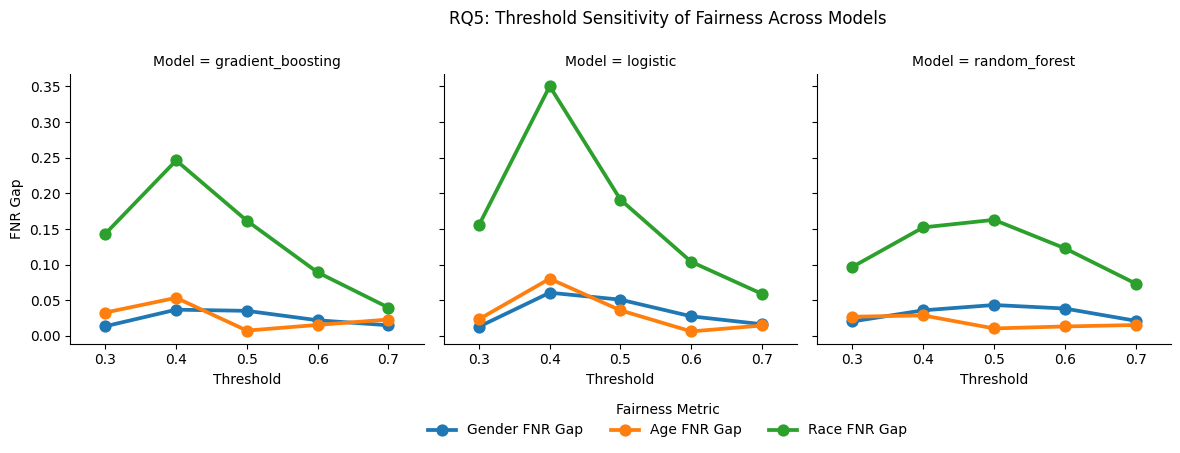

In [ ]:
# Reshape fairness metrics for visualization and create
# point plots to analyze how demographic FNR gaps change
# across decision thresholds for each model.

rq5_fairness_plot = rq5_summary_all.melt(
    id_vars=['Model', 'Threshold'],
    value_vars=['Gender FNR Gap', 'Age FNR Gap', 'Race FNR Gap'],
    var_name='Fairness Metric',
    value_name='FNR Gap'
)

g = sns.catplot(
    data=rq5_fairness_plot,
    x='Threshold',
    y='FNR Gap',
    hue='Fairness Metric',
    col='Model',
    kind='point',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('RQ5: Threshold Sensitivity of Fairness Across Models')

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

plt.show()

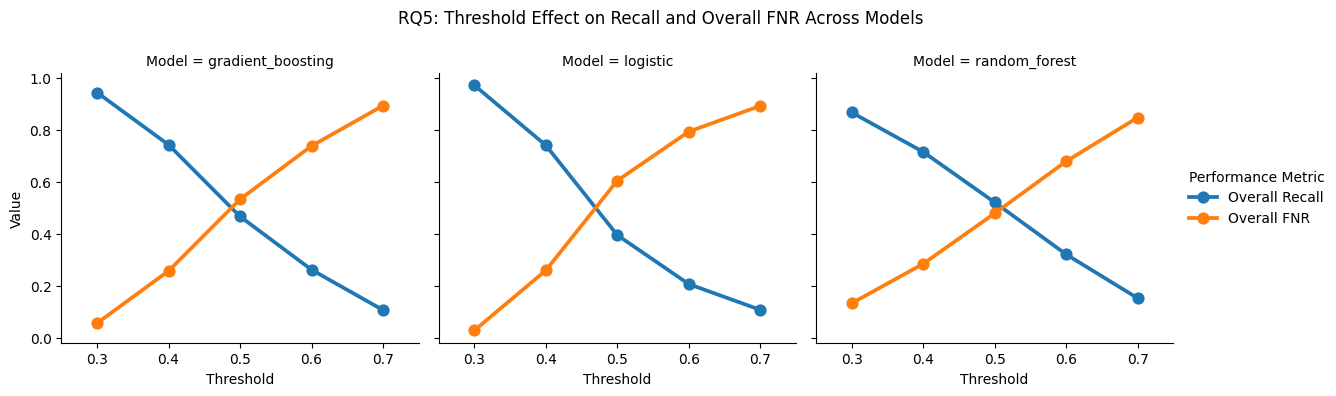

In [ ]:
# Reshape performance metrics for visualization and create
# point plots to analyze how recall and overall FNR vary
# across decision thresholds for each model.

rq5_perf_plot = rq5_summary_all.melt(
    id_vars=['Model', 'Threshold'],
    value_vars=['Overall Recall', 'Overall FNR'],
    var_name='Performance Metric',
    value_name='Value'
)

g = sns.catplot(
    data=rq5_perf_plot,
    x='Threshold',
    y='Value',
    hue='Performance Metric',
    col='Model',
    kind='point',
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('RQ5: Threshold Effect on Recall and Overall FNR Across Models')

plt.show()

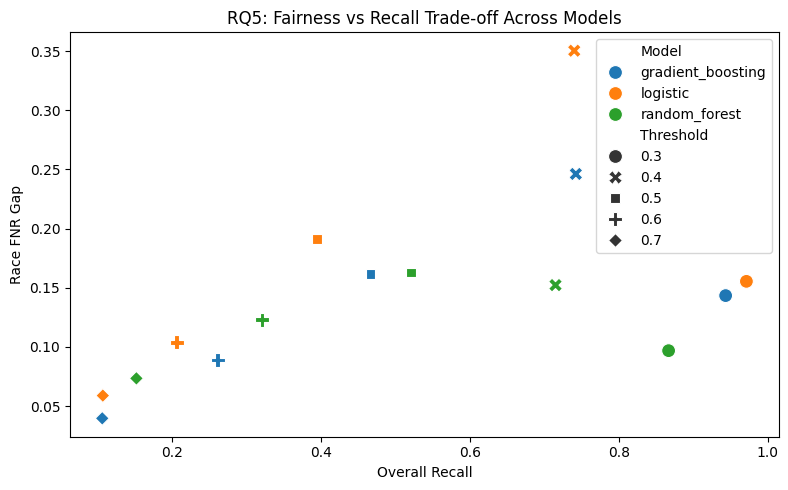

In [ ]:
# Create a scatter plot to visualize the trade-off between
# overall recall performance and racial fairness disparity
# across models and decision thresholds.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rq5_summary_all,
    x='Overall Recall',
    y='Race FNR Gap',
    hue='Model',
    style='Threshold',
    s=100
)

plt.title('RQ5: Fairness vs Recall Trade-off Across Models')
plt.xlabel('Overall Recall')
plt.ylabel('Race FNR Gap')
plt.tight_layout()
plt.show()